In [1]:
from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer, AutoModel
import torch
import torch.nn.functional as F


In [2]:
import pandas as pd
import numpy as np
import pickle
import math
import scipy

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import cm

In [3]:
from matplotlib.ticker import ScalarFormatter


In [4]:
import sys
import os


sys.path.append("../src")
from custom_distance import KL

In [5]:
import statsmodels.api as sm

In [6]:
def get_coef(x, y):
    x = np.log(x)
    x = sm.add_constant(x)
    
    lr_fit = sm.OLS(y, x)
    results = lr_fit.fit()

    return results.params[-1]

In [7]:
import warnings
warnings.filterwarnings("ignore")


In [8]:
!ls -lrt ../output/ | grep DistilBERT_SHACBalanceAlpha

drwxr-xr-x  2 xiruod domain users  4096 Feb 27 00:10 DistilBERT_SHACBalanceAlpha_10Pct_Fix_RandomPermute_ShorterVersion_1_10_WrongSourceInference
drwxr-xr-x  2 xiruod domain users  4096 Feb 29 00:08 DistilBERT_SHACBalanceAlpha_RandomPermute_ShorterVersion_1_20_WrongSourceInference
drwxr-xr-x 67 xiruod domain users 12288 Mar  1 00:13 DistilBERT_SHACBalanceAlpha_10Pct_Fix_RandomPermute_SaveModel_WrongSourceInference
drwxr-xr-x 67 xiruod domain users 12288 Mar  1 13:17 DistilBERT_SHACBalanceAlpha_10Pct_Fix_RandomPermute_SaveModel
drwxr-xr-x  2 xiruod domain users  4096 Mar  7 14:41 DistilBERT_SHACBalanceAlpha_10Pct_Fix_RandomPermute_ShorterVersion_1_5
drwxr-xr-x 67 xiruod domain users 12288 Mar  7 16:12 DistilBERT_SHACBalanceAlpha_RandomPermute_ShorterVersion_1_5_SaveModel
drwxr-xr-x  2 xiruod domain users  4096 Mar 12 00:49 DistilBERT_SHACBalanceAlpha_RandomPermute_ShorterVersion_1_5


In [9]:
!ls -lrt ../output/tmpData/SHAC

total 4592
-rw-r--r-- 1 xiruod domain users   72301 Mar 28 03:42 OriginalWeightsEdited-set-1355-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.0-lambda2_0.0-added-ntest_500-pct_1_20.pkl
-rw-r--r-- 1 xiruod domain users   72301 Mar 28 09:52 OriginalWeightsEdited-set-1355-quantization-epoch3-llama-2-7B-loraR-8-lambda1_2.0-lambda2_1.0-added-ntest_500-pct_1_20.pkl
-rw-r--r-- 1 xiruod domain users   95846 Mar 28 19:21 OriginalWeightsEdited-set-1355-quantization-epoch3-llama-2-7B-loraR-8-lambda1_3.0-lambda2_1.0-added-ntest_500-pct_1_15.pkl
-rw-r--r-- 1 xiruod domain users  175375 Mar 29 06:30 OriginalWeightsEdited-set-1355-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.0-lambda2_0.0-added-ntest_200-pct_1_15.pkl
-rw-r--r-- 1 xiruod domain users  175375 Mar 29 13:09 OriginalWeightsEdited-set-1355-quantization-epoch3-llama-2-7B-loraR-8-lambda1_2.0-lambda2_1.0-added-ntest_200-pct_1_15.pkl
-rw-r--r-- 1 xiruod domain users  181815 Mar 29 21:58 OriginalWeightsEdited-set-1355-quantization-epoch3

In [11]:
# save

# with open("../output/regressionSHAC/05_02_400_L2_C5_V1.pkl", "wb") as f:
#     pickle.dump(df_eval, file=f)
    
# with open(f"../output/regressionInverseSHAC_MIMIC_UW/binaryUnigram_02_05_500_l2_C1_V100.pkl", "rb") as f:
# with open(f"../output/regressionSHAC/binaryUnigram_05_02_500_l2_C1_V1.pkl", "rb") as f:


##### SHAC

# fname="../output/regressionSHAC/binaryUnigram_0.3_0.3_500_l2_C1_V10"
# fname="../output/regressionSHAC/binaryUnigram_05_02_500_l2_C1_V10"
# fname="../output/regressionSHAC/Sentence-BERT_05_02_500_l2_C1_V10" ## AMIA Plot
# fname="../output/regressionSHAC/LLaMaAverage_0.5_0.2_500_l2_C1_V10"

# fname = "../output/regressionSHACBalanceAlpha/binaryUnigram_ntest_200_l2_C1_V10"
# fname = "../output/regressionSHACBalanceAlpha/Sentence-BERT_ntest_200_l2_C1_V10"
# fname = "../output/regressionSHACBalanceAlpha/LoRA_12720_ntest_200_l2_C1_V10" ## Balanced!
# fname = "../output/regressionSHACBalanceAlpha/LoRA_18965_ntest_200_l2_C1_V10" ## Balanced!
# fname = "../output/regressionSHACBalanceAlpha/LLaMaAverage_ntest_200_l2_C1_V10"
# fname = "../output/regressionSHACBalanceAlpha/DistilBERT_12720_ntest_200_l2_C1_V10"

# fname="../output/regressionSHAC/Clinical-BERT_0.5_0.2_500_l2_C1_V10"

# fname = "../output/regressionSHACBalanceAlpha/LLaMaAverageV2_7B_ntest_200_l2_C1_V10"
# fname = "../output/regressionSHACBalanceAlpha/LLaMaAverageV2_13B_ntest_200_l2_C1_V10"
# fname = "../output/regressionSHACBalanceAlpha/LLaMaAverageV2_70B_8Quant_ntest_200_l2_C1_V10"


# fname = "../output/regressionSHACBalanceAlpha/LoRA_18965_ntest_200_7B-loraR-2_l2_C1_V10"
# fname = "../output/regressionSHACBalanceAlpha/LoRA_18965_ntest_200_7B-loraR-8_l2_C1_V10"
# fname = "../output/regressionSHACBalanceAlpha/LoRA_18965_ntest_200_7B-loraR-32_l2_C1_V10"
# fname = "../output/regressionSHACBalanceAlpha/LoRA_18965_ntest_200_13B-loraR-2_l2_C1_V10"
# fname = "../output/regressionSHACBalanceAlpha/LoRA_18965_ntest_200_13B-loraR-8_l2_C1_V10"
# fname = "../output/regressionSHACBalanceAlpha/LoRA_18965_ntest_200_13B-loraR-32_l2_C1_V10"
# fname = "../output/regressionSHACBalanceAlpha/LoRA_18965_ntest_200_13B-loraR-64_l2_C1_V10"
# fname = "../output/regressionSHACBalanceAlpha/LoRA_18965_ntest_200_70B-loraR-2_l2_C1_V10"
# fname = "../output/regressionSHACBalanceAlpha/LoRA_18965_ntest_200_70B-loraR-8_l2_C1_V10"
# fname = "../output/regressionSHACBalanceAlpha/LoRA_18965_ntest_200_70B-loraR-32_l2_C1_V10"

# fname = "../output/regressionSHACBalanceAlpha/Sentence-BERT_0.5_0.2_500_l2_C1_V10"
# fname = "../output/regressionSHACBalanceAlpha/Sentence-BERT_ntest_500_l2_C1_V10"

# fname = "../output/regressionSHACBalanceAlpha_SimplePermuteAverage/Sentence-BERT_ntest_500_l2_C1_V10"
# fname = "../output/regressionSHACBalanceAlpha_SimplePermute_TestAverageByProportion/Sentence-BERT_ntest_500_l2_C1_V10"

# fname = "../output/DistilBERT_SHACBalanceAlpha_RandomPermute_ShorterVersion_1_20/DistilBERT_ntest_500"
# fname = "../output/DistilBERT_SHACBalanceAlpha_10Pct_Fix_RandomPermute_ShorterVersion_1_5/DistilBERT_ntest_500"




# fname = "../output/tmpData/LoraPredict/set-1355-quantization-epoch3-llama-2-7B-loraR-8_ntest_500_setting_1_15"
# fname = "../output/tmpData/LoraPredict_Original_Target/set-1355-quantization-epoch3-llama-2-7B-loraR-8_ntest_500_setting_1_15"
# fname = "../output/tmpData/LoraAdapters_TargetNorm/set-1355-quantization-epoch3-llama-2-7B-loraR-8_ntest_500_setting_1_15"
# fname = "../output/tmpData/LoraPredict/set-1355-quantization-epoch3-llama-2-13B-loraR-8_ntest_500_setting_1_15"
# fname = "../output/tmpData/LoraPredict_Original_Target/set-1355-quantization-epoch3-llama-2-13B-loraR-8_ntest_500_setting_1_15"
# fname = "../output/tmpData/LoraAdapters_TargetNorm/set-1355-quantization-epoch3-llama-2-13B-loraR-8_ntest_500_setting_1_15"
# fname = "../output/tmpData/LoraAdapters_TargetFroNorm/set-1355-quantization-epoch3-llama-2-7B-loraR-8_ntest_500_setting_1_15"
# fname = "../output/tmpData/LoraAdapters_TargetFroNorm/set-1355-quantization-epoch3-llama-2-13B-loraR-8_ntest_500_setting_1_15"
# fname = "../output/tmpData/WeightsEdited_Gamma_1_Added/set-1355-quantization-epoch3-llama-2-7B-loraR-8-gamma_1-added_ntest_500_setting_1_15"
# fname = "../output/tmpData/WeightsEdited_Gamma_1_Added/set-1355-quantization-epoch3-llama-2-13B-loraR-8-gamma_1-added_ntest_500_setting_1_15"
# fname = "../output/tmpData/WeightsEdited_Gamma_0.1_Added/set-1355-quantization-epoch3-llama-2-7B-loraR-8-gamma_0_ntest_500_setting_1_15"
# fname = "../output/tmpData/WeightsEdited_Gamma_0.2_Added/set-1355-quantization-epoch3-llama-2-7B-loraR-8-gamma_0_ntest_500_setting_1_15"
# fname = "../output/tmpData/WeightsEdited_Gamma_0.5_Added/set-1355-quantization-epoch3-llama-2-7B-loraR-8-gamma_0_ntest_500_setting_1_15"
# fname = "../output/tmpData/WeightsEdited_Gamma_0.8_Added/set-1355-quantization-epoch3-llama-2-7B-loraR-8-gamma_0_ntest_500_setting_1_15"
# fname = "../output/tmpData/WeightsEdited_Gamma_1.5_Added/set-1355-quantization-epoch3-llama-2-7B-loraR-8-gamma_1_ntest_500_setting_1_15"
# fname = "../output/tmpData/WeightsEdited_Gamma_2.0_Added/set-1355-quantization-epoch3-llama-2-7B-loraR-8-gamma_2_ntest_500_setting_1_15"
# fname = "../output/tmpData/WeightsEdited_Gamma_3.0_Added/set-1355-quantization-epoch3-llama-2-7B-loraR-8-gamma_3_ntest_500_setting_1_15"
# fname = "../output/tmpData/WeightsEdited_Gamma_1.0_Lamda1_1.0_Lambda2_0.5_Added/set-1355-quantization-epoch3-llama-2-7B-loraR-8-gamma_1.0-lambda1_1.0-lambda2_0.5-added_ntest_500_setting_1_15"
# fname = "../output/tmpData/WeightsEdited_Gamma_1.0_Lamda1_2.0_Lambda2_1.0_Added/set-1355-quantization-epoch3-llama-2-7B-loraR-8-gamma_1.0-lambda1_2.0-lambda2_1.0-added_ntest_500_setting_1_20"
# fname = "../output/tmpData/WeightsEdited_Gamma_1.0_Lamda1_1.0_Lambda2_0.0_Added/set-1355-quantization-epoch3-llama-2-7B-loraR-8-gamma_1.0-lambda1_1.0-lambda2_0.0-added_ntest_500_setting_1_20"

# fname = "../output/tmpData/SHAC/OriginalWeightsEdited-set-1355-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.0-lambda2_0.0-added-ntest_500-pct_1_20"
# fname = "../output/tmpData/SHAC/OriginalWeightsEdited-set-1355-quantization-epoch3-llama-2-7B-loraR-8-lambda1_2.0-lambda2_1.0-added-ntest_500-pct_1_20"
# fname = "../output/tmpData/SHAC/OriginalWeightsEdited-set-1355-quantization-epoch3-llama-2-7B-loraR-8-lambda1_3.0-lambda2_1.0-added-ntest_500-pct_1_15"

# fname = "../output/tmpData/SHAC/OriginalWeightsEdited-set-1355-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.0-lambda2_0.0-added-ntest_200-pct_1_5"
# fname = "../output/tmpData/SHAC/OriginalWeightsEdited-set-1355-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.0-lambda2_0.5-added-ntest_200-pct_1_5"
# fname = "../output/tmpData/SHAC/OriginalWeightsEdited-set-1355-quantization-epoch3-llama-2-7B-loraR-8-lambda1_2.0-lambda2_1.0-added-ntest_200-pct_1_5"

# fname = "../output/tmpData/SHAC/OriginalWeightsEdited-set-1355-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.0-lambda2_0.0-added-ntest_200-pct_1_1_wrongSet"
# fname = "../output/tmpData/SHAC/OriginalWeightsEdited-set-1355-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.0-lambda2_0.5-added-ntest_200-pct_1_1_wrongSet"


# fname = '../output/regressionStratifiedSHACBalanceAlpha/binaryUnigram_ntest_200_l2_C1_V10'
# fname = '../output/regressionOversamplingSHACBalanceAlpha/binaryUnigram_ntest_200_l2_C1_V10'

# dataset_name = 'shac'


##############  HateSpeech
# fname = "../output/regressionHateSpeech/Sentence-BERT_0.6_0.1_500_l2_C1_V10"

# fname = "../output/regressionHateSpeechBalanceAlpha/Sentence-BERT_0.6_0.1_500_l2_C1_V10"
# fname = "../output/regressionHateSpeechBalanceAlpha/Sentence-BERT_ntest_5000_l2_C1_V10"

# fname = "../output/regressionHateSpeechBalanceAlpha/binaryUnigram_ntest_1000_l2_C1_V10"
# fname = "../output/regressionHateSpeechBalanceAlpha/Sentence-BERT_ntest_1000_l2_C1_V10"
# fname = "../output/regressionHateSpeechBalanceAlpha/LoRA_1244_ntest_1000_l2_C1_V10"
# fname = "../output/regressionHateSpeechBalanceAlpha/LoRA_2234_ntest_1000_l2_C1_V10"
# fname = "../output/regressionHateSpeechBalanceAlpha/LoRA_75_ntest_1000_l2_C1_V10" ## Balanced
# fname = "../output/regressionHateSpeechBalanceAlpha/DistilBERT_75_ntest_1000_l2_C1_V10" ## Balanced
# fname = "../output/regressionHateSpeechBalanceAlpha/LLaMaAverageV2_7B_ntest_1000_l2_C1_V10"
# fname = "../output/regressionHateSpeechBalanceAlpha/LLaMaAverageV2_13B_ntest_1000_l2_C1_V10"
# fname = "../output/regressionHateSpeechBalanceAlpha/LLaMaAverageV2_70B_8Quant_ntest_1000_l2_C1_V10"

# fname = "../output/regressionHateSpeechBalanceAlpha/LLaMaAverageV2_7B_Permute_ntest_1000_l2_C1_V10"
# fname = "../output/regressionHateSpeechBalanceAlpha_SimplePermute/Sentence-BERT_ntest_1000_l2_C1_V10"

# fname = "../output/regressionHateSpeechBalanceAlpha_SimplePermuteAverage/Sentence-BERT_ntest_1000_l2_C1_V10"
# fname = "../output/regressionHateSpeechBalanceAlpha_SimplePermute_TestAverageByProportion/Sentence-BERT_ntest_1000_l2_C1_V10"

# fname = "../output/DistilBERT_HateSpeechBalanceAlpha_RandomPermute_ShorterVersion_1_5/DistilBERT_ntest_1000"
# fname = "../output/DistilBERT_HateSpeechBalanceAlpha_RandomPermute_ShorterVersion_1_20/DistilBERT_ntest_1000"
# fname = "../output/DistilBERT_HateSpeechBalanceAlpha_10Pct_Fix_RandomPermute_ShorterVersion_1_20/DistilBERT_ntest_1000"

# fname = '../output/regressionStratifiedHateSpeechBalanceAlpha/binaryUnigram_ntest_1000_l2_C1_V10'

fname = '../output/regressionOversamplingHateSpeechBalanceAlpha/binaryUnigram_ntest_1000_l2_C1_V10'


dataset_name = 'hatespeech'


# fname = "../output/regressionCivilComments_by_Christian/Sentence-BERT_ntest_500_l2_C1_V10"
# fname = "../output/regressionCivilComments_by_Male/Sentence-BERT_ntest_500_l2_C1_V10"
# fname = "../output/regressionCivilComments_by_White//Sentence-BERT_ntest_500_l2_C1_V10"



with open(f"{fname}.pkl", "rb") as f:
    df_eval = pickle.load(file=f)
    


In [12]:
df_eval

,auprc_logistic_confounder,auprc_logistic_vanilla,auprc_logistic_confounder_df0,auprc_logistic_confounder_df1,precision_confounder,recall_confounder,f1_confounder,precision_confounder_df0,recall_confounder_df0,f1_confounder_df0,...,n_test,n_z0_pos_train,n_z0_neg_train,n_z0_pos_test,n_z0_neg_test,n_z1_pos_train,n_z1_neg_train,n_z1_pos_test,n_z1_neg_test,run
0,0.295976,0.296812,0.304672,0.321524,0.348739,0.415000,0.378995,0.354545,0.410526,0.380488,...,1000,720,2880,190,710,80,320,10,90,0
1,0.287243,0.288283,0.295864,0.257947,0.360515,0.420000,0.387991,0.366667,0.407407,0.385965,...,1000,720,2880,189,711,80,320,11,89,0
2,0.286097,0.286903,0.293026,0.260493,0.350000,0.420000,0.381818,0.356164,0.414894,0.383292,...,1000,720,2880,188,712,80,320,12,88,0
3,0.286332,0.287447,0.292897,0.264566,0.347639,0.405000,0.374134,0.345794,0.395722,0.369077,...,1000,720,2880,187,713,80,320,13,87,0
4,0.288962,0.289023,0.293934,0.269959,0.354430,0.420000,0.384439,0.356164,0.419355,0.385185,...,1000,720,2880,186,714,80,320,14,86,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3585,0.940729,0.940706,0.952619,0.815169,0.905028,0.900000,0.902507,0.933086,0.899642,0.916058,...,1000,3240,360,837,63,360,40,63,37,4
3586,0.938118,0.938228,0.947971,0.849115,0.906742,0.896667,0.901676,0.928750,0.894103,0.911097,...,1000,3240,360,831,69,360,40,69,31,4
3587,0.940474,0.940412,0.945274,0.897551,0.910414,0.903333,0.906860,0.925373,0.902913,0.914005,...,1000,3240,360,824,76,360,40,76,24,4
3588,0.940003,0.940029,0.940157,0.945649,0.910227,0.890000,0.900000,0.917826,0.888617,0.902985,...,1000,3240,360,817,83,360,40,83,17,4


In [13]:
df_eval.columns

Index(['auprc_logistic_confounder', 'auprc_logistic_vanilla',
       'auprc_logistic_confounder_df0', 'auprc_logistic_confounder_df1',
       'precision_confounder', 'recall_confounder', 'f1_confounder',
       'precision_confounder_df0', 'recall_confounder_df0',
       'f1_confounder_df0', 'precision_confounder_df1',
       'recall_confounder_df1', 'f1_confounder_df1',
       'auprc_logistic_vanilla_df0', 'auprc_logistic_vanilla_df1',
       'precision_vanilla', 'recall_vanilla', 'f1_vanilla',
       'precision_vanilla_df0', 'recall_vanilla_df0', 'f1_vanilla_df0',
       'precision_vanilla_df1', 'recall_vanilla_df1', 'f1_vanilla_df1',
       'p_pos_train_z0', 'p_pos_train_z1', 'p_pos_train', 'p_pos_test',
       'p_mix_z0', 'p_mix_z1', 'alpha_train', 'alpha_test', 'p_pos_test_z0',
       'p_pos_test_z1', 'C_y', 'C_z', 'n_train', 'n_test', 'n_z0_pos_train',
       'n_z0_neg_train', 'n_z0_pos_test', 'n_z0_neg_test', 'n_z1_pos_train',
       'n_z1_neg_train', 'n_z1_pos_test', 'n_z1_neg_t

In [ ]:
import pathlib
import json


In [ ]:
base_dir = pathlib.Path("/bime-munin/xiruod/LoRA_DistilBERT_SHAC/")
dataset_name = 'shac'


In [ ]:
alpha_train_ls = []
alpha_test_ls = []
C_y_ls = []
auprc_ls = []

for file_i in base_dir.glob("*/all_results.json"):
    with open(file_i) as f:
        tmp = json.load(f)
        
    alpha_train_ls.append(tmp["mix_param_dict"]["alpha_train"])
    alpha_test_ls.append(tmp["mix_param_dict"]["alpha_test"])
    C_y_ls.append(tmp["mix_param_dict"]["C_y"])
    auprc_ls.append(tmp["eval_auprc"])

In [ ]:
df_eval = pd.DataFrame({"alpha_train":alpha_train_ls,
                        "alpha_test":alpha_test_ls,
                        "C_y":C_y_ls,
                        "auprc_logistic_vanilla":auprc_ls
                       })

# Plot results

In [14]:
df = df_eval.copy()

In [13]:
df_eval.shape

(79835, 35)

In [14]:
df_eval.head()

,auprc_logistic_vanilla,auprc_logistic_vanilla_df0,auprc_logistic_vanilla_df1,precision_vanilla,recall_vanilla,f1_vanilla,precision_vanilla_df0,recall_vanilla_df0,f1_vanilla_df0,precision_vanilla_df1,...,n_test,n_z0_pos_train,n_z0_neg_train,n_z0_pos_test,n_z0_neg_test,n_z1_pos_train,n_z1_neg_train,n_z1_pos_test,n_z1_neg_test,run
0,0.843796,0.983333,0.887013,0.470588,0.8,0.592593,0.357143,1.0,0.526316,1.000000,...,200,68,612,10,160,12,108,10,20,0
1,0.843796,0.983333,0.887013,0.470588,0.8,0.592593,0.357143,1.0,0.526316,1.000000,...,200,68,612,10,160,12,108,10,20,0
2,0.844552,0.983333,0.850743,0.470588,0.8,0.592593,0.370370,1.0,0.540541,0.857143,...,200,64,576,10,150,16,144,10,30,0
3,0.844552,0.983333,0.850743,0.470588,0.8,0.592593,0.370370,1.0,0.540541,0.857143,...,200,64,576,10,150,16,144,10,30,0
4,0.846130,0.983333,0.827870,0.470588,0.8,0.592593,0.370370,1.0,0.540541,0.857143,...,200,60,540,10,140,20,180,10,40,0


In [15]:
df_eval.columns

Index(['auprc_logistic_vanilla', 'auprc_logistic_vanilla_df0',
       'auprc_logistic_vanilla_df1', 'precision_vanilla', 'recall_vanilla',
       'f1_vanilla', 'precision_vanilla_df0', 'recall_vanilla_df0',
       'f1_vanilla_df0', 'precision_vanilla_df1', 'recall_vanilla_df1',
       'f1_vanilla_df1', 'p_pos_train_z0', 'p_pos_train_z1', 'p_pos_train',
       'p_pos_test', 'p_mix_z0', 'p_mix_z1', 'alpha_train', 'alpha_test',
       'p_pos_test_z0', 'p_pos_test_z1', 'C_y', 'C_z', 'n_train', 'n_test',
       'n_z0_pos_train', 'n_z0_neg_train', 'n_z0_pos_test', 'n_z0_neg_test',
       'n_z1_pos_train', 'n_z1_neg_train', 'n_z1_pos_test', 'n_z1_neg_test',
       'run'],
      dtype='object')

In [16]:
df_eval['alpha_test'].unique()

array([ 5.55991731,  6.11590904,  3.79749834,  4.17724817,  2.85311671,
        3.13842838,  2.14358881,  2.35794769,  1.771561  ,  1.9487171 ,
        1.4641    ,  1.61051   ,  1.21      ,  1.331     ,  0.90909091,
        1.        ,  1.1       ,  0.7513148 ,  0.82644628,  0.62092132,
        0.68301346,  0.51315812,  0.56447393,  0.42409762,  0.46650738,
        0.31863082,  0.3504939 ,  0.23939205,  0.26333125,  0.16350799,
        0.17985879,  7.40024994,  8.14027494,  4.59497299,  5.05447028,
        6.72749995,  3.45227121,  2.59374246,  0.38554329,  0.28966438,
        0.19784467,  0.21762914,  0.13513057,  0.14864363,  0.092296  ,
        0.1015256 ,  0.11167816,  0.12284597,  8.95430243,  0.08390545,
        9.84973268, 10.83470594, 11.91817654])

In [17]:
df_eval['alpha_train'].unique()

array([1.        , 2.        , 3.        , 4.        , 5.        ,
       6.        , 7.        , 8.        , 9.        , 0.5       ,
       1.5       , 2.5       , 3.5       , 4.5       , 0.33333333,
       0.66666667, 1.33333333, 1.66666667, 2.33333333, 2.66666667,
       3.        , 0.25      , 0.75      , 1.25      , 1.75      ,
       2.25      , 0.2       , 0.4       , 0.6       , 0.8       ,
       1.2       , 1.4       , 1.6       , 1.8       , 0.16666667,
       0.83333333, 1.16666667, 1.5       , 0.14285714, 0.28571429,
       0.42857143, 0.57142857, 0.71428571, 0.85714286, 1.14285714,
       1.28571429, 0.125     , 0.375     , 0.625     , 0.875     ,
       1.125     , 0.11111111, 0.22222222, 0.33333333, 0.44444444,
       0.55555556, 0.66666667, 0.77777778, 0.88888889])

In [18]:
df_eval['p_pos_train_z0'].unique()

array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9])

In [19]:
df_eval['p_pos_train_z1'].unique()

array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9])

In [20]:
set([(x,y) for x, y in zip(df_eval['p_pos_train_z0'], df_eval['p_pos_train_z1'])])

{(0.1, 0.1),
 (0.1, 0.2),
 (0.1, 0.30000000000000004),
 (0.1, 0.4),
 (0.1, 0.5),
 (0.1, 0.6000000000000001),
 (0.1, 0.7000000000000001),
 (0.1, 0.8),
 (0.1, 0.9),
 (0.2, 0.1),
 (0.2, 0.2),
 (0.2, 0.30000000000000004),
 (0.2, 0.4),
 (0.2, 0.5),
 (0.2, 0.6000000000000001),
 (0.2, 0.7000000000000001),
 (0.2, 0.8),
 (0.2, 0.9),
 (0.30000000000000004, 0.1),
 (0.30000000000000004, 0.2),
 (0.30000000000000004, 0.30000000000000004),
 (0.30000000000000004, 0.4),
 (0.30000000000000004, 0.5),
 (0.30000000000000004, 0.6000000000000001),
 (0.30000000000000004, 0.7000000000000001),
 (0.30000000000000004, 0.8),
 (0.30000000000000004, 0.9),
 (0.4, 0.1),
 (0.4, 0.2),
 (0.4, 0.30000000000000004),
 (0.4, 0.4),
 (0.4, 0.5),
 (0.4, 0.6000000000000001),
 (0.4, 0.7000000000000001),
 (0.4, 0.8),
 (0.4, 0.9),
 (0.5, 0.1),
 (0.5, 0.2),
 (0.5, 0.30000000000000004),
 (0.5, 0.4),
 (0.5, 0.5),
 (0.5, 0.6000000000000001),
 (0.5, 0.7000000000000001),
 (0.5, 0.8),
 (0.5, 0.9),
 (0.6000000000000001, 0.1),
 (0.600000000

In [21]:
df_eval['C_y'].unique()

array([0.1  , 0.1  , 0.1  , 0.11 , 0.115, 0.12 , 0.125, 0.13 , 0.135,
       0.14 , 0.145, 0.15 , 0.155, 0.16 , 0.165, 0.17 , 0.175, 0.18 ,
       0.185, 0.19 , 0.2  , 0.21 , 0.22 , 0.23 , 0.24 , 0.25 , 0.26 ,
       0.27 , 0.19 , 0.205, 0.235, 0.25 , 0.265, 0.28 , 0.295, 0.31 ,
       0.24 , 0.26 , 0.3  , 0.32 , 0.175, 0.2  , 0.225, 0.275, 0.3  ,
       0.325, 0.19 , 0.31 , 0.34 , 0.17 , 0.345, 0.34 , 0.18 , 0.17 ,
       0.165, 0.16 , 0.12 , 0.115, 0.2  , 0.215, 0.23 , 0.235, 0.24 ,
       0.245, 0.255, 0.27 , 0.29 , 0.32 , 0.33 , 0.245, 0.305, 0.335,
       0.35 , 0.365, 0.36 , 0.38 , 0.35 , 0.375, 0.4  , 0.38 , 0.41 ,
       0.305, 0.21 , 0.18 , 0.29 , 0.285, 0.255, 0.235, 0.3  , 0.315,
       0.33 , 0.345, 0.355, 0.37 , 0.39 , 0.36 , 0.375, 0.39 , 0.405,
       0.42 , 0.435, 0.38 , 0.44 , 0.46 , 0.35 , 0.4  , 0.425, 0.45 ,
       0.475, 0.48 , 0.295, 0.22 , 0.205, 0.145, 0.37 , 0.34 , 0.33 ,
       0.385, 0.36 , 0.355, 0.4  , 0.415, 0.43 , 0.435, 0.44 , 0.445,
       0.45 , 0.455,

In [23]:
df['alpha_train'].unique()

array([1.        , 2.        , 3.        , 4.        , 5.        ,
       6.        , 7.        , 8.        , 9.        , 0.5       ,
       1.5       , 2.5       , 3.5       , 4.5       , 0.33333333,
       0.66666667, 1.33333333, 1.66666667, 2.33333333, 2.66666667,
       3.        , 0.25      , 0.75      , 1.25      , 1.75      ,
       2.25      , 0.2       , 0.4       , 0.6       , 0.8       ,
       1.2       , 1.4       , 1.6       , 1.8       , 0.16666667,
       0.83333333, 1.16666667, 1.5       , 0.14285714, 0.28571429,
       0.42857143, 0.57142857, 0.71428571, 0.85714286, 1.14285714,
       1.28571429, 0.125     , 0.375     , 0.625     , 0.875     ,
       1.125     , 0.11111111, 0.22222222, 0.33333333, 0.44444444,
       0.55555556, 0.66666667, 0.77777778, 0.88888889])

In [24]:
df['p_mix_z1'].unique()

array([0.15, 0.2 , 0.25, 0.3 , 0.35, 0.4 , 0.45, 0.5 , 0.55, 0.6 , 0.65,
       0.7 , 0.75, 0.8 , 0.85, 0.1 , 0.9 ])

In [25]:
len(df['p_mix_z1'].unique())

17

In [26]:
# df['distance_KL_Test_Train'] = df.apply(lambda x: KL([1-x['p_pos_test_z0'], x['p_pos_test_z0'], 1-x['p_pos_test_z1'], x['p_pos_test_z1']],
#                                                            [1-x['p_pos_train_z0'], x['p_pos_train_z0'], 1-x['p_pos_train_z1'], x['p_pos_train_z1']]
#                                                           ),
#                                               axis=1
#                                              )

In [27]:
# Questionable?
# df['distance_KL_Train_Test'] = df.apply(lambda x: KL([1-x['p_pos_train_z0'], x['p_pos_train_z0'], 1-x['p_pos_train_z1'], x['p_pos_train_z1']],
#                                                      [1-x['p_pos_test_z0'], x['p_pos_test_z0'], 1-x['p_pos_test_z1'], x['p_pos_test_z1']],
                                                           
#                                                           ),
#                                               axis=1
#                                              )

# df['distance_KL_Test_Train'] = df.apply(lambda x: KL(
#                                                      [1-x['p_pos_test_z0'], x['p_pos_test_z0'], 1-x['p_pos_test_z1'], x['p_pos_test_z1']],
#                                                      [1-x['p_pos_train_z0'], x['p_pos_train_z0'], 1-x['p_pos_train_z1'], x['p_pos_train_z1']],
                                                           
#                                                           ),
#                                               axis=1
#                                              )




In [28]:
df['distance_KL_Train_Test'] = df.apply(lambda x: KL(
    [(1-x['p_pos_train_z0'])*x['p_mix_z0'], x['p_pos_train_z0']*x['p_mix_z0'], (1-x['p_pos_train_z1'])*x['p_mix_z1'], x['p_pos_train_z1']*x['p_mix_z1']],
    [(1-x['p_pos_test_z0'])*x['p_mix_z0'], x['p_pos_test_z0']*x['p_mix_z0'], (1-x['p_pos_test_z1'])*x['p_mix_z1'], x['p_pos_test_z1']*x['p_mix_z1']],
                                                   ),
                                              axis=1
                                             )







df['distance_EMD'] = df.apply(lambda x: scipy.stats.wasserstein_distance(np.arange(4), np.arange(4),
                                                     [(1-x['p_pos_test_z0'])*x['p_mix_z0'], x['p_pos_test_z0']*x['p_mix_z0'], (1-x['p_pos_test_z1'])*x['p_mix_z1'], x['p_pos_test_z1']*x['p_mix_z1']],
                                                     [(1-x['p_pos_train_z0'])*x['p_mix_z0'], x['p_pos_train_z0']*x['p_mix_z0'], (1-x['p_pos_train_z1'])*x['p_mix_z1'], x['p_pos_train_z1']*x['p_mix_z1']],
                                                   ),
                                              axis=1
                                             )

## Distance Plots

In [8]:
df

,auprc_logistic_confounder,auprc_logistic_vanilla,auprc_logistic_confounder_df0,auprc_logistic_confounder_df1,precision_confounder,recall_confounder,f1_confounder,precision_confounder_df0,recall_confounder_df0,f1_confounder_df0,...,n_test,n_z0_pos_train,n_z0_neg_train,n_z0_pos_test,n_z0_neg_test,n_z1_pos_train,n_z1_neg_train,n_z1_pos_test,n_z1_neg_test,run
0,0.100,0.100,0.058824,0.333333,0.000,0.0,0.000000,0.000000,0.0,0.000000,...,200,68,612,10,160,12,108,10,20,0
1,0.100,0.100,0.058824,0.333333,0.000,0.0,0.000000,0.000000,0.0,0.000000,...,200,68,612,10,160,12,108,10,20,0
2,0.100,0.100,0.062500,0.250000,0.000,0.0,0.000000,0.000000,0.0,0.000000,...,200,64,576,10,150,16,144,10,30,0
3,0.100,0.100,0.062500,0.250000,0.000,0.0,0.000000,0.000000,0.0,0.000000,...,200,64,576,10,150,16,144,10,30,0
4,0.100,0.100,0.066667,0.200000,0.000,0.0,0.000000,0.000000,0.0,0.000000,...,200,60,540,10,140,20,180,10,40,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
109630,0.860,0.860,0.891667,0.812500,0.860,1.0,0.924731,0.891667,1.0,0.942731,...,200,432,48,107,13,256,64,65,15,4
109631,0.860,0.860,0.858333,0.862500,0.860,1.0,0.924731,0.858333,1.0,0.923767,...,200,432,48,103,17,256,64,69,11,4
109632,0.855,0.855,0.890909,0.811111,0.855,1.0,0.921833,0.890909,1.0,0.942308,...,200,396,44,98,12,288,72,73,17,4
109633,0.855,0.855,0.854545,0.855556,0.855,1.0,0.921833,0.854545,1.0,0.921569,...,200,396,44,94,16,288,72,77,13,4


In [13]:
df['p_mix_z1'].unique()

array([0.2, 0.4, 0.6, 0.8])

In [14]:
df[df["p_mix_z1"].round(2)==0.2]['alpha_test']

0        0.217629
1        0.239392
2        0.263331
3        0.289664
4        0.318631
           ...   
15965    0.683013
15966    0.751315
15967    0.826446
15968    0.909091
15969    1.000000
Name: alpha_test, Length: 6265, dtype: float64

In [ ]:
# Single Alpha Train: better version for save
xlabel = "alpha_test"

p_mix_z1 = df['p_mix_z1'].unique()
# p_mix_z1 = [0.2,0.3,0.5,]

fig, ax = plt.subplots(math.ceil(len(p_mix_z1)/3),3, figsize=(20,16), sharey=True)
ax = ax.ravel()
for idx, k in enumerate(p_mix_z1):
    _df = df[df['p_mix_z1'] == k].sort_values(xlabel)
    
    g_results=sns.lineplot(data=_df, x=xlabel, y='auprc_logistic_confounder', ax=ax[idx], label="BA")
    g_results=sns.lineplot(data=_df, x=xlabel, y='auprc_logistic_vanilla', ax=ax[idx], label="vanilla", linestyle='dotted')
    g_results.set(xscale="log")
    
    ax[idx].axvline(_df['alpha_train'].unique(), color="red", linestyle="--")
    ax[idx].set_title(f"$P(z=1)$ = {round(k,3)}")
    ax[idx].legend()
    ax[idx].set(xlabel=r"$\alpha_{test}$", ylabel="AUPRC")
    sample_count = np.around(np.around(np.logspace(math.log10(min(_df[xlabel])),math.log10(max(_df[xlabel])),6)/0.05,decimals=0)*0.05, decimals=2)
    g_results.set(xticks=sample_count)
    g_results.set(xticklabels=sample_count)

plt.tight_layout()


In [ ]:
xlabel = "alpha_test"
_df = df.copy()
_df["p_mix_z1"] = _df["p_mix_z1"].round(2)
g = sns.FacetGrid(_df, col="p_mix_z1", row="C_y",)

g.map_dataframe(sns.lineplot, x=xlabel, y='auprc_logistic_vanilla', label="vanilla")
g.map_dataframe(sns.lineplot, x=xlabel, y='auprc_logistic_confounder', label="BA", linestyle='dotted')

g.add_legend()

In [ ]:
xlabel = "alpha_test"

g = sns.FacetGrid(df, col="p_mix_z1", row="alpha_train",)

g.map_dataframe(sns.lineplot, x=xlabel, y='auprc_logistic_confounder')
g.add_legend()

In [21]:
df['alpha_train'].unique()

array([1.        , 2.        , 2.5       , 3.        , 4.        ,
       4.5       , 0.5       , 1.25      , 1.5       , 2.25      ,
       0.4       , 0.8       , 1.2       , 1.6       , 1.8       ,
       0.33333333, 0.66666667, 0.83333333, 1.33333333, 1.5       ,
       0.25      , 0.625     , 0.75      , 1.125     , 0.22222222,
       0.44444444, 0.55555556, 0.66666667, 0.88888889])

In [ ]:
# better version for save
xlabel = "alpha_test"

p_mix_z1 = df['p_mix_z1'].unique()
# p_mix_z1 = [0.2,0.3,0.5,]

fig, ax = plt.subplots(1, 1, figsize=(20,10), sharey=True)

_df = df.sort_values(xlabel)

g_results=sns.lineplot(data=_df, x=xlabel, y='auprc_logistic_confounder', ax=ax, label="BA")
g_results=sns.lineplot(data=_df, x=xlabel, y='auprc_logistic_vanilla', ax=ax, label="vanilla", linestyle='dotted')
g_results.set(xscale="log")

ax.axvline(_df['alpha_train'].unique(), color="red", linestyle="--")
# ax.set_title(f"$P(z=1)$ = {round(k,3)}")
ax.legend()
ax.set(xlabel=r"$\alpha_{test}$", ylabel="AUPRC")
sample_count = np.around(np.around(np.logspace(math.log10(min(_df[xlabel])),math.log10(max(_df[xlabel])),6)/0.05,decimals=0)*0.05, decimals=2)
g_results.set(xticks=sample_count)
g_results.set(xticklabels=sample_count)

plt.tight_layout()


In [ ]:
fname

In [ ]:
# better version for save
xlabel = "alpha_test"
# xlabel = "distance_EMD"

fig, ax = plt.subplots(1, 1, figsize=(20,10), sharey=True)

_df = df.sort_values(xlabel)

g_results=sns.lineplot(data=_df, x=xlabel, y='auprc_logistic_confounder', ax=ax, label="BA", style="C_y")
g_results=sns.lineplot(data=_df, x=xlabel, y='auprc_logistic_vanilla', ax=ax, label="vanilla", linestyle='dotted', style="C_y")
g_results.set(xscale="log")

ax.axvline(_df['alpha_train'].unique(), color="red", linestyle="--")
# ax.set_title(f"$P(z=1)$ = {round(k,3)}")
ax.legend()
ax.set(xlabel=r"$\alpha_{test}$", ylabel="AUPRC")
sample_count = np.around(np.around(np.logspace(math.log10(min(_df[xlabel])),math.log10(max(_df[xlabel])),6)/0.05,decimals=0)*0.05, decimals=2)
g_results.set(xticks=sample_count)
g_results.set(xticklabels=sample_count)

plt.tight_layout()


In [ ]:
# Single Alpha Train: better version for save
xlabel = "alpha_test"

C_y = df['C_y'].unique()



fig, ax = plt.subplots(math.ceil(len(C_y)/3),3, figsize=(20,16), sharey=True)
ax = ax.ravel()
for idx, k in enumerate(C_y):
    _df = df[df['C_y'] == k].sort_values(xlabel)
    
    g_results=sns.lineplot(data=_df, x=xlabel, y='auprc_logistic_confounder', ax=ax[idx], label="BA")
    g_results=sns.lineplot(data=_df, x=xlabel, y='auprc_logistic_vanilla', ax=ax[idx], label="vanilla", linestyle='dotted')
    g_results.set(xscale="log")
    
    ax[idx].axvline(_df['alpha_train'].unique(), color="red", linestyle="--")
    ax[idx].set_title(f"$C_y$ = {round(k,3)}")
    ax[idx].legend()
    ax[idx].set(xlabel=r"$\alpha_{test}$", ylabel="AUPRC")
    

plt.tight_layout()


In [ ]:
1/1.125

## Comparison Plot for Vanilla LR vs Backdoor adjusted LR

In [15]:
fname

'../output/regressionOversamplingHateSpeechBalanceAlpha/binaryUnigram_ntest_1000_l2_C1_V10'

In [16]:
df.alpha_train.unique()

array([1.  , 4.  , 0.25])

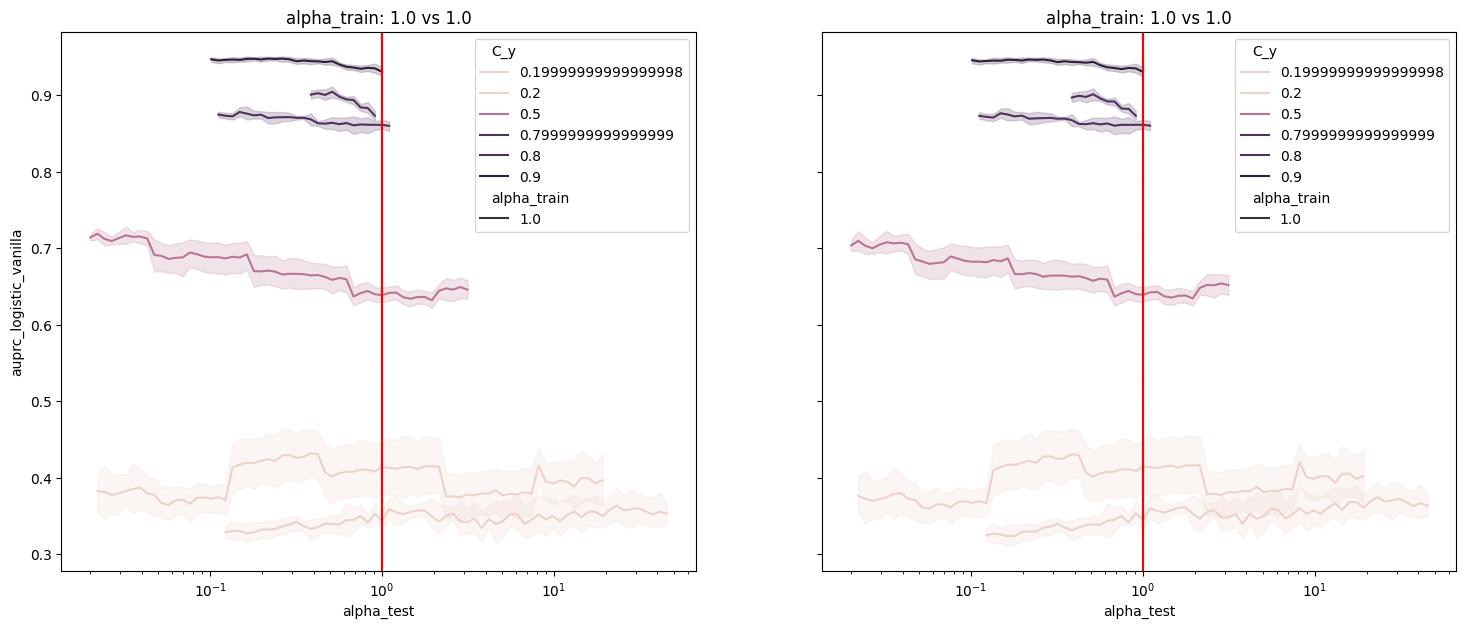

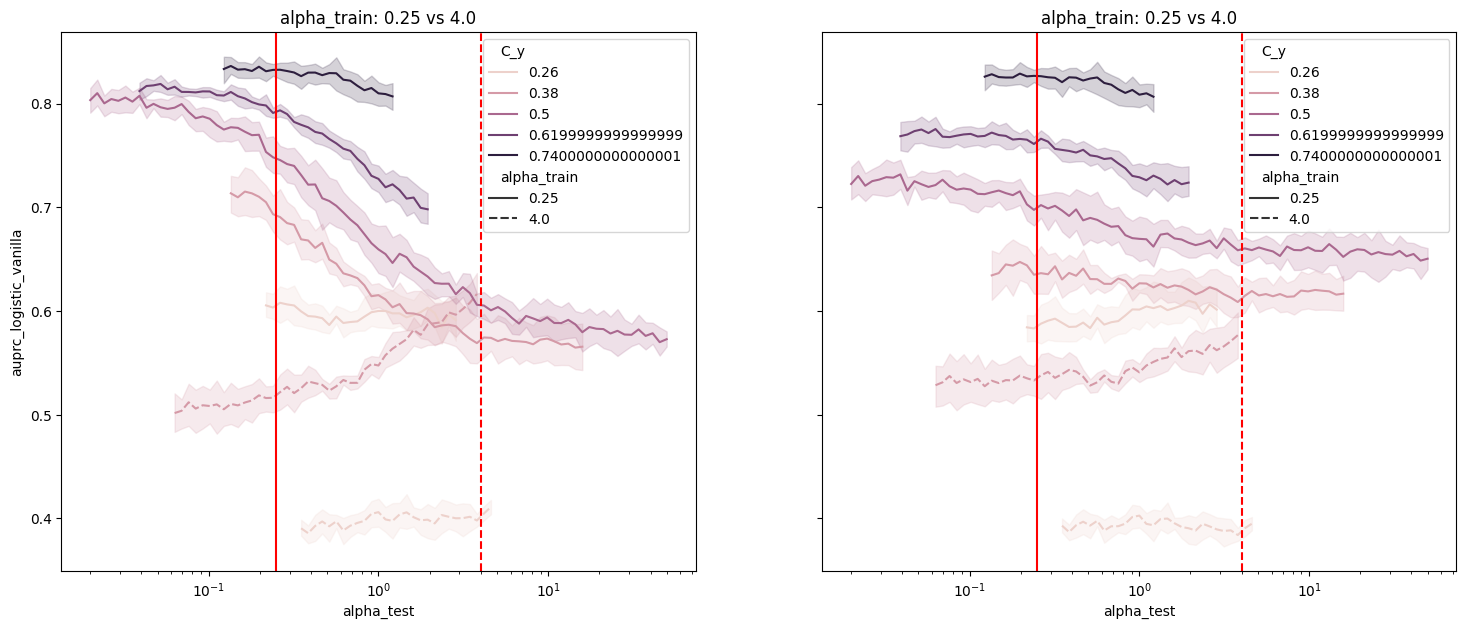

In [17]:
## One Figure for each row

_df = df.copy()
_df['alpha_train'] = _df['alpha_train'].round(4)

for alpha_train in sorted(set(_df['alpha_train'])):
    if alpha_train >= 1 :
        #alpha_train = 1.6  # if 1, then p(pos_train | z1) == p(pos_train | z0)
        reciprocal = round(1 / alpha_train, 4)
        fig, ax = plt.subplots(1,2, figsize=(18,7), sharey=True)
        
        sns.lineplot(data=_df[(_df['alpha_train'] == alpha_train) | (_df['alpha_train'] == reciprocal) ],x='alpha_test',y='auprc_logistic_vanilla', style='alpha_train', hue='C_y', ax=ax[0])
        sns.lineplot(data=_df[(_df['alpha_train'] == alpha_train) | (_df['alpha_train'] == reciprocal) ],x='alpha_test',y='auprc_logistic_confounder', style='alpha_train', hue='C_y', ax=ax[1])

        for i in range(2):
            ax[i].set_xscale('log')
            ax[i].axvline(alpha_train, color="red", linestyle='dashed')
            ax[i].axvline(reciprocal, color="red", linestyle='solid')
            ax[i].title.set_text("alpha_train: " + str(reciprocal) + " vs " + str(alpha_train))
            
        
        # plt.axvline(alpha_train,color='black')
        # plt.axvline(reciprocal, color='beige')
        # plt.title('alpha_train: ' + str(alpha_train))
        plt.show()

In [43]:
## Target for One setting

_df = df.copy()
_df['alpha_train'] = _df['alpha_train'].round(4)

# _df = _df.query("alpha_train.isin([3,0.3333])")
# _df = _df.query("C_y.isin([ 0.2, 0.48, 0.72])")

_df = _df.query("alpha_train.isin([6, 0.1667])")
tmp = _df.groupby("C_y").size().reset_index()

In [44]:
tmp[tmp.iloc[:,1]>150]

,C_y,0
5,0.225,280
6,0.250,155
7,0.250,155
8,0.275,320
9,0.300,175
10,0.300,175
11,0.325,185
12,0.325,185
13,0.350,390
14,0.375,410


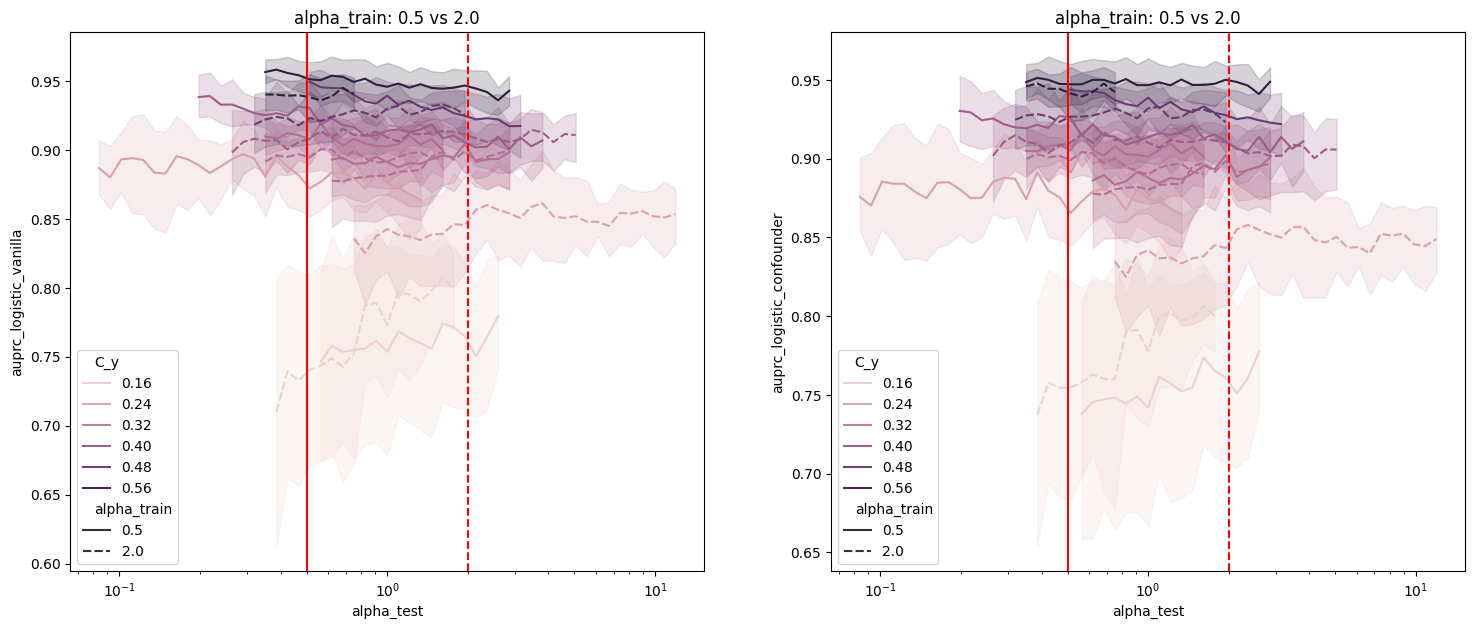

In [48]:
## Target for One setting

_df = df.copy()
_df['alpha_train'] = _df['alpha_train'].round(4)

# _df = _df.query("alpha_train.isin([3,0.3333])")
# _df = _df[np.round(_df['C_y'],3).isin([ 0.25, 0.34, 0.51])]

# _df = _df.query("alpha_train.isin([6,0.1667])")
# _df = _df[np.round(_df['C_y'],3).isin([ 0.225, 0.325, 0.4])]


_df = _df.query("alpha_train.isin([2,0.5])")
_df = _df[np.round(_df['C_y'],3).isin([0.155,  0.25, 0.36, 0.405, 0.5, 0.6])]


for alpha_train in sorted(set(_df['alpha_train'])):
    if alpha_train >= 1 :
        # alpha_train = 1.6  # if 1, then p(pos_train | z1) == p(pos_train | z0)
        reciprocal = round(1 / alpha_train, 4)
        fig, ax = plt.subplots(1,2, figsize=(18,7), sharex=True)

        _df_plt = _df[(_df['alpha_train'] == alpha_train) | (_df['alpha_train'] == reciprocal) ]
        # _df_plt = _df_plt.query("C_y.isin([ 0.16, 0.48, 0.72])")
        
        sns.lineplot(data=_df_plt, x='alpha_test',y='auprc_logistic_vanilla', style='alpha_train', hue='C_y', ax=ax[0])
        sns.lineplot(data=_df_plt, x='alpha_test',y='auprc_logistic_confounder', style='alpha_train', hue='C_y', ax=ax[1])

        for i in range(2):
            ax[i].set_xscale('log')
            ax[i].axvline(alpha_train, color="red", linestyle='dashed')
            ax[i].axvline(reciprocal, color="red", linestyle='solid')
            ax[i].title.set_text("alpha_train: " + str(reciprocal) + " vs " + str(alpha_train))
            # ax[i].set_ylim(0.7,1)
        
        # plt.axvline(alpha_train,color='black')
        # plt.axvline(reciprocal, color='beige')
        # plt.title('alpha_train: ' + str(alpha_train))
        plt.show()

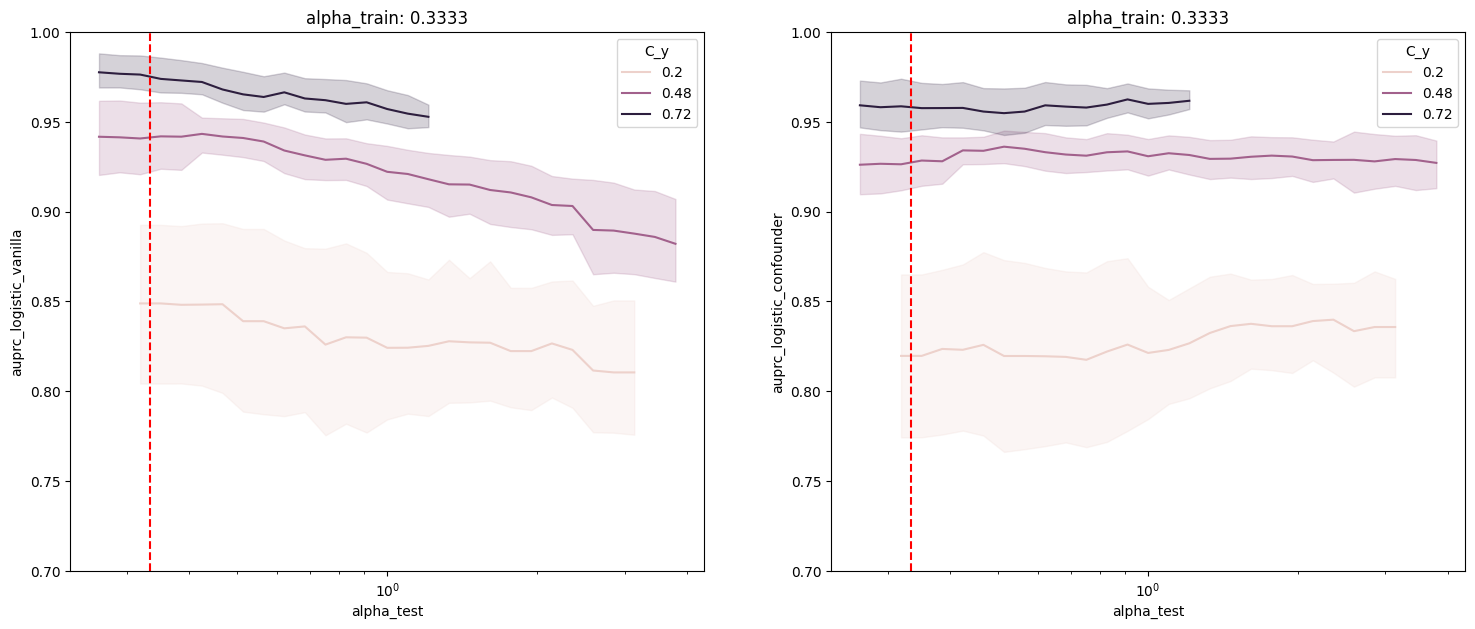

In [16]:
## Target for One setting -- no more reciprocal

_df = df.copy()
_df['alpha_train'] = _df['alpha_train'].round(4)


_df['C_y'] = _df['C_y'].round(4)

_df = _df.query("alpha_train.isin([0.3333])")

_df = _df.query("C_y.isin([ 0.2, 0.48, 0.72])")


for alpha_train in sorted(set(_df['alpha_train'])):
    
    # alpha_train = 1.6  # if 1, then p(pos_train | z1) == p(pos_train | z0)
    
    fig, ax = plt.subplots(1,2, figsize=(18,7))

    _df_plt = _df[(_df['alpha_train'] == alpha_train)]

    sns.lineplot(data=_df_plt, x='alpha_test',y='auprc_logistic_vanilla', hue='C_y', ax=ax[0])
    sns.lineplot(data=_df_plt, x='alpha_test',y='auprc_logistic_confounder',  hue='C_y', ax=ax[1])

    for i in range(2):
        ax[i].set_xscale('log')
        ax[i].axvline(alpha_train, color="red", linestyle='dashed')
        ax[i].title.set_text("alpha_train: "  + str(alpha_train))
        ax[i].set_ylim(0.7,1)

    # plt.axvline(alpha_train,color='black')
    # plt.axvline(reciprocal, color='beige')
    # plt.title('alpha_train: ' + str(alpha_train))
    plt.show()

In [25]:
## Target for One setting -- no more reciprocal
## Plotting: save coef
## SAVE!!! plot


_df = df.copy()
_df['alpha_train'] = _df['alpha_train'].round(4)


_df['C_y'] = _df['C_y'].round(4)

_df = _df.query("alpha_train.isin([0.3333])")

if dataset_name == 'hatespeech':
    # _df = _df.query("C_y.isin([ 0.24, 0.54, 0.84])")
    _df = _df.query("C_y.isin([ 0.36, 0.44, 0.52])")
    ylim = 0.5,1
    
    loc_legend = "best"
    loc_coef_x = -100
    loc_coef_y = -2 # order number from sorted ascending list
    xticks = [0.05, 0.25, 1, 4, 20]
elif dataset_name == 'shac':
    _df = _df.query("C_y.isin([ 0.2, 0.48, 0.72])")
    ylim = 0.6,1
    # loc_legend = "lower left"
    loc_legend = "best"
    loc_coef_x = -46
    loc_coef_y = -1 # order number from sorted ascending list
    xticks = [0.25, 0.5, 1,2,4]

palette = ["#648FFF", "#FFB000", "#DC267F"]


for alpha_train in sorted(set(_df['alpha_train'])):
    
    # alpha_train = 1.6  # if 1, then p(pos_train | z1) == p(pos_train | z0)
    
    fig, ax = plt.subplots(1,2, figsize=(10,4))

    _df_plt = _df[(_df['alpha_train'] == alpha_train)]

    sns.lineplot(data=_df_plt, x='alpha_test',y='auprc_logistic_vanilla', hue='C_y', palette=palette, style='C_y', ax=ax[0])
    sns.lineplot(data=_df_plt, x='alpha_test',y='auprc_logistic_confounder',  hue='C_y', palette=palette, style='C_y', ax=ax[1])
    ax[0].title.set_text("Unadjusted")
    ax[1].title.set_text("Adjusted")
    
    # ax[0].legend(loc="lower left", title=r'$C_y$')
    # ax[1].legend(loc="best", title=r'$C_y$')
    
    for i in range(2):
        ax[i].set_xscale('log')
        ax[i].axvline(alpha_train, color="red", linestyle='dashed')
        ax[i].set_ylim(ylim)
        
        ax[i].set_xlabel(r"$\alpha_{test}$")
        ax[i].set_ylabel("AUPRC")
        
        ax[i].legend(loc=loc_legend, title=r'$C_y$')
        ax[i].xaxis.set_major_formatter(ScalarFormatter())
        ax[i].minorticks_off()
        ax[i].set_xticks(xticks)


    for item, color in zip(_df_plt.groupby('C_y'), palette):
        #item[1] is a grouped data frame
        
        for iy, ylabel in enumerate(['auprc_logistic_vanilla', 'auprc_logistic_confounder']):
            
            
            
            x=sorted(item[1]['alpha_test'])[loc_coef_x]
            y=sorted(item[1][item[1]['alpha_test'] == x][ylabel])[loc_coef_y]
            
            if dataset_name == "shac":
                if iy == 0:
                    if item[1].iloc[0]['C_y'] in [0.48, 0.72]:
                        y=sorted(item[1][item[1]['alpha_test'] == x][ylabel])[loc_coef_y-1]
                    elif item[1].iloc[0]['C_y'] == 0.2:
                        x=sorted(item[1]['alpha_test'])[loc_coef_x-40]
                        y=sorted(item[1][item[1]['alpha_test'] == x][ylabel])[loc_coef_y-4]
                    
                    
            coef = get_coef(x=list(item[1]['alpha_test']), y=list(item[1][ylabel]))

            ax[iy].text(x, y, f"coef={coef:.3f}", color=color)
        
    

# plt.show()
plt.savefig(f"{fname}.png", dpi=600)
plt.close()

In [10]:
df.alpha_train.unique()

array([3.        , 5.        , 6.        , 1.        , 4.5       ,
       0.33333333, 2.        , 2.33333333, 3.        , 1.5       ,
       0.2       , 0.6       , 0.8       , 0.16666667, 0.5       ,
       0.66666667, 1.5       , 0.42857143, 1.14285714, 0.75      ,
       0.22222222, 0.33333333, 0.55555556, 0.66666667])

In [14]:
pd.set_option('display.max_rows', 500)

print(df.groupby(['C_y', 'alpha_train', ]).size())

C_y   alpha_train
0.24  0.500000       235
      2.000000       235
0.36  0.333333       380
      3.000000       225
      0.500000       195
0.44  0.333333       305
      0.800000       115
      1.250000       305
      0.250000       305
      0.400000       185
      1.500000       185
0.52  0.333333       180
      0.666667       265
      1.200000       180
0.54  1.200000       195
0.84  0.666667        80
dtype: int64


In [28]:
## Target for One setting -- For Bigger Ones!!!
## Plotting: save coef
## SAVE!!! plot

a_train = [3]

_df = df.copy()
_df['alpha_train'] = _df['alpha_train'].round(4)


_df['C_y'] = _df['C_y'].round(4)

_df = _df.query(f"alpha_train.isin({a_train})")

if dataset_name == 'hatespeech':
    # _df = _df.query("C_y.isin([ 0.24, 0.54, 0.84])")
    # _df = _df.query("C_y.isin([ 0.36, 0.44, 0.52])")
    ylim = 0.4,1
    
    loc_legend = "best"
    loc_coef_x = -100
    loc_coef_y = -2 # order number from sorted ascending list
    xticks = [0.05, 0.25, 1, 4, 20]
elif dataset_name == 'shac':
    _df = _df.query("C_y.isin([ 0.2, 0.48, 0.72])")
    ylim = 0.6,1
    # loc_legend = "lower left"
    loc_legend = "best"
    loc_coef_x = -46
    loc_coef_y = -1 # order number from sorted ascending list
    xticks = [0.25, 0.5, 1,2,4]

palette = ["#648FFF", "#FFB000", "#DC267F"]


for alpha_train in sorted(set(_df['alpha_train'])):
    
    # alpha_train = 1.6  # if 1, then p(pos_train | z1) == p(pos_train | z0)
    
    fig, ax = plt.subplots(1,2, figsize=(10,4))

    _df_plt = _df[(_df['alpha_train'] == alpha_train)]

    sns.lineplot(data=_df_plt, x='alpha_test',y='auprc_logistic_vanilla', hue='C_y', palette=palette, style='C_y', ax=ax[0])
    sns.lineplot(data=_df_plt, x='alpha_test',y='auprc_logistic_confounder',  hue='C_y', palette=palette, style='C_y', ax=ax[1])
    ax[0].title.set_text("Unadjusted")
    ax[1].title.set_text("Adjusted")
    
    # ax[0].legend(loc="lower left", title=r'$C_y$')
    # ax[1].legend(loc="best", title=r'$C_y$')
    
    for i in range(2):
        ax[i].set_xscale('log')
        ax[i].axvline(alpha_train, color="red", linestyle='dashed')
        ax[i].set_ylim(ylim)
        
        ax[i].set_xlabel(r"$\alpha_{test}$")
        ax[i].set_ylabel("AUPRC")
        
        ax[i].legend(loc=loc_legend, title=r'$C_y$')
        ax[i].xaxis.set_major_formatter(ScalarFormatter())
        ax[i].minorticks_off()
        ax[i].set_xticks(xticks)


    for item, color in zip(_df_plt.groupby('C_y'), palette):
        #item[1] is a grouped data frame
        
        for iy, ylabel in enumerate(['auprc_logistic_vanilla', 'auprc_logistic_confounder']):
            
            
            
            x=sorted(item[1]['alpha_test'])[loc_coef_x]
            y=sorted(item[1][item[1]['alpha_test'] == x][ylabel])[loc_coef_y]
            
            if dataset_name == "shac":
                if iy == 0:
                    if item[1].iloc[0]['C_y'] in [0.48, 0.72]:
                        y=sorted(item[1][item[1]['alpha_test'] == x][ylabel])[loc_coef_y-1]
                    elif item[1].iloc[0]['C_y'] == 0.2:
                        x=sorted(item[1]['alpha_test'])[loc_coef_x-40]
                        y=sorted(item[1][item[1]['alpha_test'] == x][ylabel])[loc_coef_y-4]
                    
                    
            coef = get_coef(x=list(item[1]['alpha_test']), y=list(item[1][ylabel]))

            ax[iy].text(x, y, f"coef={coef:.3f}", color=color)
        
    

# plt.show()
outname = f"{fname}_alphaTrain_" + "_".join([str(x) for x in a_train]) + ".png"
plt.savefig(outname, dpi=600)
plt.close()

In [18]:
outname

'../output/regressionHateSpeechBalanceAlpha/LLaMaAverageV2_7B_ntest_1000_l2_C1_V10_alphaTrain_3.png'

In [18]:
_df_plt.columns

Index(['auprc_logistic_confounder', 'auprc_logistic_vanilla',
       'auprc_logistic_confounder_df0', 'auprc_logistic_confounder_df1',
       'precision_confounder', 'recall_confounder', 'f1_confounder',
       'precision_confounder_df0', 'recall_confounder_df0',
       'f1_confounder_df0', 'precision_confounder_df1',
       'recall_confounder_df1', 'f1_confounder_df1',
       'auprc_logistic_vanilla_df0', 'auprc_logistic_vanilla_df1',
       'precision_vanilla', 'recall_vanilla', 'f1_vanilla',
       'precision_vanilla_df0', 'recall_vanilla_df0', 'f1_vanilla_df0',
       'precision_vanilla_df1', 'recall_vanilla_df1', 'f1_vanilla_df1',
       'p_pos_train_z0', 'p_pos_train_z1', 'p_pos_train', 'p_pos_test',
       'p_mix_z0', 'p_mix_z1', 'alpha_train', 'alpha_test', 'p_pos_test_z0',
       'p_pos_test_z1', 'C_y', 'C_z', 'n_train', 'n_test', 'n_z0_pos_train',
       'n_z0_neg_train', 'n_z0_pos_test', 'n_z0_neg_test', 'n_z1_pos_train',
       'n_z1_neg_train', 'n_z1_pos_test', 'n_z1_neg_t

In [25]:
_df_plt.p_mix_z0.unique()

array([0.8, 0.6, 0.4])

In [16]:
_df_plt.alpha_test.describe()

count    865.000000
mean       2.294432
std        4.096710
min        0.018260
25%        0.135131
50%        0.564474
75%        2.143589
max       23.225154
Name: alpha_test, dtype: float64

In [19]:
max(_df_plt.alpha_test)

23.225154419887872

In [16]:
fname

'../output/regressionHateSpeechBalanceAlpha/LLaMaAverageV2_13B_ntest_1000_l2_C1_V10'

In [33]:
_df = df.copy()
_df['alpha_train'] = _df['alpha_train'].round(4)

_df = _df.query("alpha_train.isin([0.3333])")

In [34]:
list(sorted(_df.C_y.unique()))

[0.21000000000000005,
 0.22000000000000003,
 0.23,
 0.24000000000000002,
 0.25000000000000006,
 0.26000000000000006,
 0.27,
 0.2800000000000001,
 0.29000000000000004,
 0.5200000000000001,
 0.54,
 0.5600000000000002,
 0.5800000000000001,
 0.81,
 0.8400000000000001,
 0.87]

In [151]:

_df = df.copy()
_df['alpha_train'] = _df['alpha_train'].round(4)


_df['C_y'] = _df['C_y'].round(4)

_df = _df.query("alpha_train.isin([0.3333])")

_df = _df.query("C_y.isin([ 0.2, 0.48, 0.72])")




_df_plt = _df[(_df['alpha_train'] == alpha_train)]
_df_plt = _df_plt.query("C_y.isin([0.72])")

X = _df_plt['alpha_test']
X = np.log(X)
X = sm.add_constant(X)
Y = _df_plt['auprc_logistic_confounder']


In [161]:
lr_fit = sm.OLS(Y, X)
results = lr_fit.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.190
Model:                            OLS   Adj. R-squared:                  0.183
Method:                 Least Squares   F-statistic:                     28.80
Date:                Sun, 17 Sep 2023   Prob (F-statistic):           3.84e-07
Time:                        23:59:56   Log-Likelihood:                 196.44
No. Observations:                 125   AIC:                            -388.9
Df Residuals:                     123   BIC:                            -383.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.7913      0.005    174.580      0.0

In [162]:
results.params

array([ 0.79126076, -0.03539087])

In [154]:
results.params['alpha_test']

-0.007149842659798075

## Three Plots

In [14]:
fname

'../output/DistilBERT_SHACBalanceAlpha_10Pct_Fix_RandomPermute_ShorterVersion_1_5/DistilBERT_ntest_500'

In [ ]:
_df.alpha_train.unique()

In [26]:
_df.C_y.unique()

array([0.1 , 0.14, 0.15, 0.16, 0.17, 0.18, 0.2 , 0.22, 0.2 , 0.23, 0.24,
       0.25, 0.26, 0.28, 0.29, 0.26, 0.27, 0.23, 0.3 , 0.32, 0.33, 0.34,
       0.36, 0.36, 0.38, 0.4 , 0.37, 0.31, 0.34, 0.32, 0.39, 0.37, 0.35,
       0.4 , 0.4 , 0.41, 0.42, 0.43, 0.44, 0.43, 0.46, 0.48, 0.45, 0.38,
       0.3 , 0.41, 0.35, 0.29, 0.46, 0.44, 0.48, 0.47, 0.5 , 0.52, 0.54,
       0.25, 0.36, 0.51, 0.34, 0.45, 0.31, 0.55])

In [24]:
_df.query("alpha_train == 3.0").alpha_test.unique()

array([0.21762914, 0.56447393, 1.4641    , 3.79749834, 9.84973268,
       0.06303941])

In [ ]:
pd.set_option('display.max_rows', None)
_df.groupby("alpha_test").size()

In [12]:
"""
auprc_logistic_confounder
auprc_logistic_known_source
auprc_logistic_noPermute
"""

'\nauprc_logistic_confounder\nauprc_logistic_known_source\nauprc_logistic_noPermute\n'

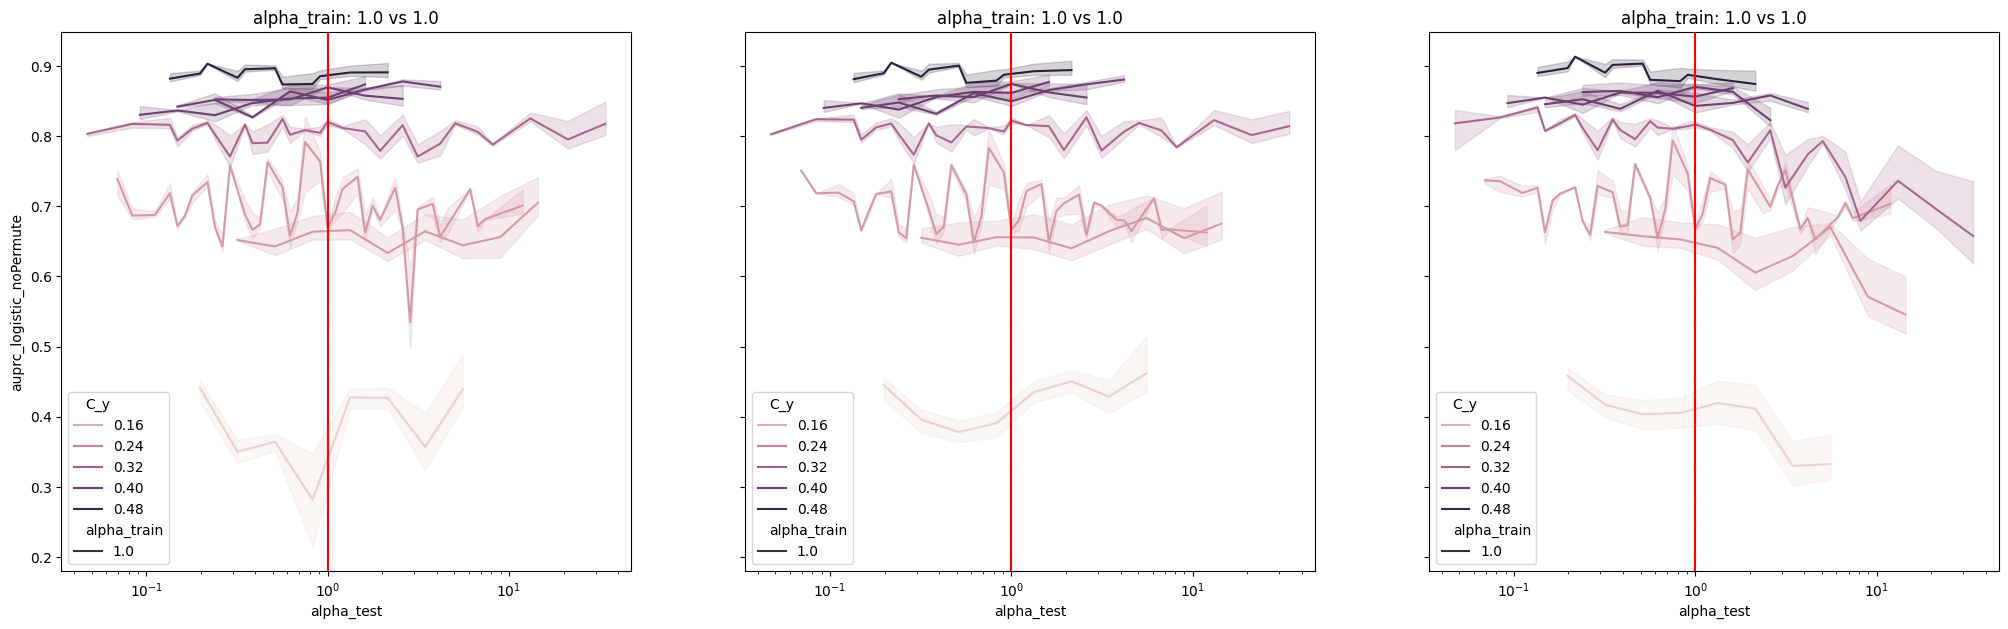

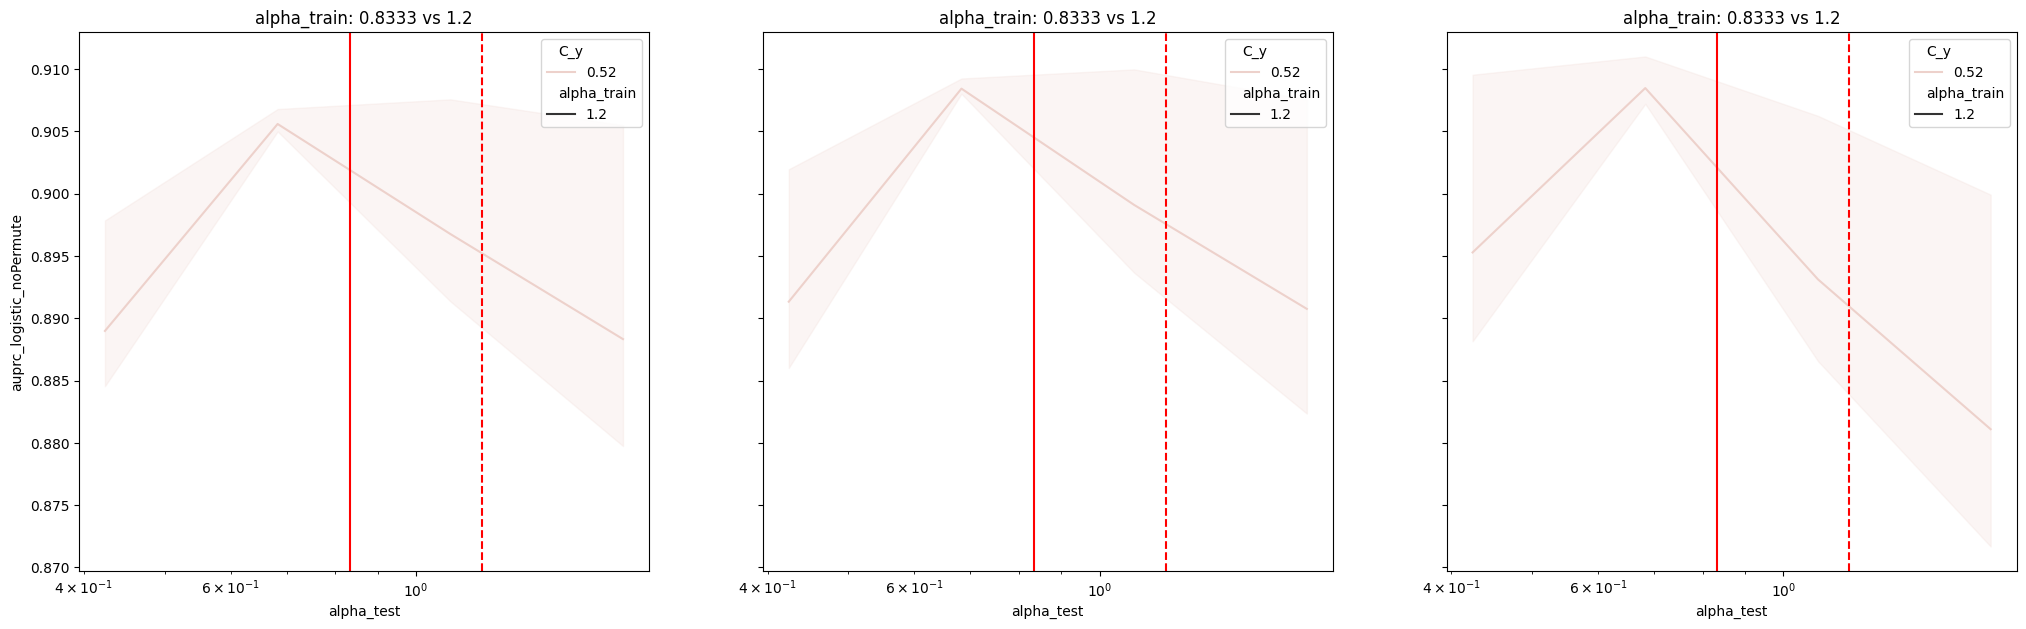

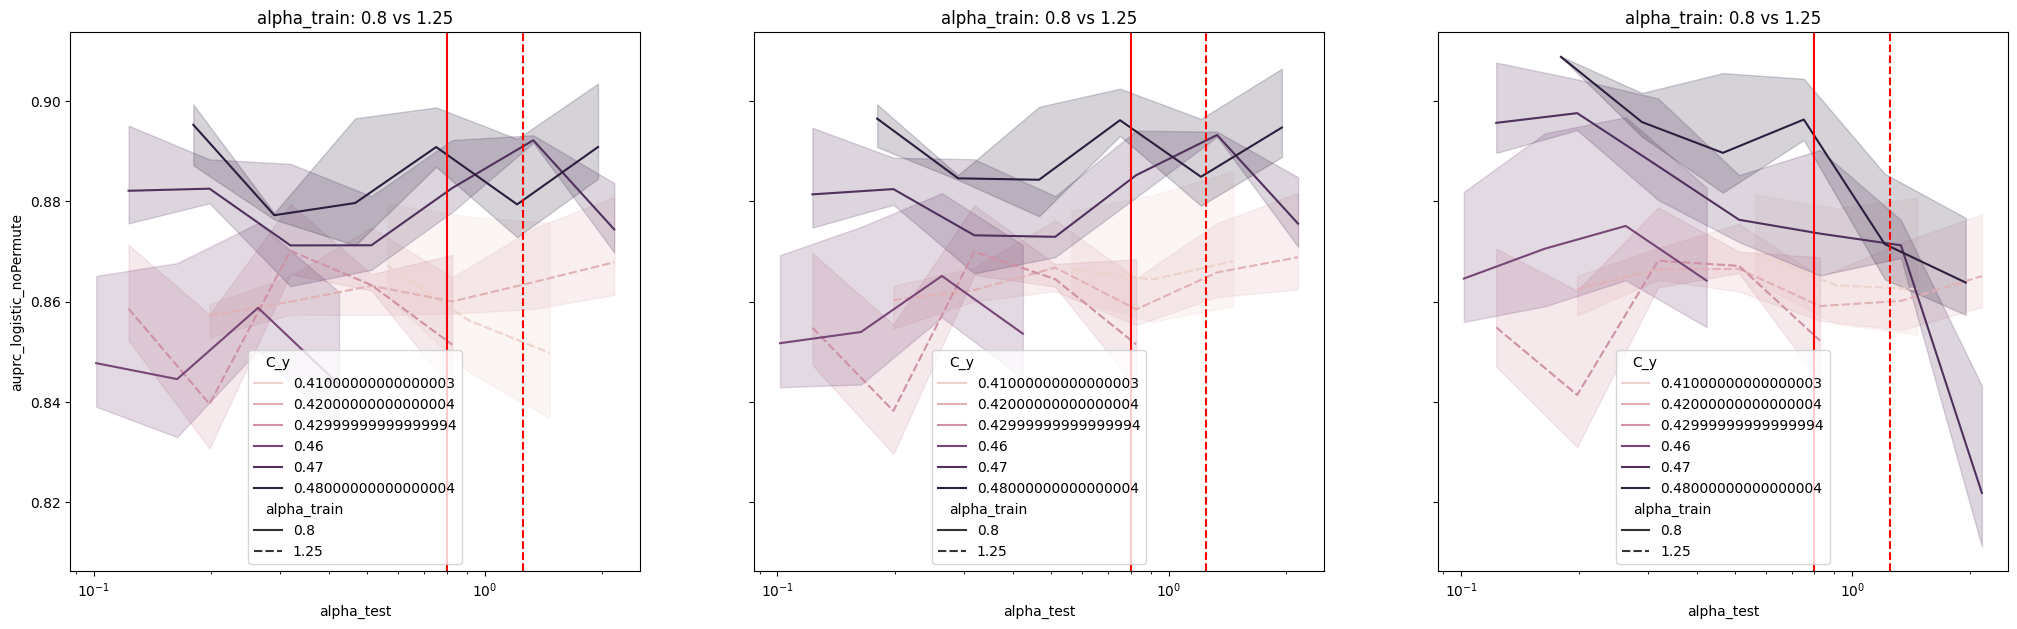

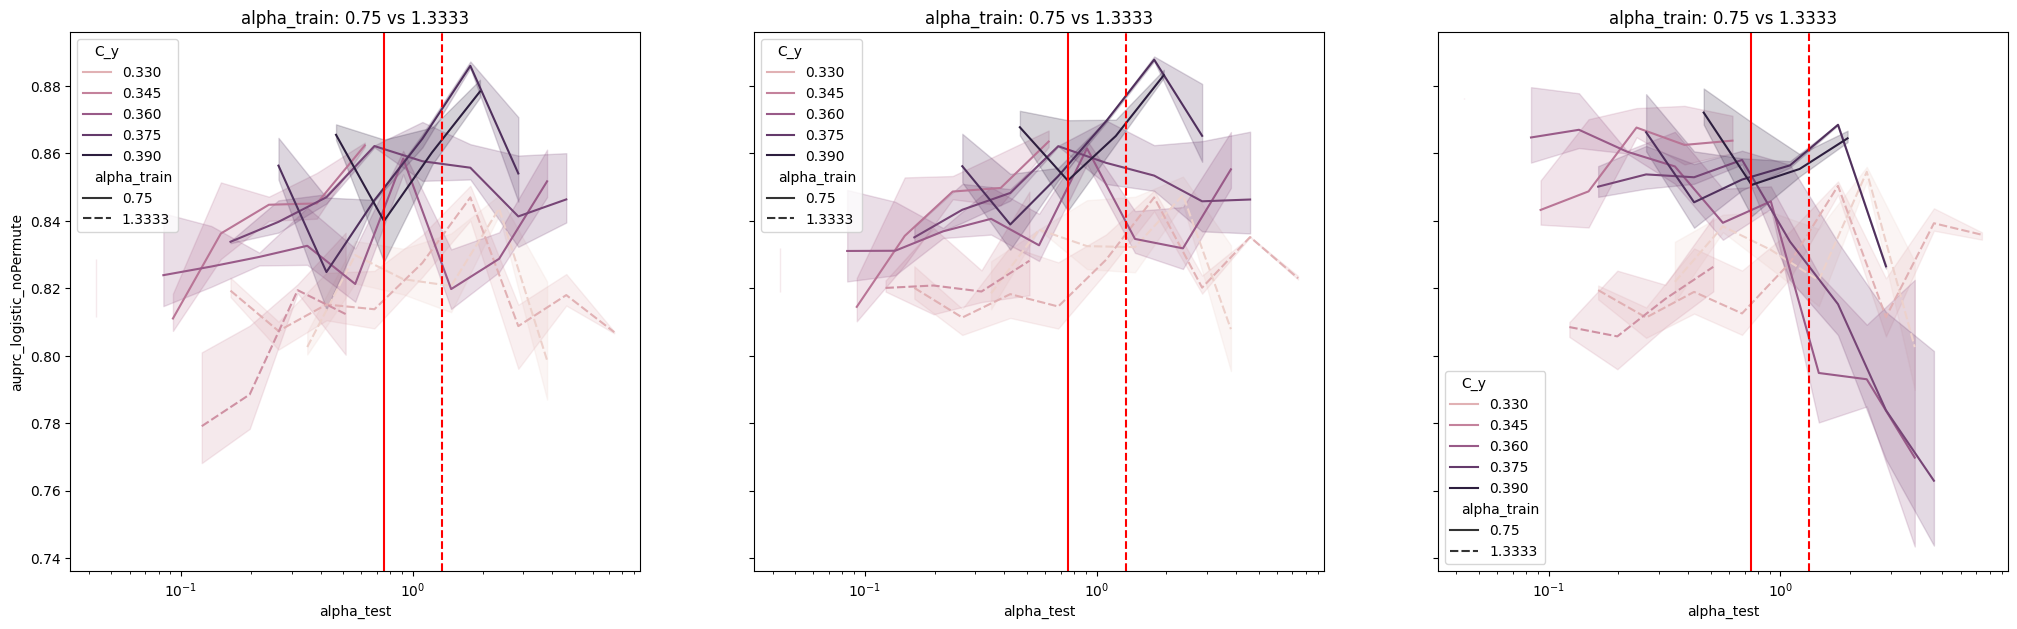

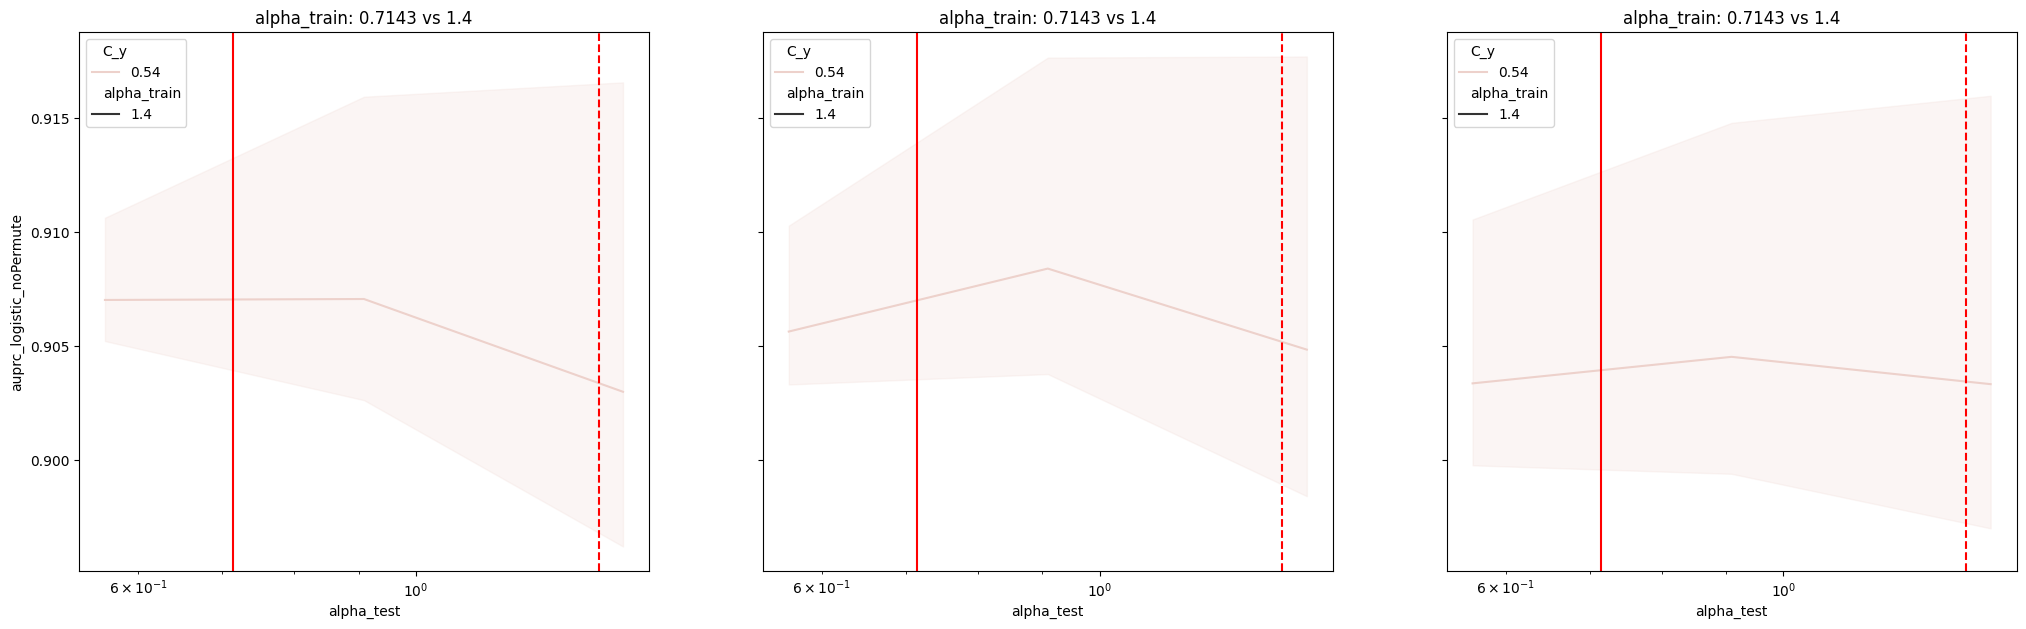

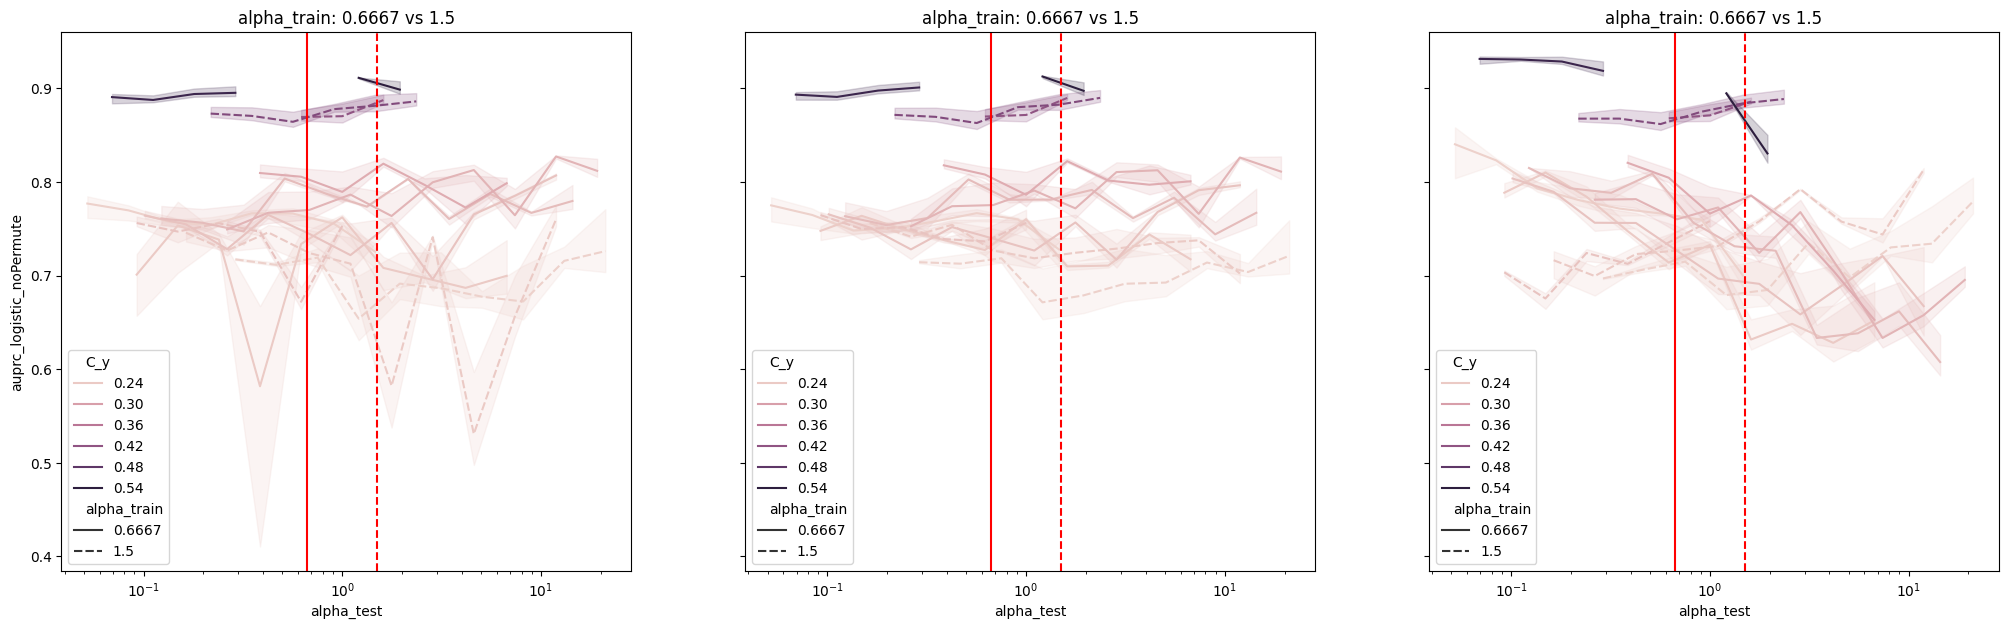

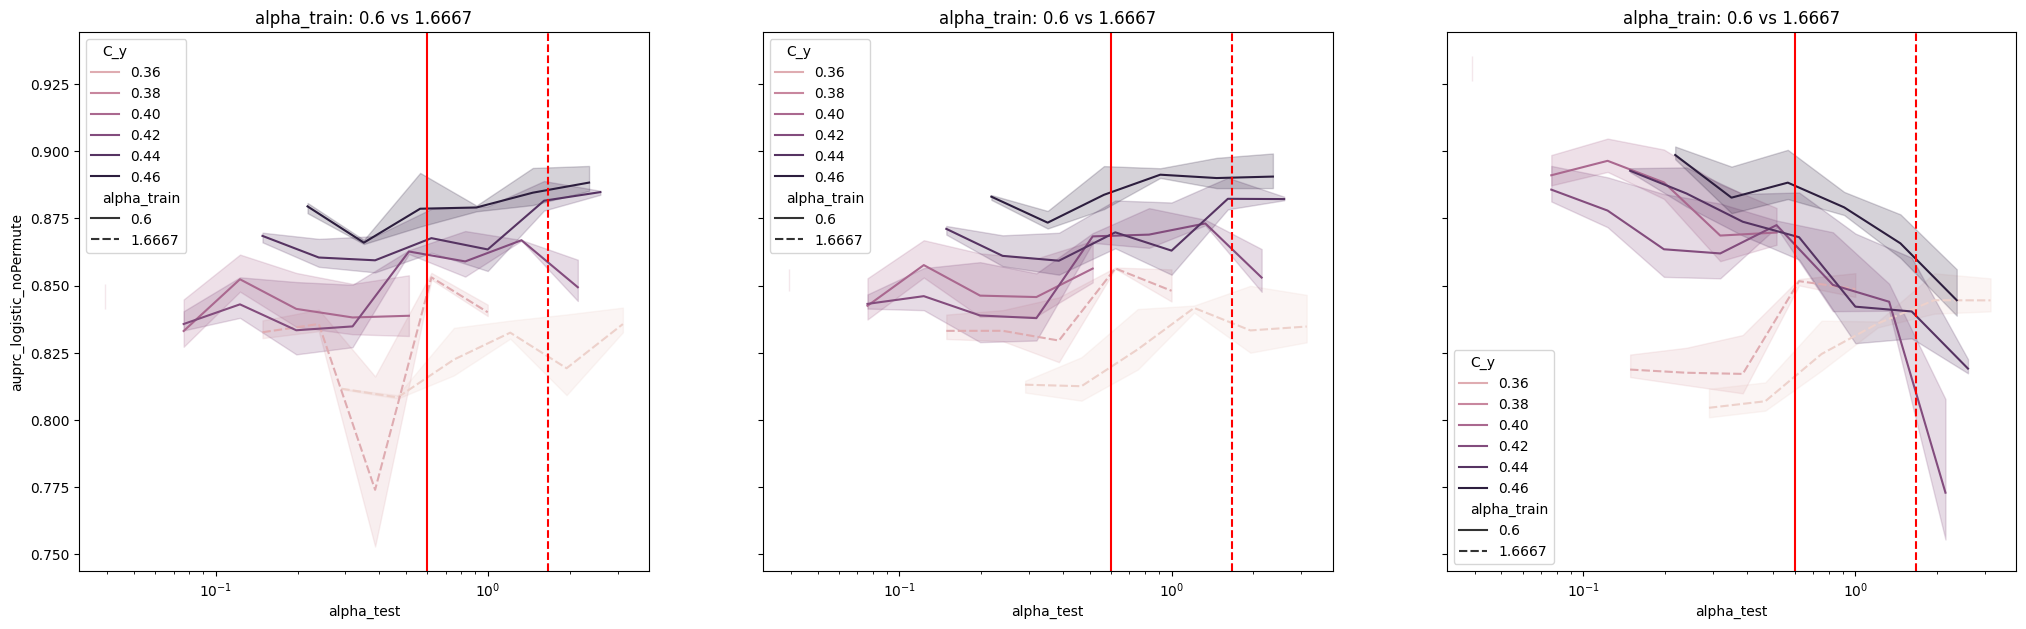

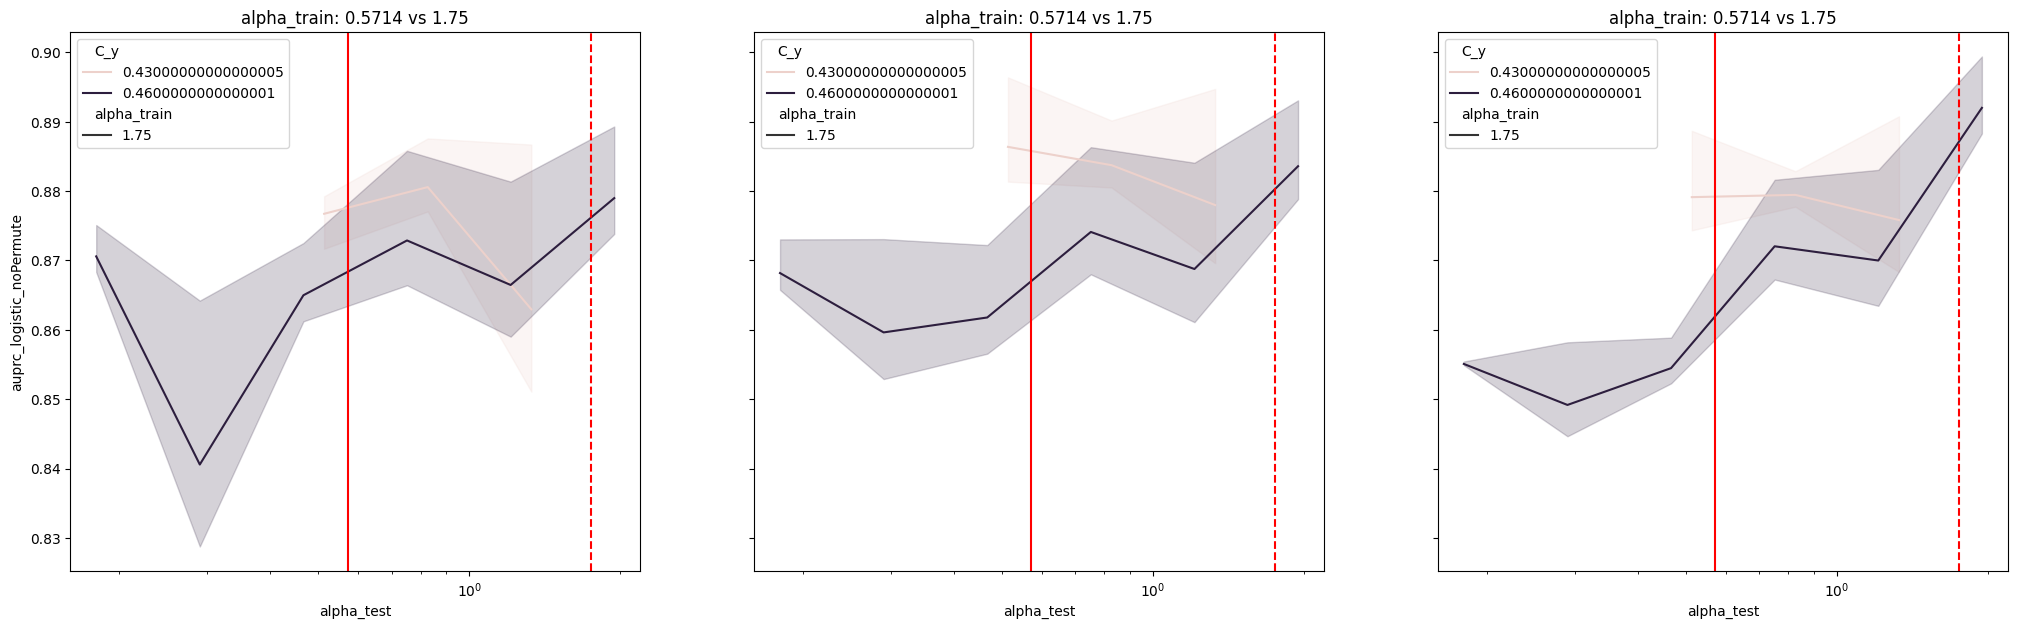

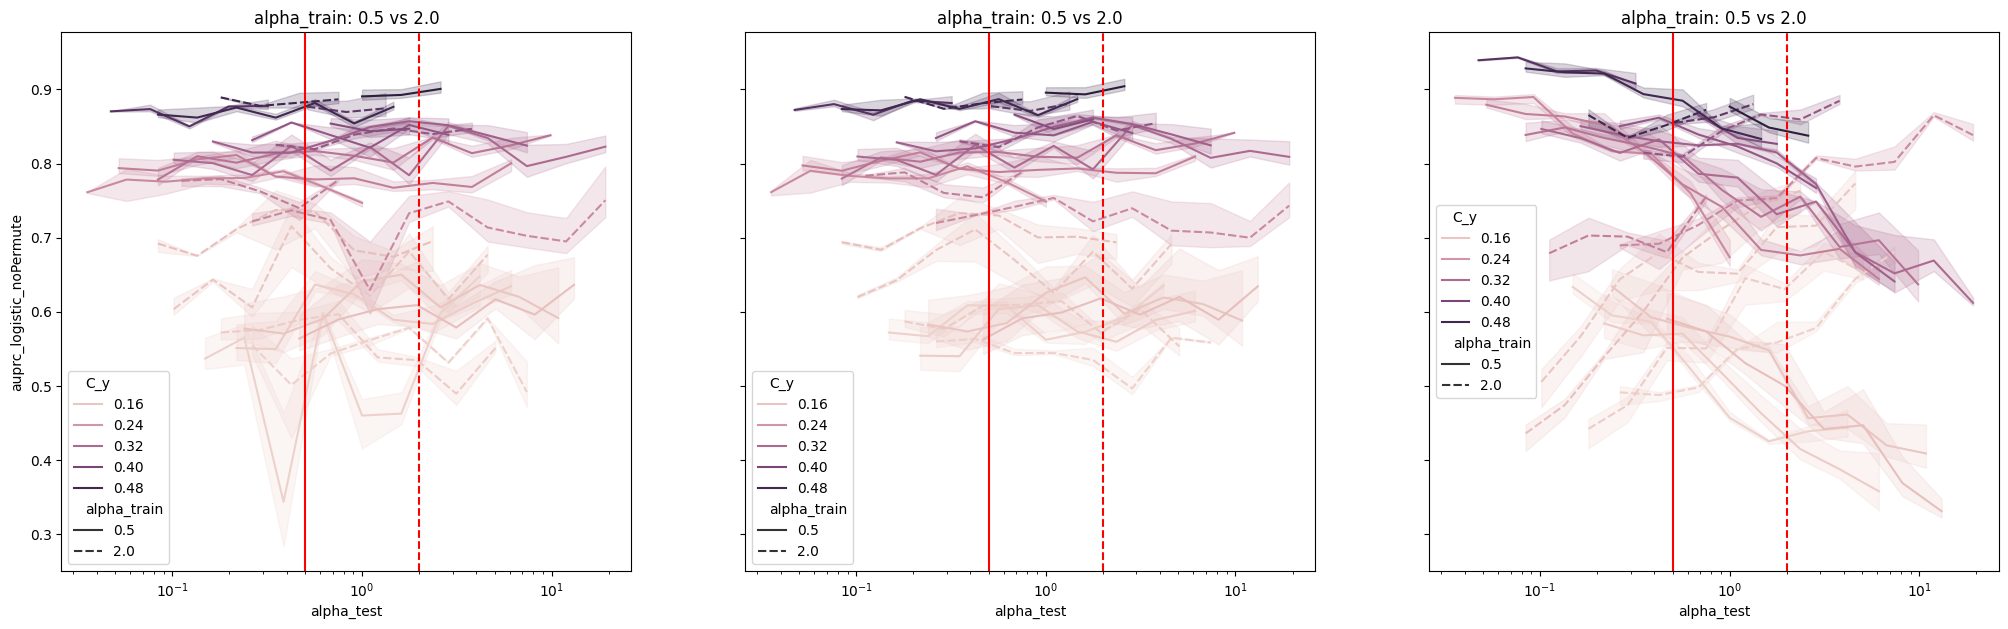

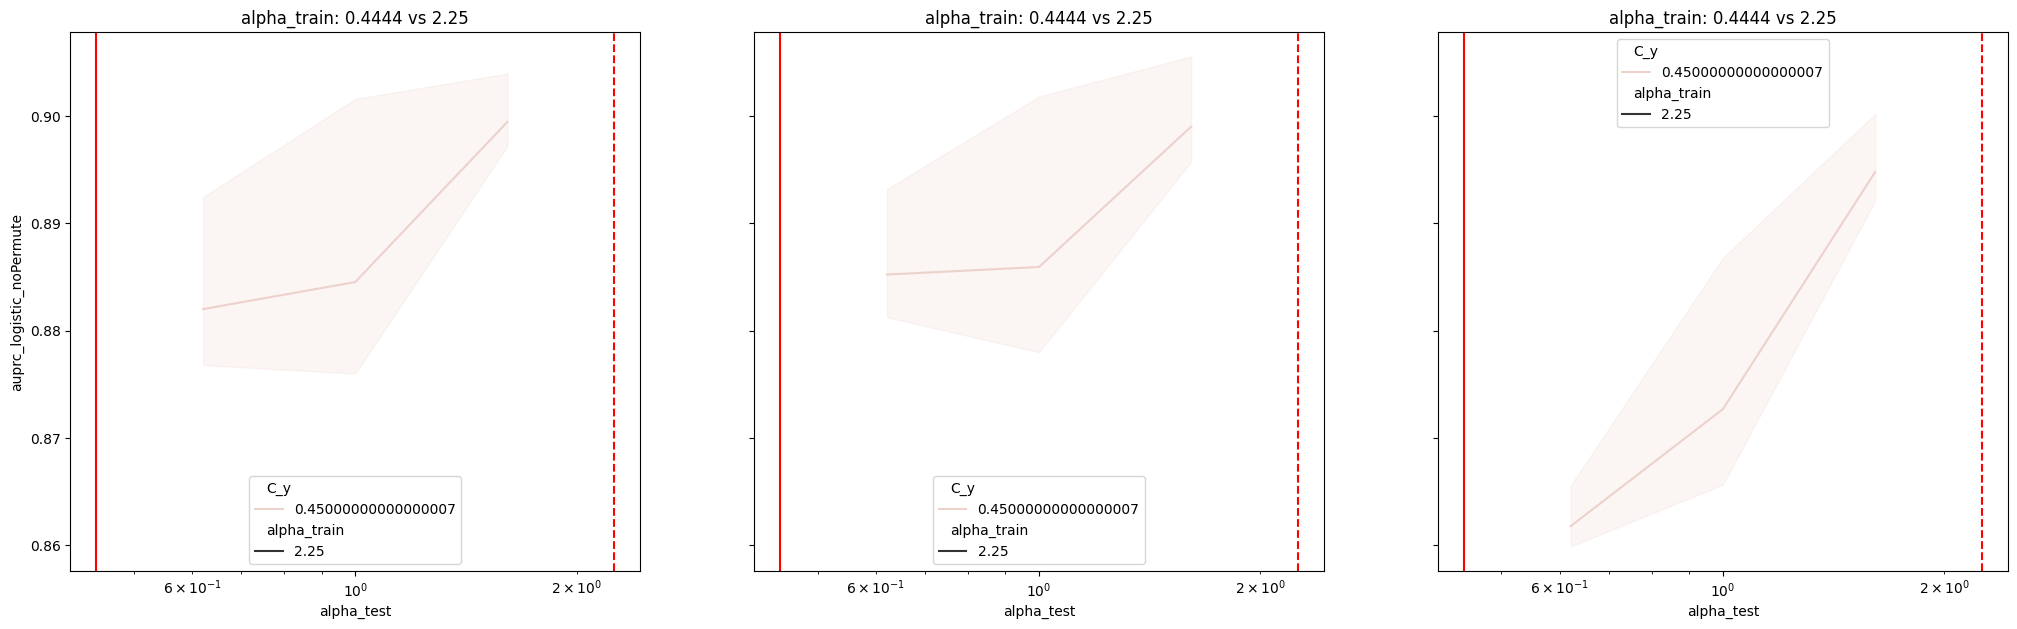

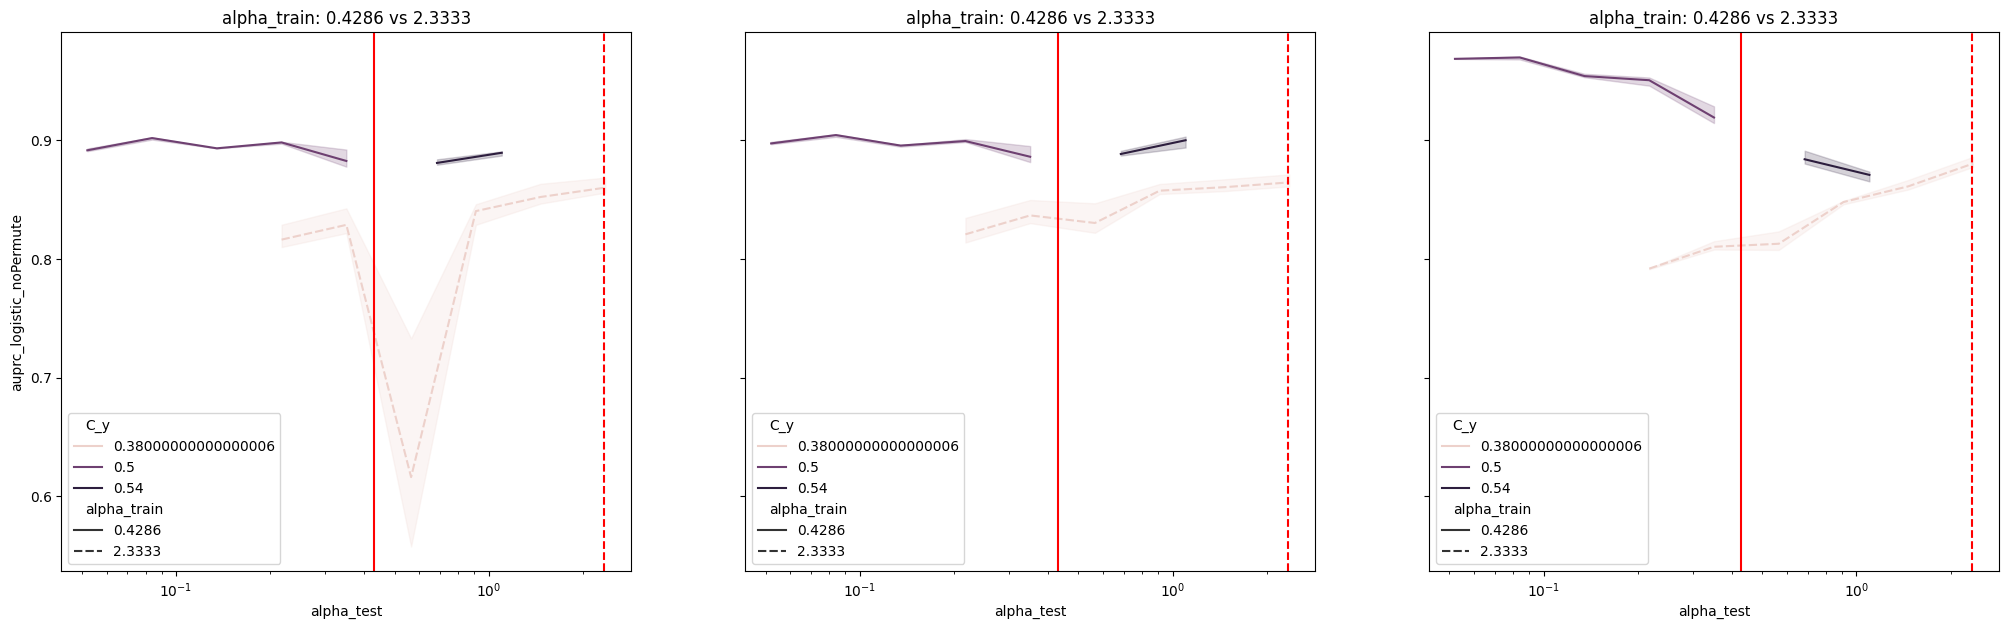

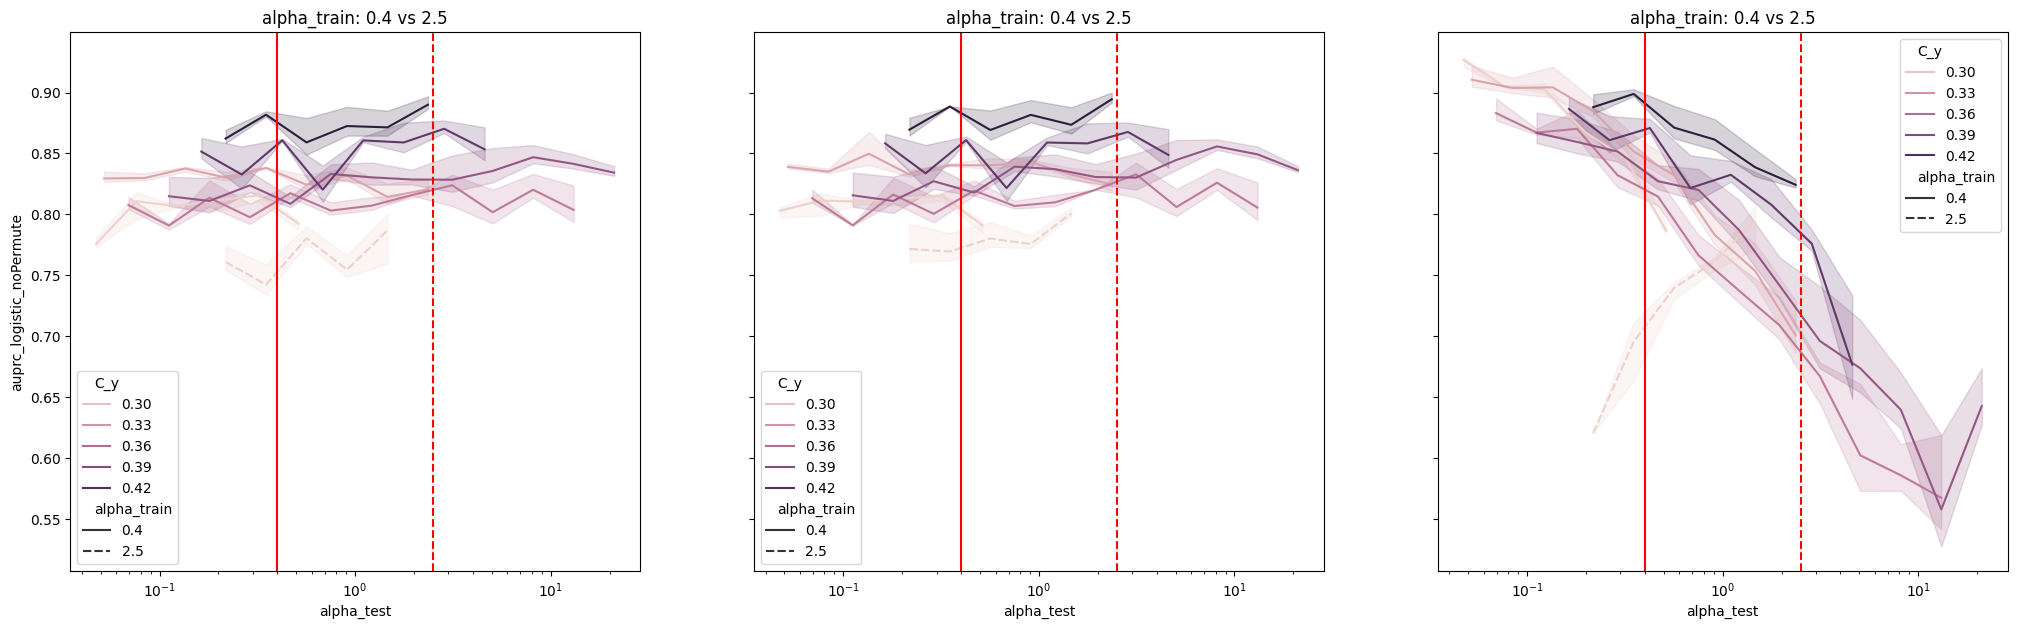

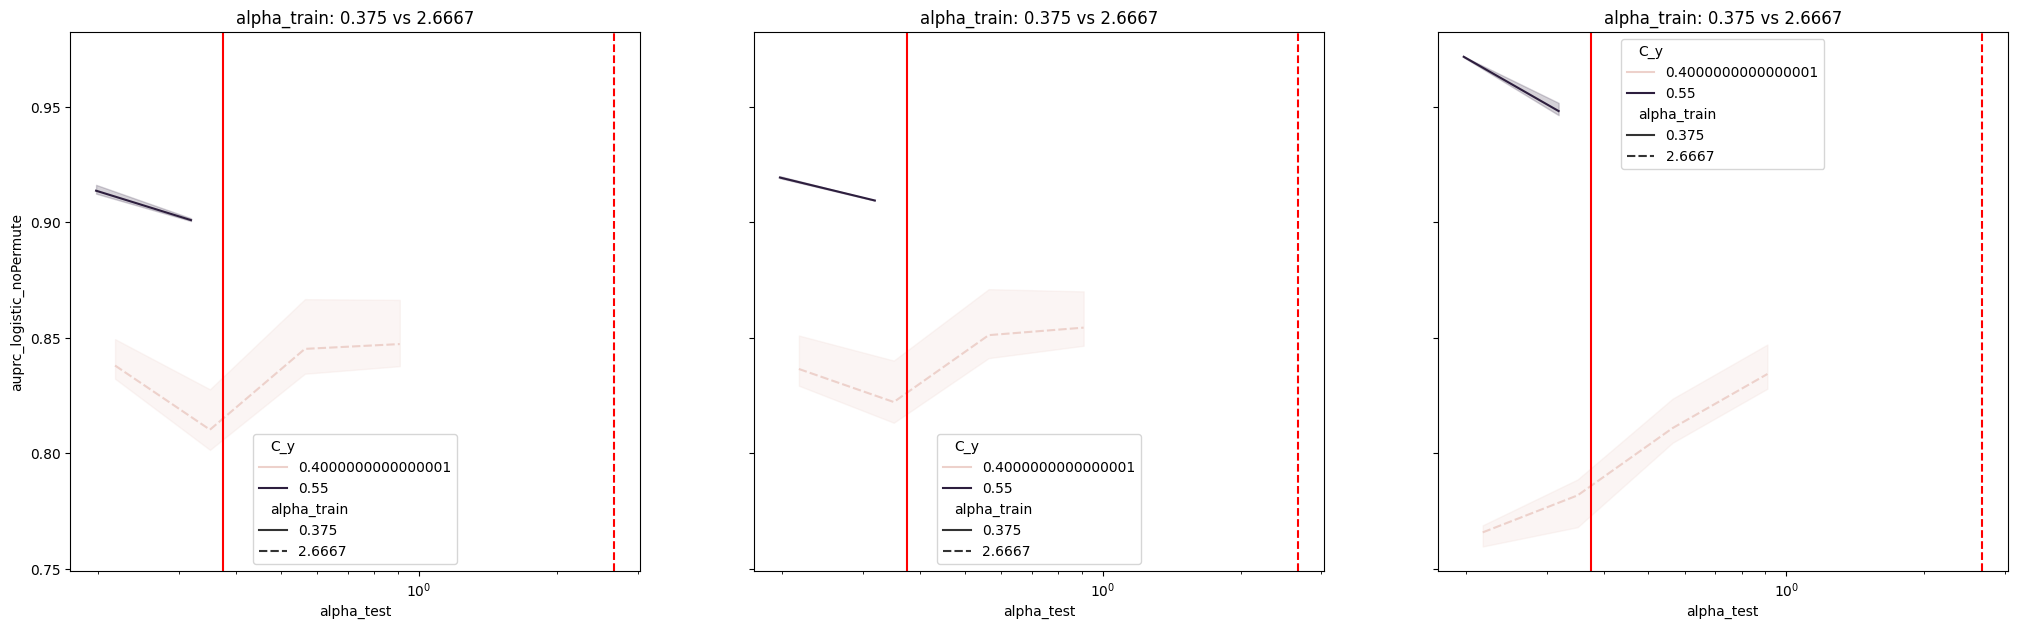

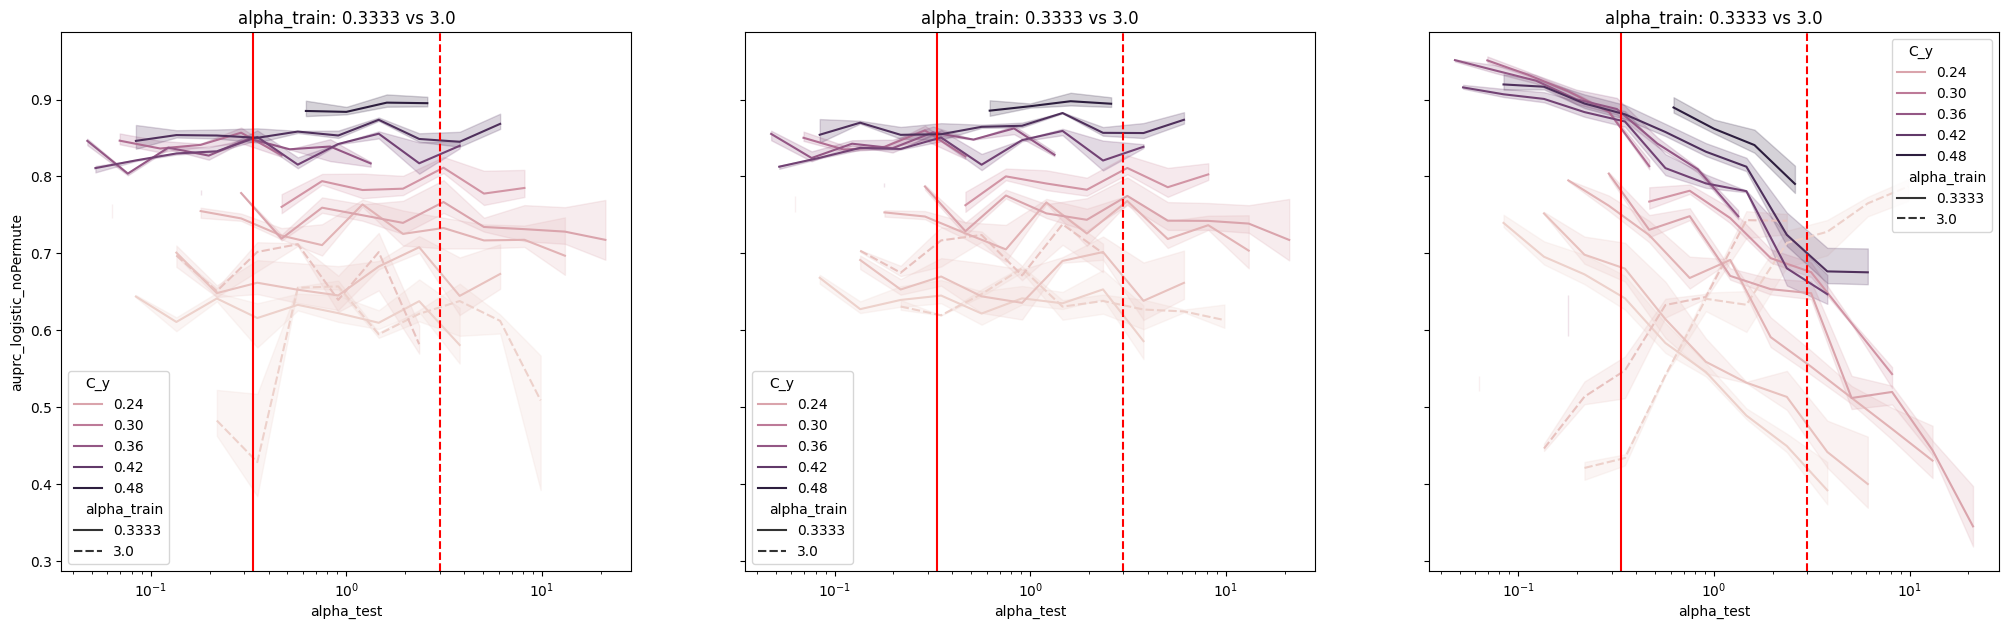

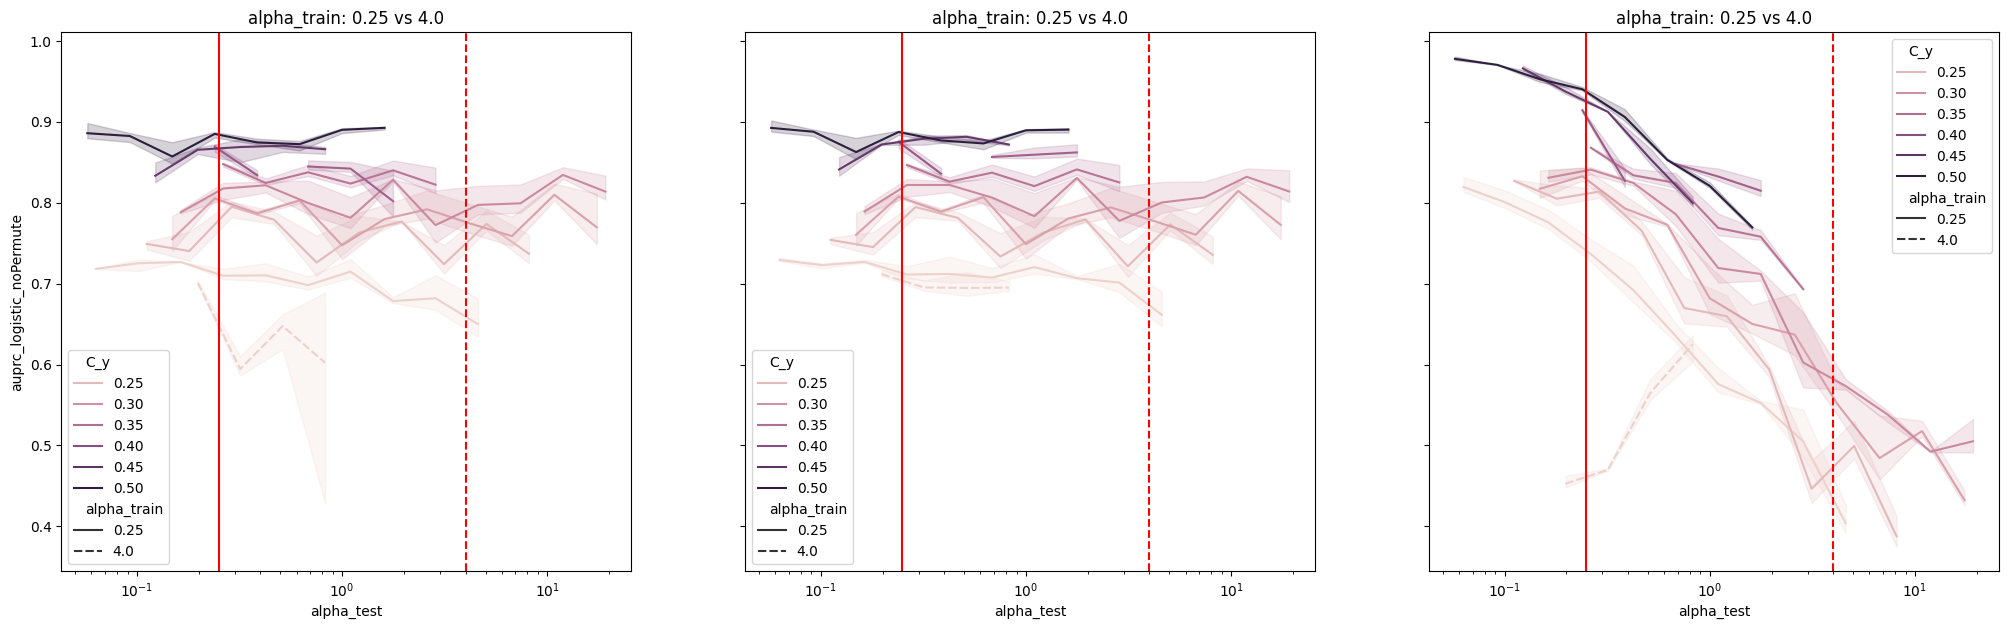

In [16]:
## One Figure for each row

_df = df.copy()
_df['alpha_train'] = _df['alpha_train'].round(4)

for alpha_train in sorted(set(_df['alpha_train'])):
    if alpha_train >= 1 :
        #alpha_train = 1.6  # if 1, then p(pos_train | z1) == p(pos_train | z0)
        reciprocal = round(1 / alpha_train, 4)
        fig, ax = plt.subplots(1,3, figsize=(25,7), sharey=True)
        
        sns.lineplot(data=_df[(_df['alpha_train'] == alpha_train) | (_df['alpha_train'] == reciprocal) ],x='alpha_test',y='auprc_logistic_noPermute', style='alpha_train', hue='C_y', ax=ax[0])
        sns.lineplot(data=_df[(_df['alpha_train'] == alpha_train) | (_df['alpha_train'] == reciprocal) ],x='alpha_test',y='auprc_logistic_confounder', style='alpha_train', hue='C_y', ax=ax[1])
        sns.lineplot(data=_df[(_df['alpha_train'] == alpha_train) | (_df['alpha_train'] == reciprocal) ],x='alpha_test',y='auprc_logistic_known_source', style='alpha_train', hue='C_y', ax=ax[2])

        for i in range(3):
            ax[i].set_xscale('log')
            ax[i].axvline(alpha_train, color="red", linestyle='dashed')
            ax[i].axvline(reciprocal, color="red", linestyle='solid')
            ax[i].title.set_text("alpha_train: " + str(reciprocal) + " vs " + str(alpha_train))
            
        
        # plt.axvline(alpha_train,color='black')
        # plt.axvline(reciprocal, color='beige')
        # plt.title('alpha_train: ' + str(alpha_train))
        plt.show()

In [15]:
round(3.00,1)

3.0

## Only One Plot

In [12]:
fname

'../output/tmpData/SHAC/OriginalWeightsEdited-set-1355-quantization-epoch3-llama-2-7B-loraR-8-lambda1_2.0-lambda2_1.0-added-ntest_200-pct_1_5'

In [13]:
df.columns

Index(['auprc_weightsEdited', 'auprc_weightsEdited_df0',
       'auprc_weightsEdited_df1', 'precision_weightsEdited',
       'recall_weightsEdited', 'f1_weightsEdited',
       'precision_weightsEdited_df0', 'recall_weightsEdited_df0',
       'f1_confounder_df0', 'precision_weightsEdited_df1',
       'recall_weightsEdited_df1', 'f1_weightsEdited_df1', 'p_pos_train_z0',
       'p_pos_train_z1', 'p_pos_train', 'p_pos_test', 'p_mix_z0', 'p_mix_z1',
       'alpha_train', 'alpha_test', 'p_pos_test_z0', 'p_pos_test_z1', 'C_y',
       'C_z', 'n_train', 'n_test', 'n_z0_pos_train', 'n_z0_neg_train',
       'n_z0_pos_test', 'n_z0_neg_test', 'n_z1_pos_train', 'n_z1_neg_train',
       'n_z1_pos_test', 'n_z1_neg_test', 'run'],
      dtype='object')

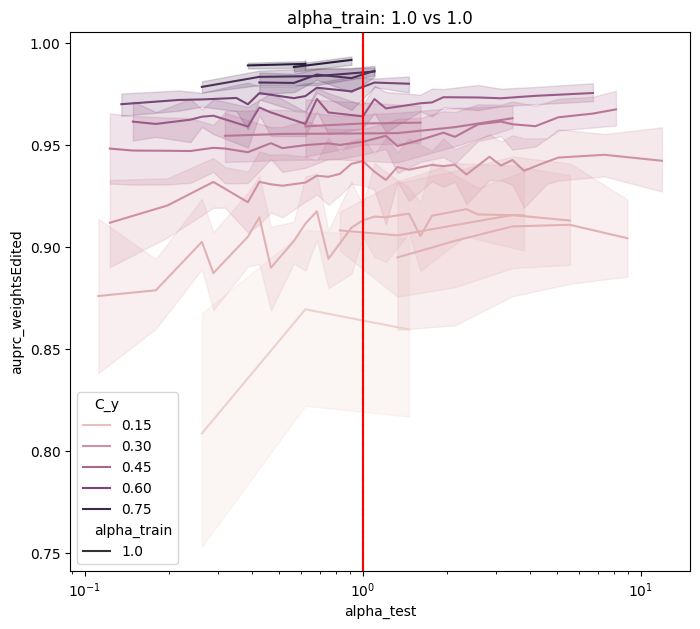

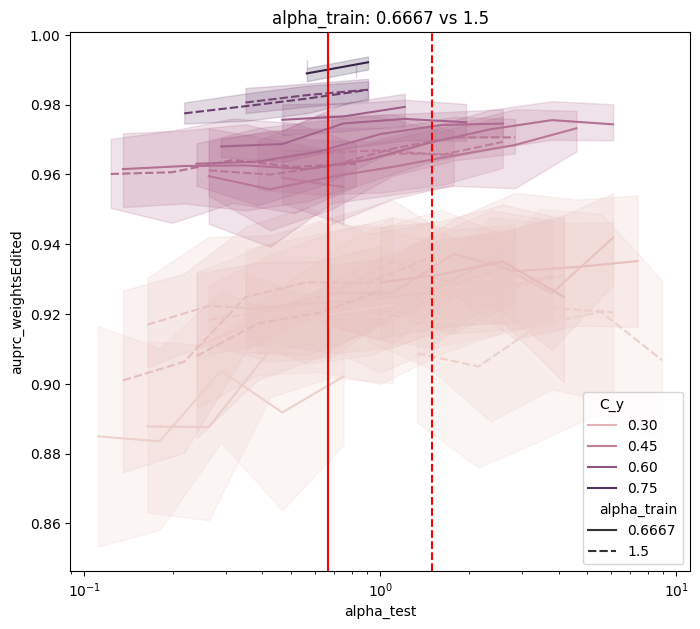

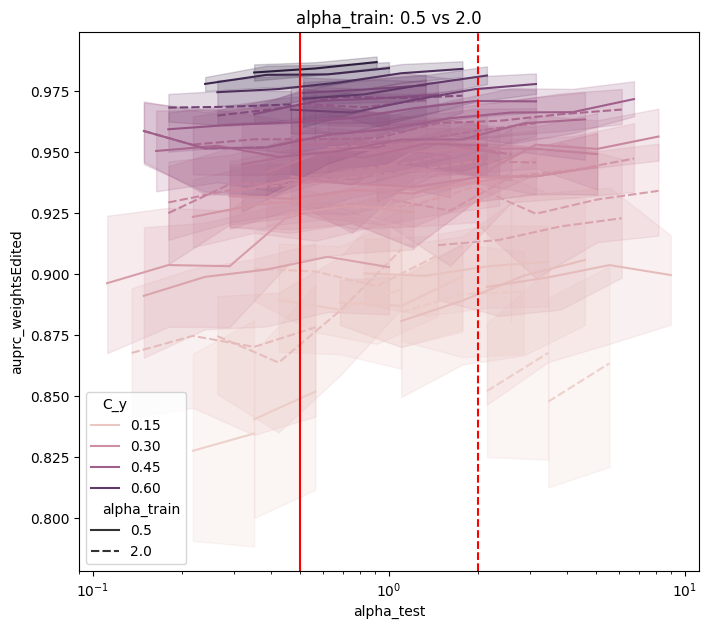

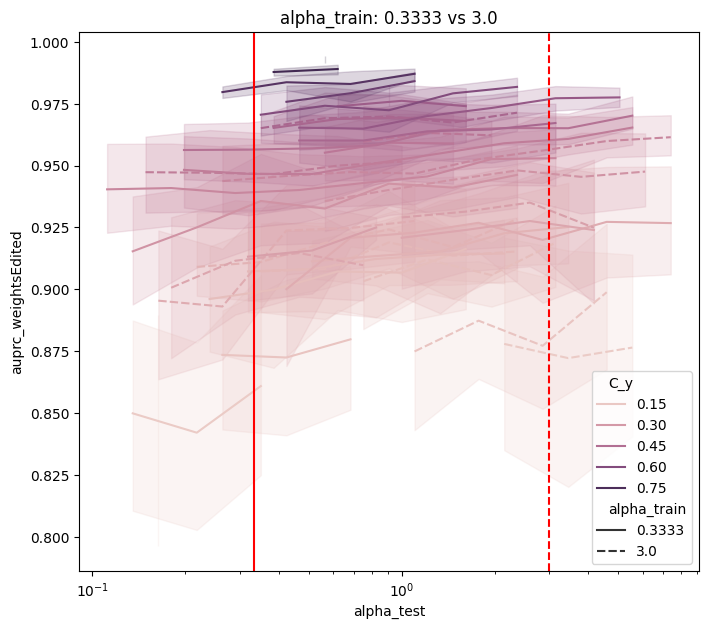

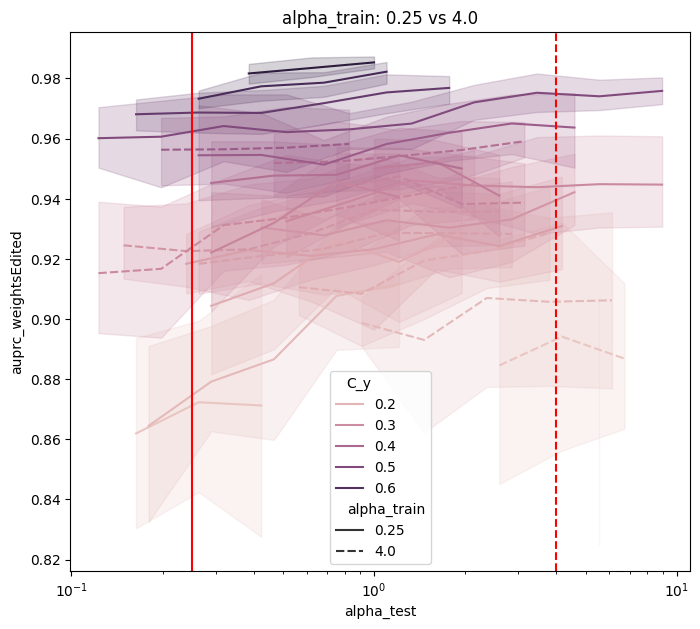

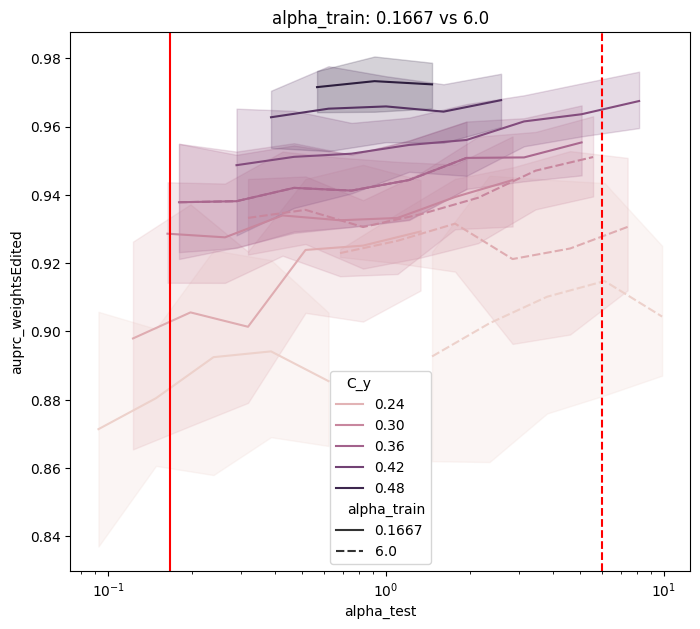

In [14]:
_df = df.copy()
_df['alpha_train'] = _df['alpha_train'].round(4)

# y_name = 'auprc_lora'
y_name = "auprc_weightsEdited"
# _df = _df.query("C_y.isin([0.16, 0.3, 0.5, 0.75, 0.8])")

n_cols = 1

for alpha_train in sorted(set(_df['alpha_train'])):
    if alpha_train >= 1 :
        reciprocal = round(1 / alpha_train, 4)
        fig, ax = plt.subplots(1,n_cols, figsize=(8,7))
        
        sns.lineplot(data=_df[(_df['alpha_train'] == alpha_train) | (_df['alpha_train'] == reciprocal) ],x='alpha_test',y=y_name, style='alpha_train', hue='C_y', ax=ax)

        for i in range(n_cols):
            ax.set_xscale('log')
            ax.axvline(alpha_train, color="red", linestyle='dashed')
            ax.axvline(reciprocal, color="red", linestyle='solid')
            ax.title.set_text("alpha_train: " + str(reciprocal) + " vs " + str(alpha_train))
            
        
        # plt.axvline(alpha_train,color='black')
        # plt.axvline(reciprocal, color='beige')
        # plt.title('alpha_train: ' + str(alpha_train))
        plt.show()

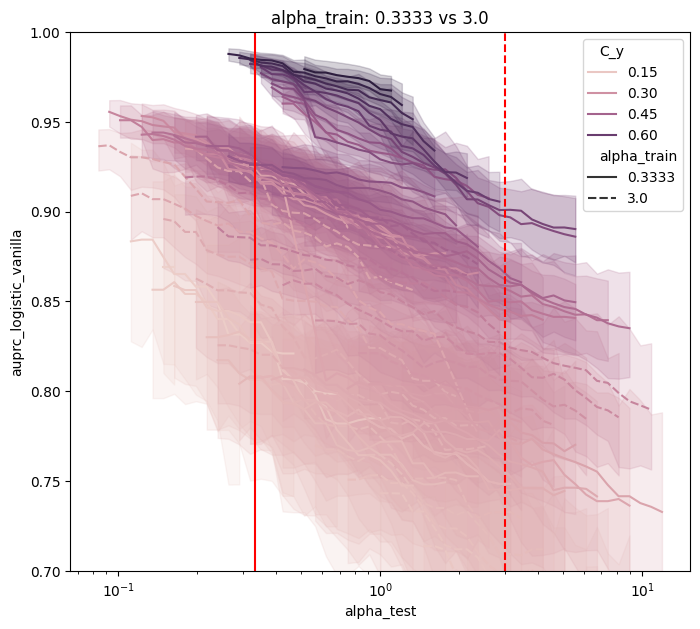

In [12]:
## Target for one setting...
_df = df.copy()
_df['alpha_train'] = _df['alpha_train'].round(4)

_df = _df.query("alpha_train.isin([3, 0.3333])")

# _df = _df.query("C_y.isin([0.17, 0.46,  0.75])")
# _df["C_y_cut"] = pd.cut(_df["C_y"], bins=np.arange(0,1.1,0.1), labels=np.arange(0,10,1)).astype("float")

n_cols = 1

for alpha_train in sorted(set(_df['alpha_train'])):
    
    if alpha_train >= 1 :
        reciprocal = round(1 / alpha_train, 4)
        fig, ax = plt.subplots(1,n_cols, figsize=(8,7))

        sns.lineplot(data=_df[(_df['alpha_train'] == alpha_train) | (_df['alpha_train'] == reciprocal) ],
                     x='alpha_test',
                     y='auprc_logistic_vanilla', 
                     style='alpha_train', 
                     hue='C_y',
                     # hue="C_y_cut",
                     ax=ax,
                    )

        for i in range(n_cols):
            ax.set_xscale('log')
            ax.axvline(alpha_train, color="red", linestyle='dashed')
            ax.axvline(reciprocal, color="red", linestyle='solid')
            ax.title.set_text("alpha_train: " + str(reciprocal) + " vs " + str(alpha_train))

            ax.set_ylim(0.7,1)
        plt.show()
plt.close()

In [22]:
_df['C_y'].unique()

array([0.27, 0.26, 0.25, 0.24, 0.23, 0.22, 0.21, 0.2 , 0.19, 0.18, 0.17,
       0.16, 0.15, 0.14, 0.13, 0.12, 0.56, 0.54, 0.52, 0.5 , 0.48, 0.46,
       0.44, 0.42, 0.4 , 0.38, 0.36, 0.34, 0.32, 0.3 , 0.28, 0.75, 0.72,
       0.69, 0.66, 0.63, 0.6 , 0.57, 0.51, 0.45])

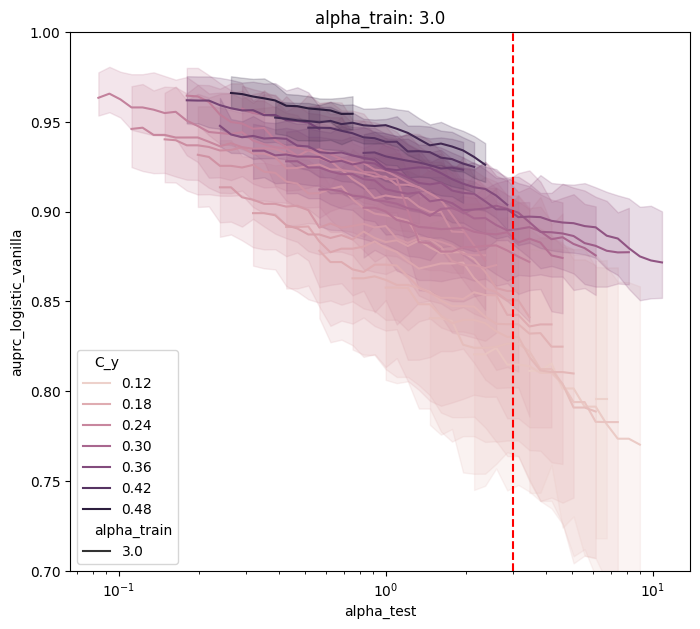

In [25]:
## Target for one setting...
## remove reciprocal

_df = df.copy()
_df['alpha_train'] = _df['alpha_train'].round(4)

_df['C_y'] = _df['C_y'].round(4)

_df = _df.query("alpha_train.isin([0.3333])")

# _df = _df.query("C_y.isin([ 0.2, 0.48, 0.72])")

# _df["C_y_cut"] = pd.cut(_df["C_y"], bins=np.arange(0,1.1,0.1), labels=np.arange(0,10,1)).astype("float")

n_cols = 1

for alpha_train in sorted(set(_df['alpha_train'])):
    

    
    fig, ax = plt.subplots(1,n_cols, figsize=(8,7))

    sns.lineplot(data=_df[(_df['alpha_train'] == alpha_train) ],
                 x='alpha_test',
                 y='auprc_logistic_vanilla', 
                 style='alpha_train', 
                 hue='C_y',
                 # hue="C_y_cut",
                 ax=ax,
                )

    for i in range(n_cols):
        ax.set_xscale('log')
        ax.axvline(alpha_train, color="red", linestyle='dashed')
        ax.title.set_text("alpha_train: " + str(alpha_train))

        ax.set_ylim(0.7,1)
    plt.show()
plt.close()

In [27]:
## Target for one setting...
## remove reciprocal
## SAVE!!! plot

_df = df.copy()
_df['alpha_train'] = _df['alpha_train'].round(4)

_df['C_y'] = _df['C_y'].round(4)

_df = _df.query("alpha_train.isin([0.3333])")

if dataset_name == 'hatespeech':
    _df = _df.query("C_y.isin([ 0.24, 0.54, 0.84])")
    ylim=0.5,1
    
    
    loc_legend = "best"
    loc_coef_x = -40
    loc_coef_y = -1 # order number from sorted ascending list
    xticks = [0.1, 0.5, 1,]
    
elif dataset_name == 'shac':
    _df = _df.query("C_y.isin([ 0.2, 0.48, 0.72])")
    ylim=0.6,1
    loc_legend = "best"
    loc_coef_x = -30
    loc_coef_y = -1 # order number from sorted ascending list
    xticks = [0.2, 0.5, 1,2,4]

palette = ["#648FFF", "#FFB000", "#DC267F"]


# _df["C_y_cut"] = pd.cut(_df["C_y"], bins=np.arange(0,1.1,0.1), labels=np.arange(0,10,1)).astype("float")

n_cols = 1

for alpha_train in sorted(set(_df['alpha_train'])):
    

    
    fig, ax = plt.subplots(1,n_cols, figsize=(5,4))

    sns.lineplot(data=_df[(_df['alpha_train'] == alpha_train) ],
                 x='alpha_test',
                 y='auprc_logistic_vanilla', 
                 hue='C_y',
                 palette=palette,
                 
                 style='C_y',
                 ax=ax,
                )
    
    
    for item, color in zip(_df.groupby('C_y'), palette):        
        for ylabel in ['auprc_logistic_vanilla']:
            x=sorted(item[1]['alpha_test'])[loc_coef_x]
            y=sorted(item[1][item[1]['alpha_test'] == x][ylabel])[loc_coef_y]
            
            coef = get_coef(x=list(item[1]['alpha_test']), y=list(item[1][ylabel]))

            ax.text(x, y, f"coef={coef:.3f}", color=color)
            ax.set_xscale('log')
            ax.axvline(alpha_train, color="red", linestyle='dashed')
            ax.set_ylim(ylim)
            
            ax.legend(loc=loc_legend, title=r'$C_y$')
            ax.xaxis.set_major_formatter(ScalarFormatter())
            ax.set_xticks(xticks)

            ax.title.set_text(r"$\alpha_{train}$ = " + str(alpha_train))
            ax.set_xlabel(r"$\alpha_{test}$")
            ax.set_ylabel("AUPRC")
        

        
plt.show()    
# plt.savefig(f"{fname}.png", dpi=600)
plt.close()

In [10]:
_df = df.copy()
_df['alpha_train'] = _df['alpha_train'].round(4)

_df = _df.query("alpha_train.isin([0.3333])")

In [11]:
list(sorted(_df.C_y.unique()))

[0.28, 0.36, 0.44, 0.52]

In [ ]:
fname

'../output/regressionHateSpeechBalanceAlpha/Sentence-BERT_ntest_1000_l2_C1_V10'

In [36]:
list(df.query("(alpha_train==1)")['C_y'].unique())

[0.20000000000000004,
 0.2,
 0.4000000000000001,
 0.4,
 0.5,
 0.6,
 0.8000000000000002,
 0.9000000000000001]

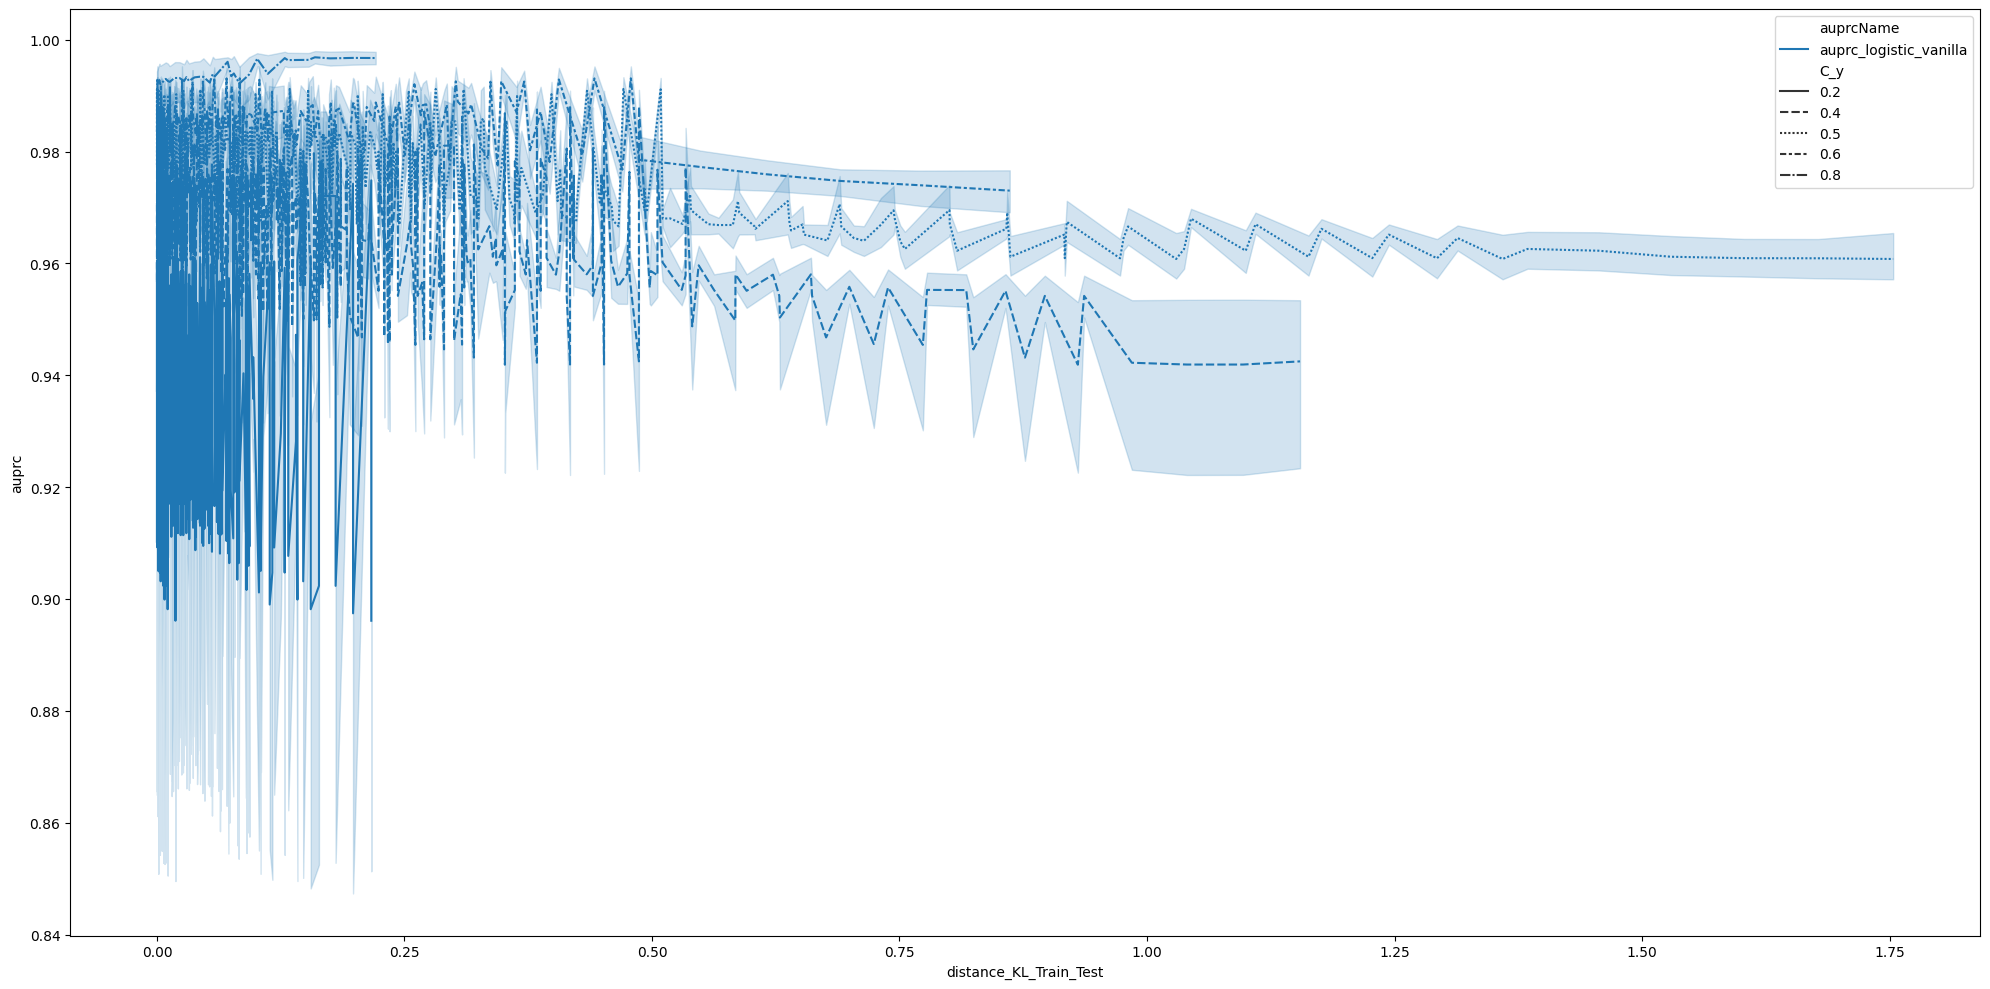

In [29]:
# better version for save
xlabel = "distance_KL_Train_Test"

p_mix_z1 = df['p_mix_z1'].unique()
# p_mix_z1 = [0.2,0.3,0.5,]

fig, ax = plt.subplots(1, 1, figsize=(20,10), sharey=True)

_df = df.sort_values(xlabel).copy().reset_index(drop=True)

_df['C_y'] = _df['C_y'].round(4)
_df = _df.query("C_y.isin([0.2,0.4,0.5,0.6,0.8,0.9])")

# names_auprc = ['auprc_logistic_vanilla', 'auprc_logistic_confounder']
names_auprc = ['auprc_logistic_vanilla']

_df = _df.melt(id_vars = [xlabel, "C_y"], value_vars=names_auprc, var_name="auprcName", value_name="auprc")


g_results=sns.lineplot(data=_df, x=xlabel, y='auprc', ax=ax, hue="auprcName", style="C_y")

# g_results=sns.lineplot(data=_df, x=xlabel, y='auprc_logistic_confounder', ax=ax, label="BA", style="C_y")
# g_results=sns.lineplot(data=_df, x=xlabel, y='auprc_logistic_vanilla', ax=ax, label="vanilla", style="C_y")
# g_results.set(xscale="log")

# ax.set_title(f"$P(z=1)$ = {round(k,3)}")
ax.legend()
# ax.set(xlabel=r"$\alpha_{test}$", ylabel="AUPRC")
# sample_count = np.around(np.around(np.logspace(math.log10(min(_df[xlabel])),math.log10(max(_df[xlabel])),6)/0.05,decimals=0)*0.05, decimals=2)
# g_results.set(xticks=sample_count)
# g_results.set(xticklabels=sample_count)

plt.tight_layout()


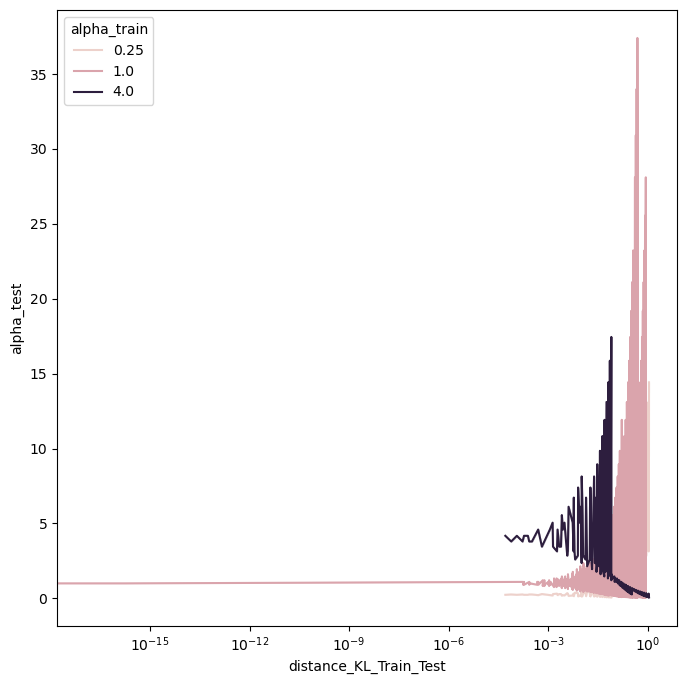

In [37]:
_df = df.copy()
_df = _df.query("alpha_train.isin([1,4, 0.25])").reset_index(drop=True)


fig, ax = plt.subplots(1,1, figsize=(8,8))

# sns.lineplot(data = _df, x='alpha_test', y='distance_KL_Train_Test', ax=ax, hue="alpha_train")
sns.lineplot(data = _df, y='alpha_test', x='distance_KL_Train_Test', ax=ax, hue="alpha_train")

ax.set_xscale("log")

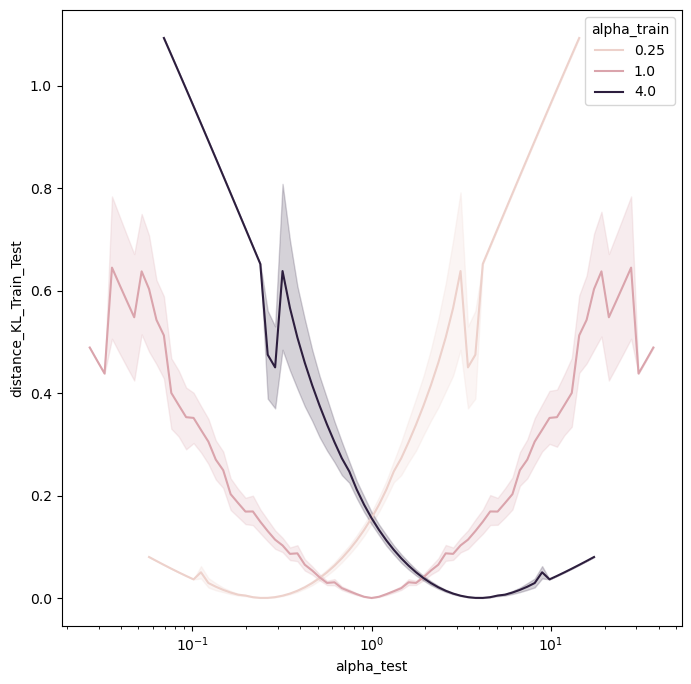

In [38]:
_df = df.copy()
_df = _df.query("alpha_train.isin([1,4, 0.25])").reset_index(drop=True)


fig, ax = plt.subplots(1,1, figsize=(8,8))

sns.lineplot(data = _df, x='alpha_test', y='distance_KL_Train_Test', ax=ax, hue="alpha_train")

ax.set_xscale("log")

In [23]:
fname

'../output/regressionSHACBalanceAlpha/Sentence-BERT_0.5_0.2_500_l2_C1_V10'

In [25]:
######  Saving
# better version for save
# regular x scale

xlabel = "alpha_test"

p_mix_z1 = df['p_mix_z1'].unique()[1:-1]
# p_mix_z1 = df['p_mix_z1'].unique()[1:4]
p_mix_z1 = [0.3,0.5,0.6]

fig, ax = plt.subplots(math.ceil(len(p_mix_z1)/3),3, figsize=(15,4))
ax = ax.ravel()
for idx, k in enumerate(p_mix_z1):
    _df = df[df['p_mix_z1'].round(2) == k].sort_values(xlabel)
    
    g_results=sns.lineplot(data=_df, x=xlabel, y='auprc_logistic_confounder', ax=ax[idx], label="BA")
    g_results=sns.lineplot(data=_df, x=xlabel, y='auprc_logistic_vanilla', ax=ax[idx], label="vanilla", linestyle='dotted')
    # g_results.set(xscale="log")
    
    ax[idx].axvline(_df['alpha_train'].unique(), color="red", linestyle="--")
    ax[idx].set_title(f"$P(z=1)$ = {round(k,3)}")
    ax[idx].legend()
    ax[idx].set(xlabel=r"$\alpha_{test}$", ylabel="AUPRC")


plt.tight_layout()

plt.savefig(f"{fname}.png", dpi=400)
plt.close()

In [25]:
######  Saving
# better version for save
# log scale of x


xlabel = "alpha_test"

p_mix_z1 = df['p_mix_z1'].unique()[1:-1]
# p_mix_z1 = df['p_mix_z1'].unique()[1:4]
p_mix_z1 = [0.3,0.5,0.6]

fig, ax = plt.subplots(math.ceil(len(p_mix_z1)/3),3, figsize=(15,4), sharey=True)
ax = ax.ravel()
for idx, k in enumerate(p_mix_z1):
    _df = df[df['p_mix_z1'].round(2) == k].sort_values(xlabel)
    
    g_results=sns.lineplot(data=_df, x=xlabel, y='auprc_logistic_confounder', ax=ax[idx], label="BA")
    g_results=sns.lineplot(data=_df, x=xlabel, y='auprc_logistic_vanilla', ax=ax[idx], label="vanilla", linestyle='dotted')
    g_results.set(xscale="log")
    
    ax[idx].axvline(_df['alpha_train'].unique(), color="red", linestyle="--")
    ax[idx].set_title(f"$P(z=1)$ = {round(k,3)}", fontsize=16)
    ax[idx].legend()
    ax[idx].set(xlabel=r"$\alpha_{test}$", ylabel="AUPRC")
    ax[idx].set_xlabel(r"$\alpha_{test}$", fontsize=16)
    ax[idx].set_ylabel("AUPRC", fontsize=16)
    
    sample_count = np.around(np.around(np.logspace(math.log10(min(_df[xlabel])),math.log10(max(_df[xlabel])),6)/0.05,decimals=0)*0.05, decimals=2)
    g_results.set(xticks=sample_count)
    g_results.set(xticklabels=sample_count)
    
    # ylabels = ['{:,.2f}'.format(x) for x in ax[idx].get_yticks()]
    # ax[idx].set_yticklabels(ylabels)
    
    # for SentenceBERT
    # ax[idx].set_ylim(0.81,0.95)
    
    ax[idx].xaxis.set_tick_params(labelsize=14)
    ax[idx].yaxis.set_tick_params(labelsize=14)

plt.tight_layout()

plt.savefig(f"{fname}_logScale.png", dpi=400)
plt.close()

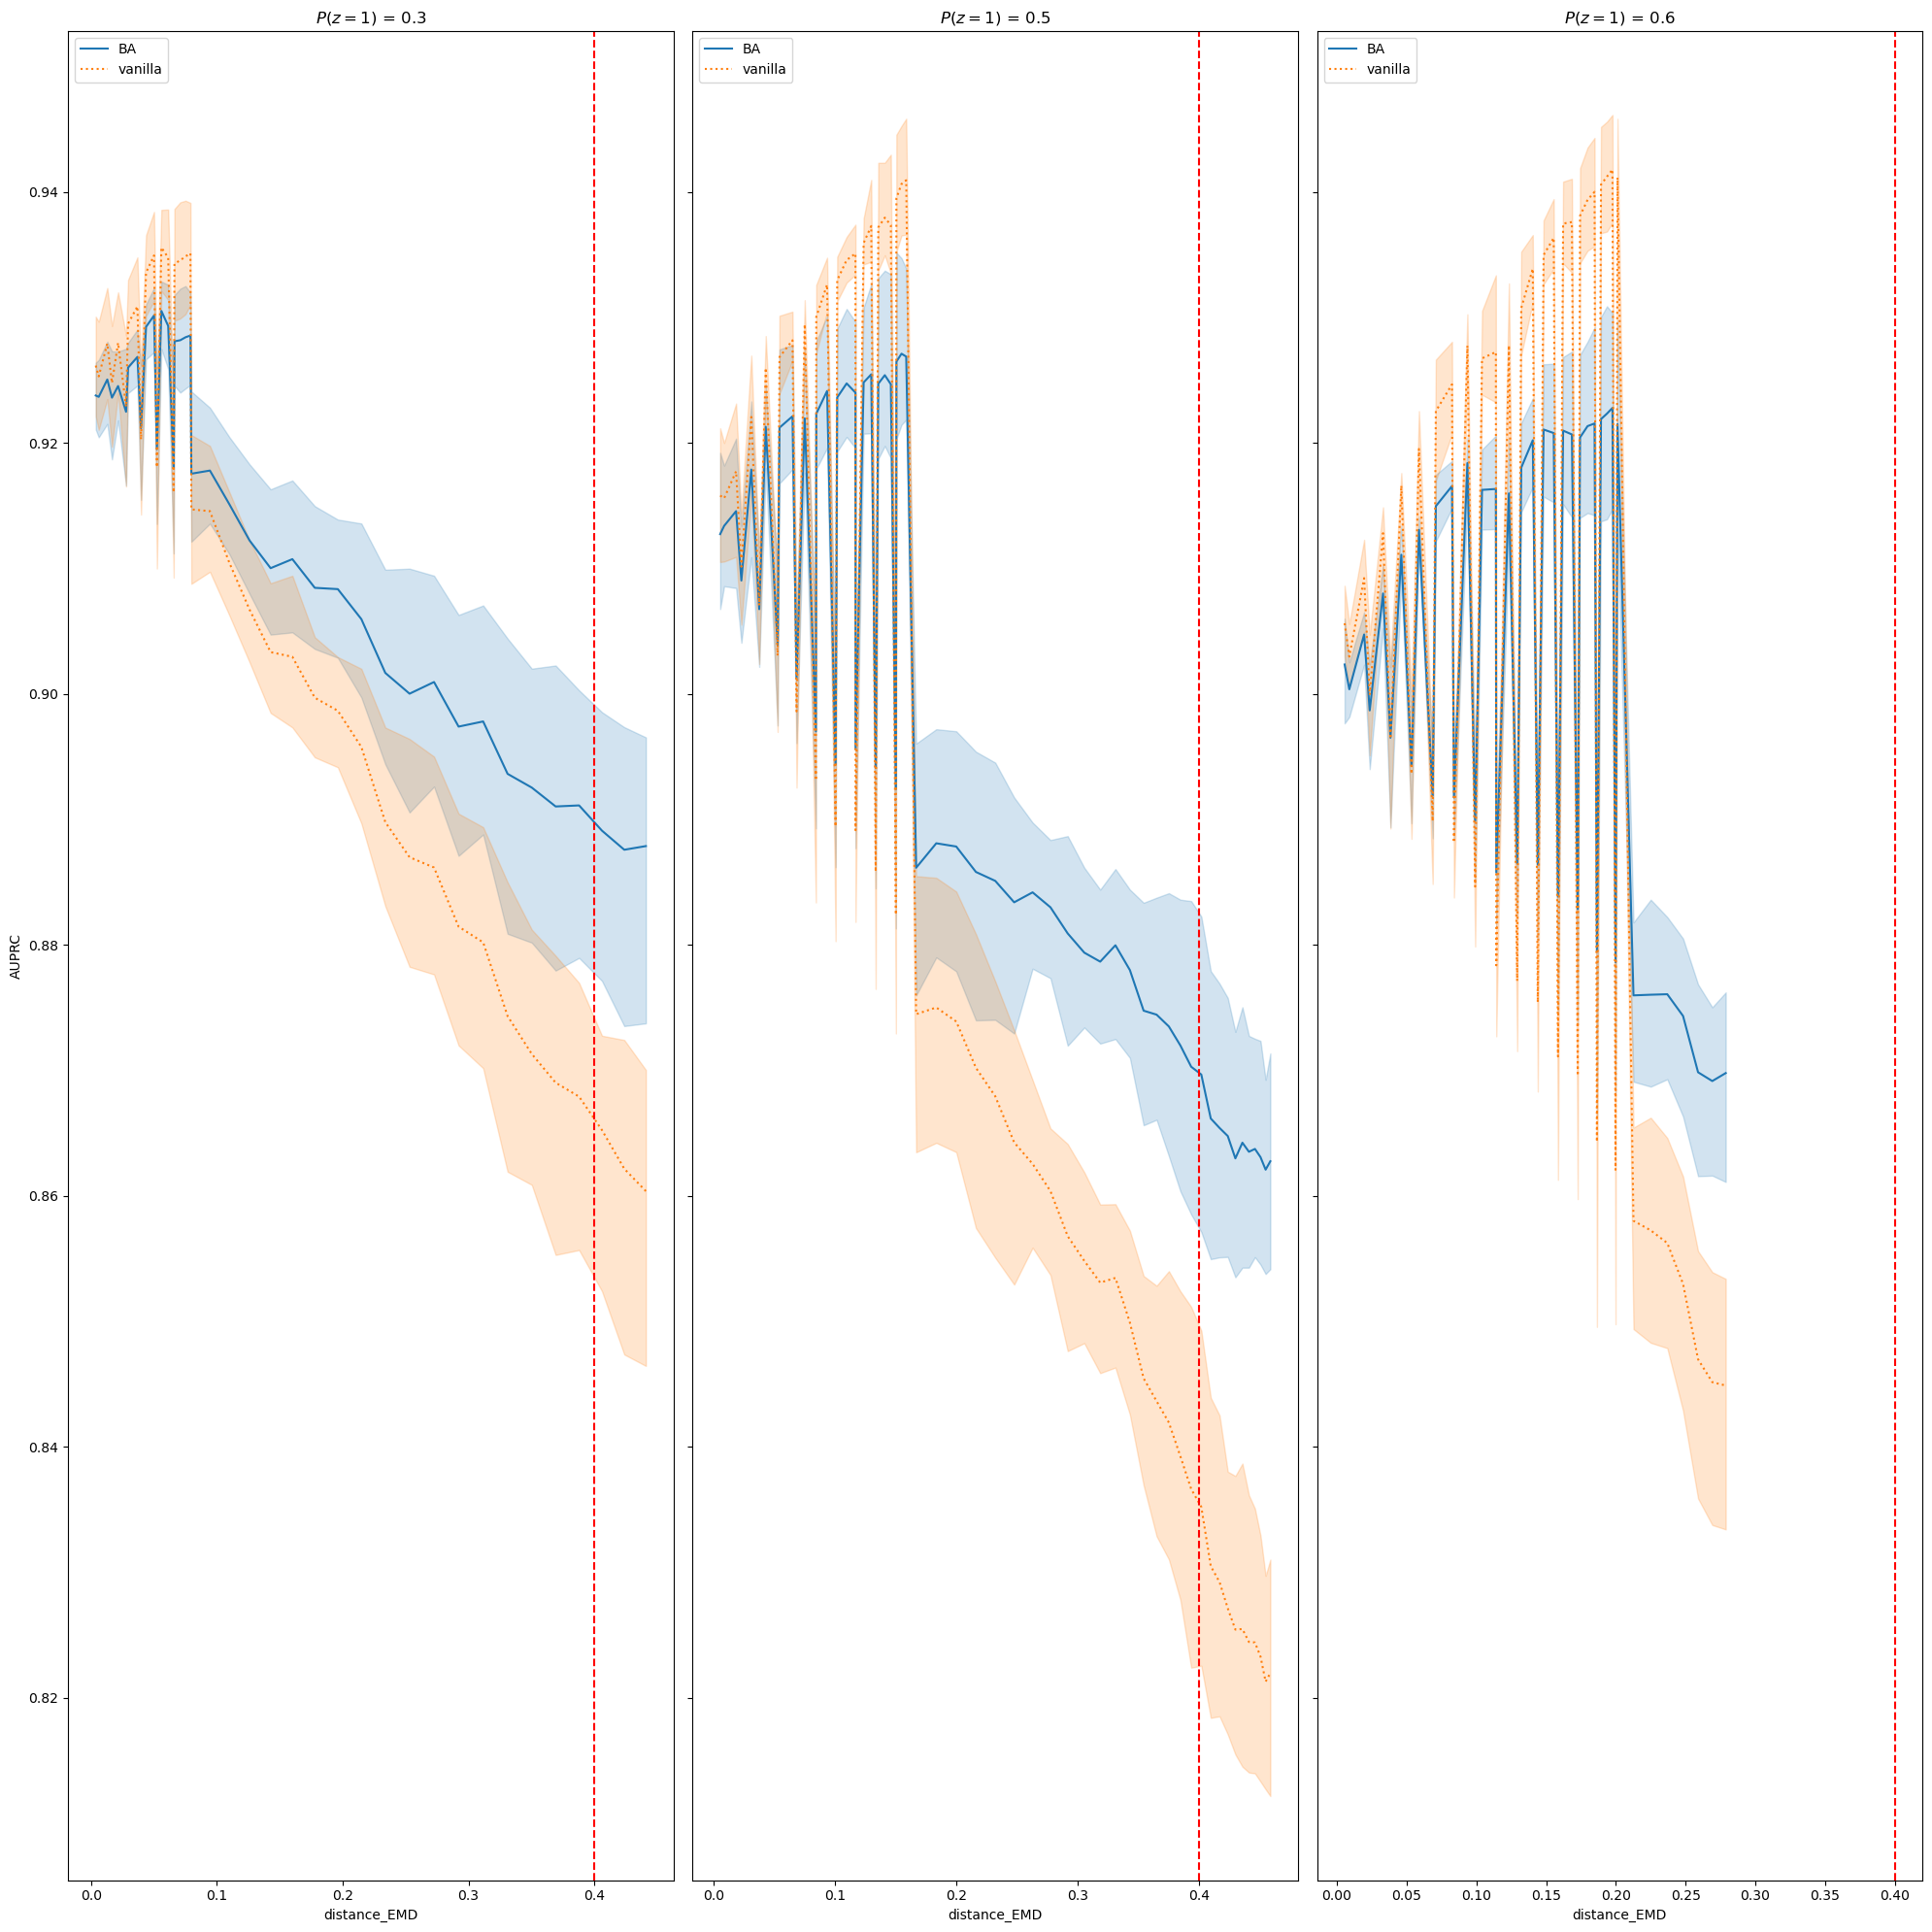

In [26]:
# better version for save
# xlabel = "alpha_test"
xlabel = "distance_EMD"
# xlabel = "distance_KL_Train_Test"

p_mix_z1 = df['p_mix_z1'].unique()
# p_mix_z1 = [0.2,0.3,0.5,]

fig, ax = plt.subplots(math.ceil(len(p_mix_z1)/3),3, figsize=(20,20), sharey=True)
ax = ax.ravel()
for idx, k in enumerate(p_mix_z1):
    _df = df[df['p_mix_z1'] == k].sort_values(xlabel)
    
    g_results=sns.lineplot(data=_df, x=xlabel, y='auprc_logistic_confounder', ax=ax[idx], label="BA")
    g_results=sns.lineplot(data=_df, x=xlabel, y='auprc_logistic_vanilla', ax=ax[idx], label="vanilla", linestyle='dotted')
    # g_results.set(xscale="log")
    
    ax[idx].axvline(_df['alpha_train'].unique(), color="red", linestyle="--")
    ax[idx].set_title(f"$P(z=1)$ = {round(k,3)}")
    ax[idx].legend()
    ax[idx].set(xlabel=f"{xlabel}", ylabel="AUPRC")
    # sample_count = np.around(np.around(np.logspace(math.log10(min(_df[xlabel])),math.log10(max(_df[xlabel])),6)/0.05,decimals=0)*0.05, decimals=2)
    # g_results.set(xticks=sample_count)
    # g_results.set(xticklabels=sample_count)

plt.tight_layout()


In [ ]:
xlabel = "alpha_test"

p_mix_z1 = df['p_mix_z1'].unique()

fig, ax = plt.subplots(math.ceil(len(p_mix_z1)/3),3, figsize=(20,20))
ax = ax.ravel()
for idx, k in enumerate(p_mix_z1):
    _df = df[df['p_mix_z1'] == k].sort_values("alpha_test")
    
    sns.lineplot(data=_df, x=xlabel, y='auprc_logistic_confounder_df0', ax=ax[idx], label="confounder-df0", alpha=0.6)
    sns.lineplot(data=_df, x=xlabel, y='auprc_logistic_confounder_df1', ax=ax[idx], label="confounder-df1", alpha=0.6)
    sns.lineplot(data=_df, x=xlabel, y='auprc_logistic_vanilla_df0', ax=ax[idx], label="vanilla-df0", alpha=0.6,linestyle='dashed')
    sns.lineplot(data=_df, x=xlabel, y='auprc_logistic_vanilla_df1', ax=ax[idx], label="vanilla-df1", alpha=0.6,linestyle='dashed')
    # ax[idx].plot(_df['alpha_test'], _df['auprc_logistic_confounder'], label="confounder")
    # ax[idx].plot(_df['alpha_test'], _df['auprc_logistic_vanilla'], label="vanilla")
    
    ax[idx].axvline(_df['alpha_train'].unique(), color="red", linestyle="--")
    ax[idx].set_title(f"p_mix_z1 = {round(k,3)}")
    ax[idx].legend()
plt.tight_layout()

In [ ]:
xlabel = "distance_EMD"

p_mix_z1 = df['p_mix_z1'].unique()

fig, ax = plt.subplots(math.ceil(len(p_mix_z1)/3),3, figsize=(20,20))
ax = ax.ravel()
for idx, k in enumerate(p_mix_z1):
    _df = df[df['p_mix_z1'] == k].sort_values(xlabel)
    
    sns.lineplot(data=_df, x=xlabel, y='auprc_logistic_confounder_df0', ax=ax[idx], label="confounder-df0", alpha=0.6)
    sns.lineplot(data=_df, x=xlabel, y='auprc_logistic_confounder_df1', ax=ax[idx], label="confounder-df1", alpha=0.6)
    sns.lineplot(data=_df, x=xlabel, y='auprc_logistic_vanilla_df0', ax=ax[idx], label="vanilla-df0", alpha=0.6,linestyle='dashed')
    sns.lineplot(data=_df, x=xlabel, y='auprc_logistic_vanilla_df1', ax=ax[idx], label="vanilla-df1", alpha=0.6,linestyle='dashed')
    # ax[idx].plot(_df['alpha_test'], _df['auprc_logistic_confounder'], label="confounder")
    # ax[idx].plot(_df['alpha_test'], _df['auprc_logistic_vanilla'], label="vanilla")
    
    ax[idx].axvline(_df['alpha_train'].unique(), color="red", linestyle="--")
    ax[idx].set_title(f"p_mix_z1 = {round(k,3)}")
    ax[idx].legend()
plt.tight_layout()

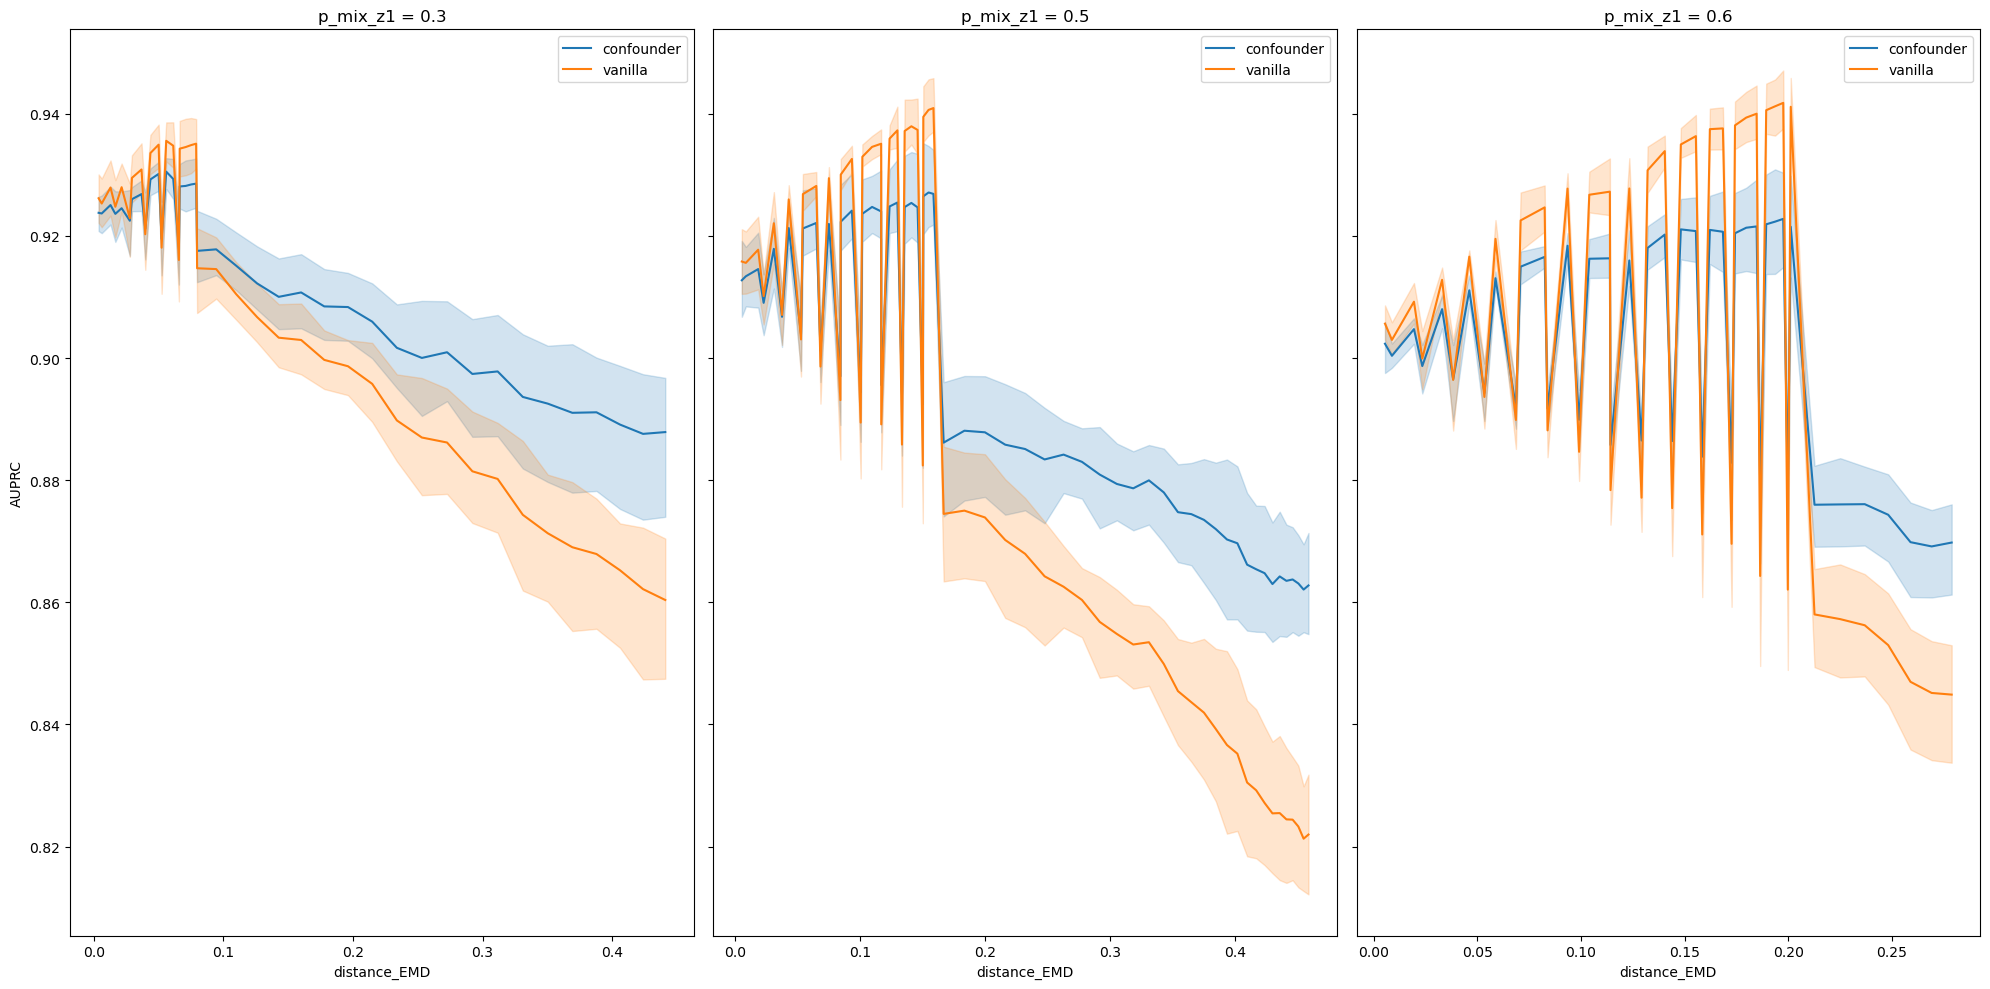

In [34]:
xlabel = "distance_EMD"

p_mix_z1 = df['p_mix_z1'].unique()

fig, ax = plt.subplots(math.ceil(len(p_mix_z1)/3),3, figsize=(20,10), sharey=True)
ax = ax.ravel()
for idx, k in enumerate(p_mix_z1):
    
    _df = df[df['p_mix_z1'] == k].sort_values(xlabel)
    sns.lineplot(data=_df, x=xlabel, y='auprc_logistic_confounder', ax=ax[idx], label="confounder")
    sns.lineplot(data=_df, x=xlabel, y='auprc_logistic_vanilla', ax=ax[idx], label="vanilla")
    
    ax[idx].set_xlabel(xlabel)
    ax[idx].set_ylabel("AUPRC")
    # ax[idx].axvline(_df['alpha_train'].unique(), color="red", linestyle="--")
    ax[idx].set_title(f"p_mix_z1 = {round(k,3)}")
    ax[idx].legend()

plt.tight_layout()

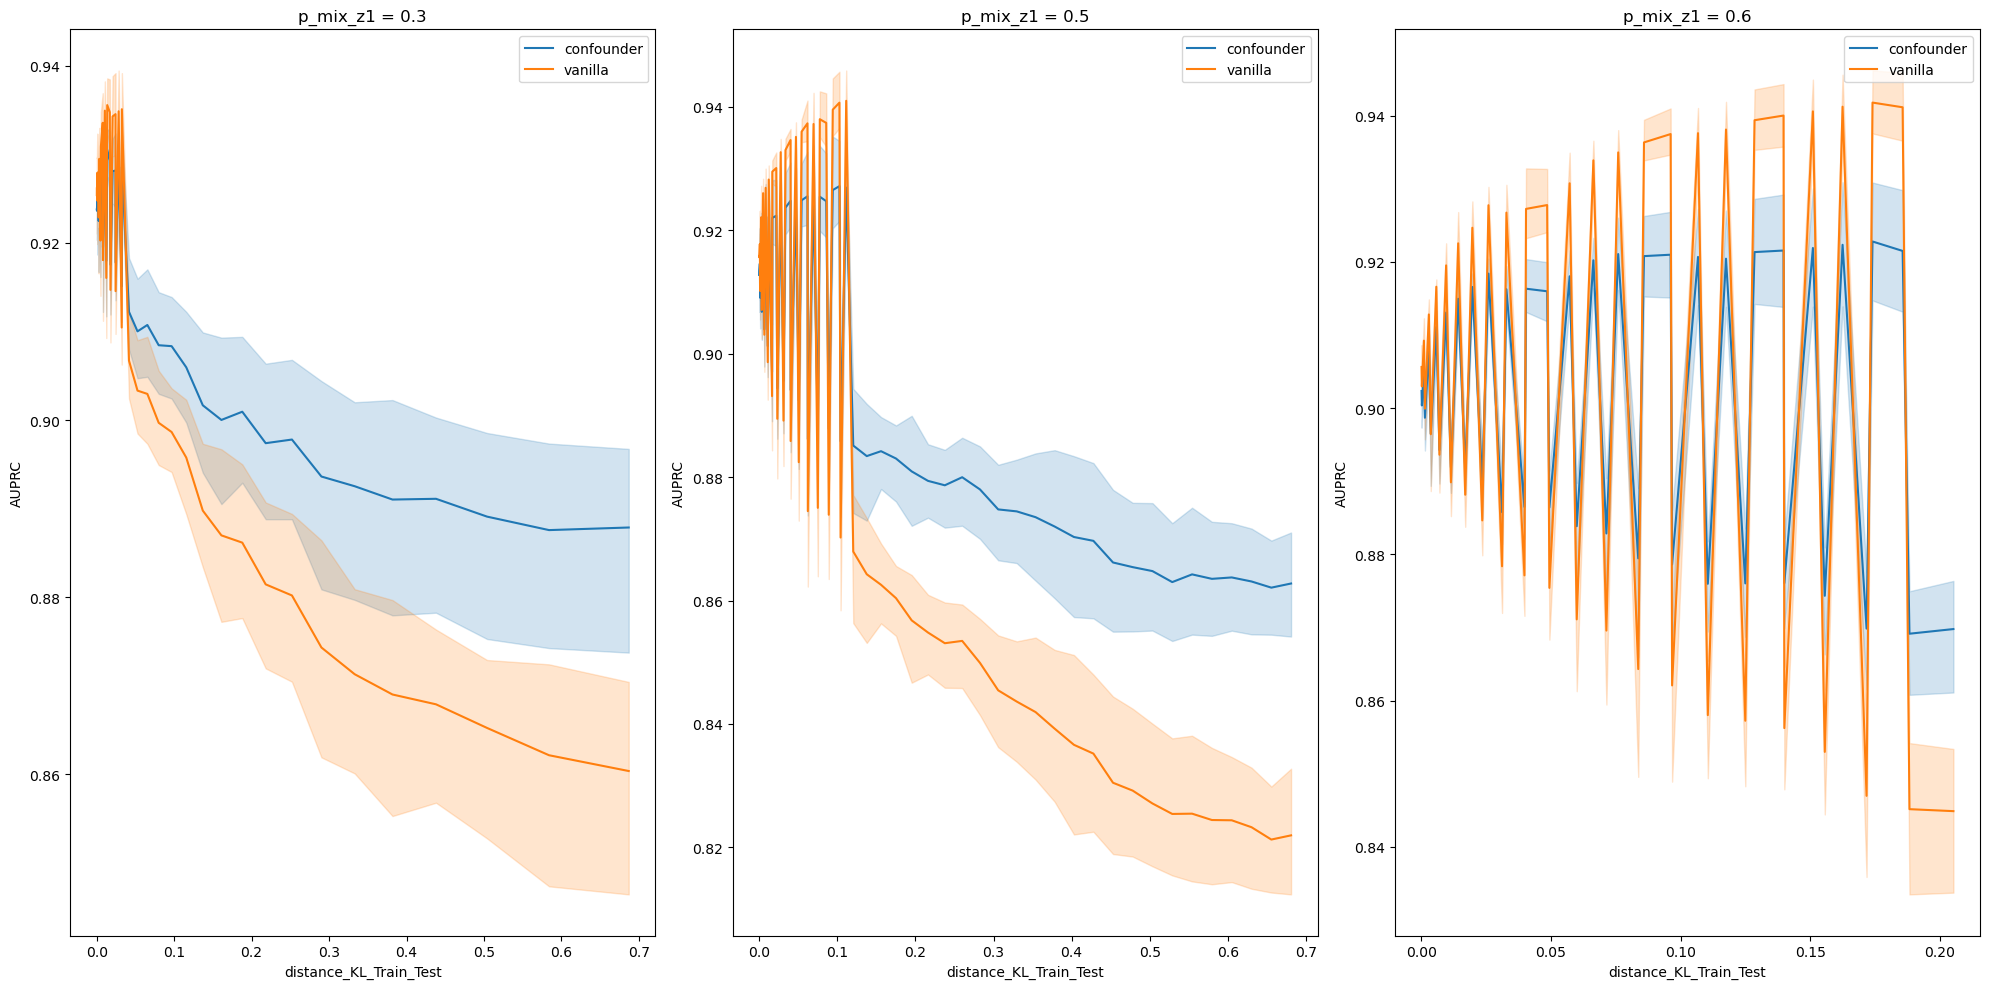

In [35]:
xlabel = "distance_KL_Train_Test"

p_mix_z1 = df['p_mix_z1'].unique()

fig, ax = plt.subplots(math.ceil(len(p_mix_z1)/3),3, figsize=(20,10))
ax = ax.ravel()
for idx, k in enumerate(p_mix_z1):
    
    _df = df[df['p_mix_z1'] == k].sort_values(xlabel)
    sns.lineplot(data=_df, x=xlabel, y='auprc_logistic_confounder', ax=ax[idx], label="confounder")
    sns.lineplot(data=_df, x=xlabel, y='auprc_logistic_vanilla', ax=ax[idx], label="vanilla")
    
    ax[idx].set_xlabel(xlabel)
    ax[idx].set_ylabel("AUPRC")
    # ax[idx].axvline(_df['alpha_train'].unique(), color="red", linestyle="--")
    ax[idx].set_title(f"p_mix_z1 = {round(k,3)}")
    ax[idx].legend()

plt.tight_layout()

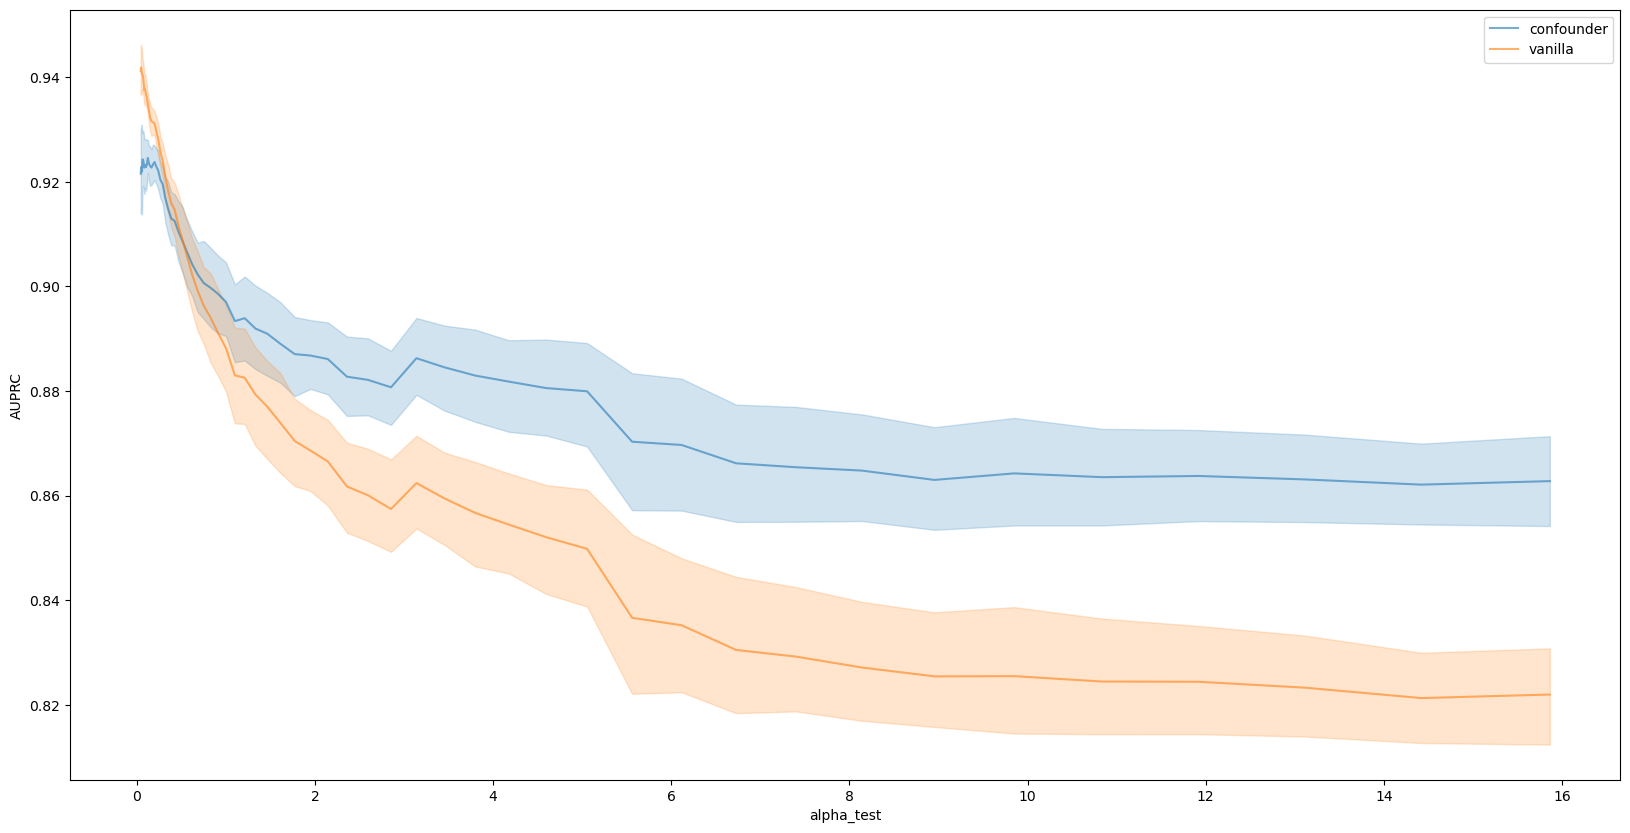

In [30]:
# xlabel = "distance_KL_Train_Test"
xlabel="alpha_test"

p_mix_z1 = df['p_mix_z1'].unique()

fig, ax = plt.subplots(1,1, figsize=(20,10))


_df = df.sort_values(xlabel)

sns.lineplot(data=_df, x=xlabel, y='auprc_logistic_confounder', label="confounder", alpha=0.6)
sns.lineplot(data=_df, x=xlabel, y='auprc_logistic_vanilla', label="vanilla", alpha=0.6)

# ax.plot(_df[xlabel], _df['auprc_logistic_confounder'], label="confounder", alpha=0.6)
# ax.plot(_df[xlabel], _df['auprc_logistic_vanilla'], label="vanilla", alpha=0.6)

ax.set_xlabel(xlabel)
ax.set_ylabel("AUPRC")
# ax[idx].axvline(_df['alpha_train'].unique(), color="red", linestyle="--")
ax.legend()


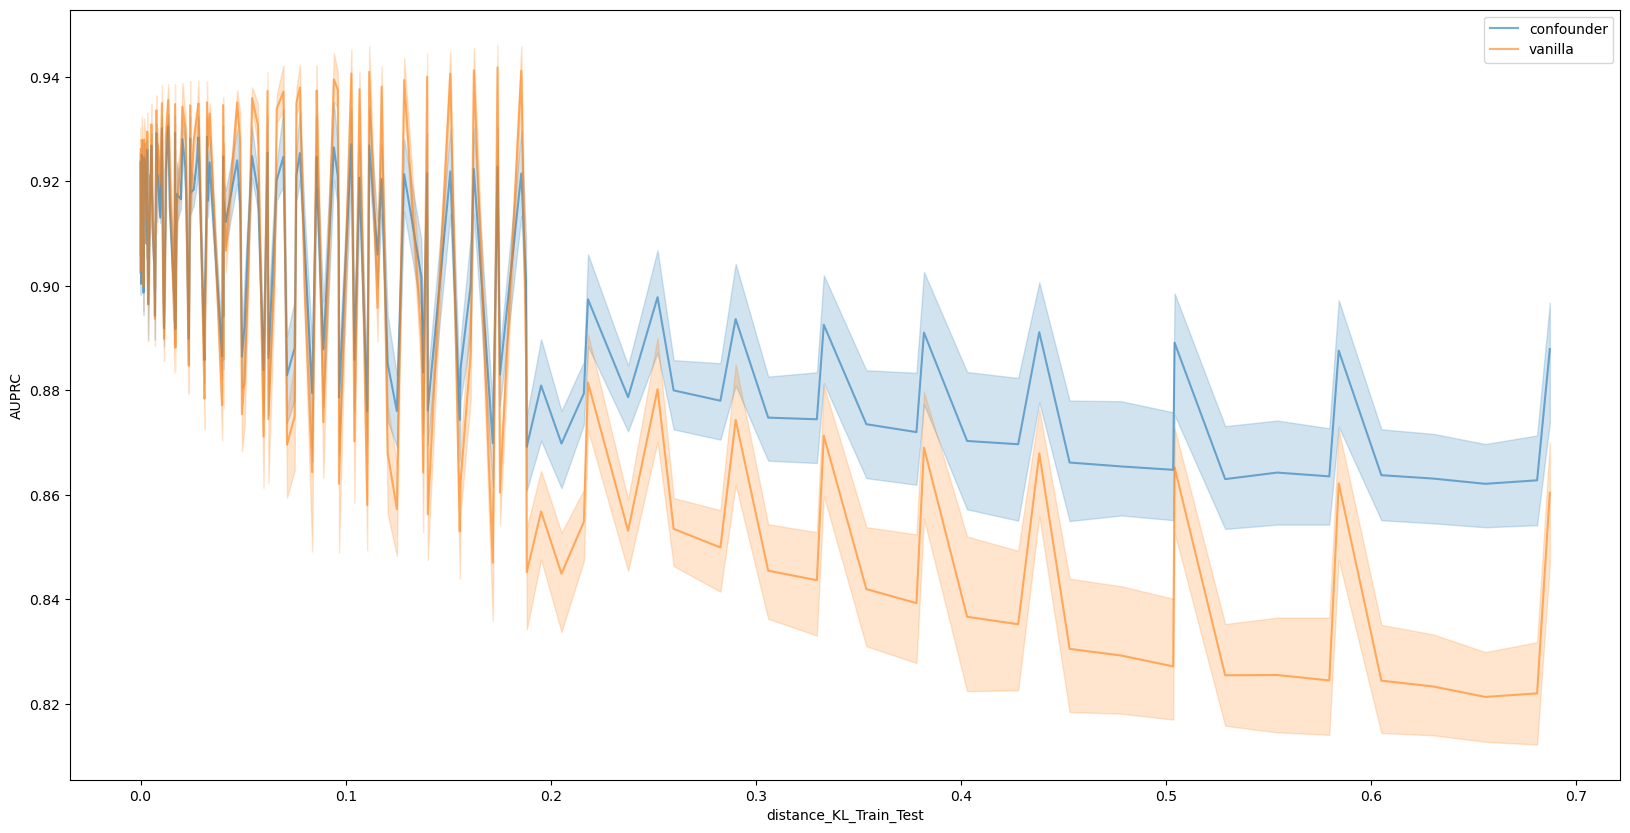

In [31]:
xlabel = "distance_KL_Train_Test"
# xlabel="alpha_test"

p_mix_z1 = df['p_mix_z1'].unique()

fig, ax = plt.subplots(1,1, figsize=(20,10))


_df = df.sort_values(xlabel)

sns.lineplot(data=_df, x=xlabel, y='auprc_logistic_confounder', label="confounder", alpha=0.6)
sns.lineplot(data=_df, x=xlabel, y='auprc_logistic_vanilla', label="vanilla", alpha=0.6)

# ax.plot(_df[xlabel], _df['auprc_logistic_confounder'], label="confounder", alpha=0.6)
# ax.plot(_df[xlabel], _df['auprc_logistic_vanilla'], label="vanilla", alpha=0.6)

ax.set_xlabel(xlabel)
ax.set_ylabel("AUPRC")
# ax[idx].axvline(_df['alpha_train'].unique(), color="red", linestyle="--")
ax.legend()


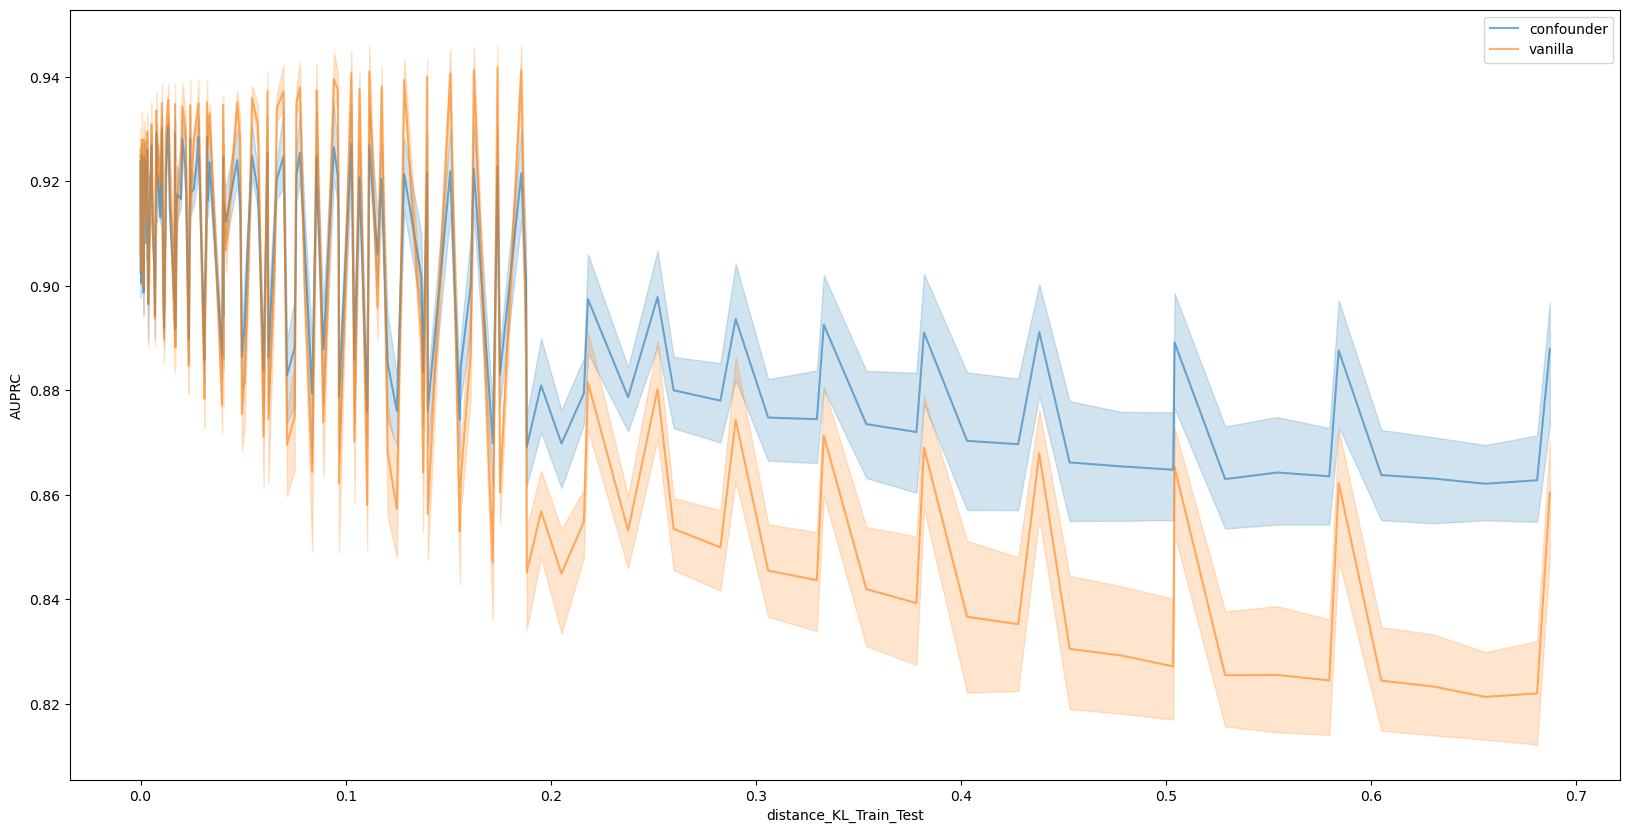

In [32]:
xlabel = "distance_KL_Train_Test"
# xlabel="alpha_test"

p_mix_z1 = df['p_mix_z1'].unique()

fig, ax = plt.subplots(1,1, figsize=(20,10))


_df = df.sort_values(xlabel)

sns.lineplot(data=_df, x=xlabel, y='auprc_logistic_confounder', label="confounder", alpha=0.6)
sns.lineplot(data=_df, x=xlabel, y='auprc_logistic_vanilla', label="vanilla", alpha=0.6)

# ax.plot(_df[xlabel], _df['auprc_logistic_confounder'], label="confounder", alpha=0.6)
# ax.plot(_df[xlabel], _df['auprc_logistic_vanilla'], label="vanilla", alpha=0.6)

ax.set_xlabel(xlabel)
ax.set_ylabel("AUPRC")
# ax[idx].axvline(_df['alpha_train'].unique(), color="red", linestyle="--")
ax.legend()


## Scatter Plot

In [ ]:

fig, ax = plt.subplots(1,2, figsize=(28,10))
xlabel = "distance_KL_Test_Train"
_df = df.sort_values(xlabel)

for idx, k in enumerate(["auprc_logistic_vanilla", "auprc_logistic_confounder"]):
    
    im = ax[idx].scatter(_df["p_pos_test_z0"], _df["p_pos_test_z1"], c=_df[k], cmap='Blues')
    im.set_clim(0.8,1)
    ax[idx].set_xlabel("p_pos_test_z0")
    ax[idx].set_ylabel("p_pos_test_z1")
    ax[idx].set_title(k)

    fig.colorbar(im, ax=ax[idx])

In [57]:
pd.options.display.max_columns = None

In [85]:

df[(df['p_pos_test_z0'].round(3)==0.3)
    & (df['p_pos_test_z1'].round(2)==0.3) 
    & (df['run']==0) 
    # & (df['p_mix_z1'].round(3)==0.4)
   ]


,auprc_logistic_confounder,auprc_logistic_vanilla,auprc_logistic_confounder_df0,auprc_logistic_confounder_df1,precision_confounder,recall_confounder,f1_confounder,precision_confounder_df0,recall_confounder_df0,f1_confounder_df0,precision_confounder_df1,recall_confounder_df1,f1_confounder_df1,auprc_logistic_vanilla_df0,auprc_logistic_vanilla_df1,precision_vanilla,recall_vanilla,f1_vanilla,precision_vanilla_df0,recall_vanilla_df0,f1_vanilla_df0,precision_vanilla_df1,recall_vanilla_df1,f1_vanilla_df1,p_pos_train_z0,p_pos_train_z1,p_pos_train,p_pos_test,p_mix_z0,p_mix_z1,alpha_train,alpha_test,p_pos_test_z0,p_pos_test_z1,C_y,C_z,n_train,n_test,n_z0_pos_train,n_z0_neg_train,n_z0_pos_test,n_z0_neg_test,n_z1_pos_train,n_z1_neg_train,n_z1_pos_test,n_z1_neg_test,run,distance_KL_Train_Test,distance_EMD
60,0.867849,0.867755,0.861276,0.906926,0.854701,0.666667,0.749064,0.840000,0.656250,0.736842,0.941176,0.727273,0.820513,0.861253,0.905603,0.854701,0.666667,0.749064,0.840000,0.656250,0.736842,0.941176,0.727273,0.820513,0.3,0.3,0.3,0.3,0.85,0.15,1.0,0.99,0.300451,0.297446,0.3,0.15,2000,500,510,1190,128,297,90,210,22,53,0,2.747741e-06,7.661492e-04
61,0.867849,0.867755,0.861276,0.906926,0.854701,0.666667,0.749064,0.840000,0.656250,0.736842,0.941176,0.727273,0.820513,0.861253,0.905603,0.854701,0.666667,0.749064,0.840000,0.656250,0.736842,0.941176,0.727273,0.820513,0.3,0.3,0.3,0.3,0.85,0.15,1.0,1.00,0.300000,0.300000,0.3,0.15,2000,500,510,1190,128,297,90,210,22,53,0,0.000000e+00,0.000000e+00
62,0.867122,0.867213,0.858849,0.910849,0.848739,0.673333,0.750929,0.831683,0.661417,0.736842,0.944444,0.739130,0.829268,0.858960,0.910849,0.854701,0.666667,0.749064,0.838384,0.653543,0.734513,0.944444,0.739130,0.829268,0.3,0.3,0.3,0.3,0.85,0.15,1.0,1.01,0.299551,0.302546,0.3,0.15,2000,500,510,1190,127,298,90,210,23,52,0,2.716775e-06,7.638542e-04
130,0.863668,0.863723,0.853187,0.921131,0.852174,0.653333,0.739623,0.831579,0.626984,0.714932,0.950000,0.791667,0.863636,0.853107,0.921131,0.852174,0.653333,0.739623,0.831579,0.626984,0.714932,0.950000,0.791667,0.863636,0.3,0.3,0.3,0.3,0.84,0.16,1.0,0.99,0.300481,0.297476,0.3,0.16,2000,500,504,1176,126,294,96,224,24,56,0,2.896800e-06,8.076923e-04
131,0.863668,0.863723,0.853187,0.921131,0.852174,0.653333,0.739623,0.831579,0.626984,0.714932,0.950000,0.791667,0.863636,0.853107,0.921131,0.852174,0.653333,0.739623,0.831579,0.626984,0.714932,0.950000,0.791667,0.863636,0.3,0.3,0.3,0.3,0.84,0.16,1.0,1.00,0.300000,0.300000,0.3,0.16,2000,500,504,1176,126,294,96,224,24,56,0,0.000000e+00,0.000000e+00
132,0.863668,0.863723,0.853187,0.921131,0.852174,0.653333,0.739623,0.831579,0.626984,0.714932,0.950000,0.791667,0.863636,0.853107,0.921131,0.852174,0.653333,0.739623,0.831579,0.626984,0.714932,0.950000,0.791667,0.863636,0.3,0.3,0.3,0.3,0.84,0.16,1.0,1.01,0.299521,0.302516,0.3,0.16,2000,500,504,1176,126,294,96,224,24,56,0,2.863445e-06,8.051118e-04
305,0.867023,0.866938,0.858140,0.915024,0.850877,0.646667,0.734848,0.838710,0.629032,0.718894,0.904762,0.730769,0.808511,0.858113,0.915317,0.850877,0.646667,0.734848,0.838710,0.629032,0.718894,0.904762,0.730769,0.808511,0.3,0.3,0.3,0.3,0.83,0.17,1.0,1.00,0.300000,0.300000,0.3,0.17,2000,500,498,1162,124,291,102,238,26,59,0,0.000000e+00,0.000000e+00
614,0.869627,0.869576,0.857532,0.926861,0.843478,0.646667,0.732075,0.827957,0.626016,0.712963,0.909091,0.740741,0.816327,0.857532,0.926861,0.843478,0.646667,0.732075,0.827957,0.626016,0.712963,0.909091,0.740741,0.816327,0.3,0.3,0.3,0.3,0.82,0.18,1.0,1.00,0.300000,0.300000,0.3,0.18,2000,500,492,1148,123,287,108,252,27,63,0,0.000000e+00,0.000000e+00
1085,0.864535,0.864442,0.857854,0.900793,0.850877,0.646667,0.734848,0.838710,0.639344,0.725581,0.904762,0.678571,0.775510,0.857564,0.900793,0.850877,0.646667,0.734848,0.838710,0.639344,0.725581,0.904762,0.678571,0.775510,0.3,0.3,0.3,0.3,0.81,0.19,1.0,1.00,0.300000,0.300000,0.3,0.19,2000,500,486,1134,122,283,114,266,28,67,0,0.000000e+00,0.000000e+00
1557,0.868348,0.868024,0.858790,0.905731,0.844828,0.65

<AxesSubplot:xlabel='p_pos_test_z0', ylabel='p_pos_test_z1'>

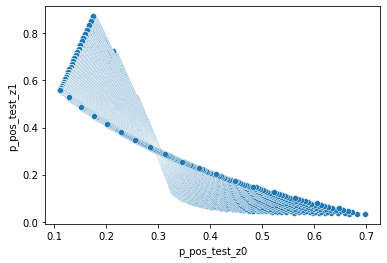

In [80]:
sns.scatterplot(x="p_pos_test_z0", y="p_pos_test_z1", data=df.query("(run==0)"))

In [632]:

auprc_vanilla_target = _df[(_df['p_pos_test_z0'].round(3)==0.5) 
                           & (_df['p_pos_test_z1'].round(2)==0.2) 
                           & (_df['p_mix_z1'].round(3)==0.4)
                           & (_df['run']==0)]['auprc_logistic_vanilla'].values[0]


In [633]:
auprc_vanilla_target

0.9073533029204879

In [708]:
df[
    (df['run']==0) 
    # & (df['p_mix_z1'].round(3)==0.4)
    & (df['p_pos_test_z0'].round(3) == 0.5)
    & (df['p_pos_test_z1'].round(3) == 0.2)
   ]

,auprc_logistic_confounder,auprc_logistic_vanilla,auprc_logistic_confounder_df0,auprc_logistic_confounder_df1,auprc_logistic_vanilla_df0,auprc_logistic_vanilla_df1,p_pos_train_z0,p_pos_train_z1,p_pos_train,p_pos_test,p_mix_z0,p_mix_z1,alpha_train,alpha_test,p_pos_test_z0,p_pos_test_z1,C_y,C_z,n_train,n_test,n_z0_pos_train,n_z0_neg_train,n_z0_pos_test,n_z0_neg_test,n_z1_pos_train,n_z1_neg_train,n_z1_pos_test,n_z1_neg_test,run,distance_KL_Train_Test,distance_EMD
27,0.921919,0.923724,0.931210,0.837970,0.931489,0.840864,0.5,0.2,0.440,0.440,0.80,0.20,0.4,0.4,0.5,0.2,0.440,0.20,2000,500,800,800,200,200,80,320,20,80,0,8.881784e-17,5.551115e-17
80,0.926205,0.927575,0.934919,0.875181,0.935205,0.867807,0.5,0.2,0.425,0.425,0.75,0.25,0.4,0.4,0.5,0.2,0.425,0.25,2000,500,750,750,188,187,100,400,25,100,0,-8.326673e-18,1.110223e-16
149,0.925771,0.927832,0.937303,0.868832,0.937447,0.873038,0.5,0.2,0.410,0.410,0.70,0.30,0.4,0.4,0.5,0.2,0.410,0.30,2000,500,700,700,175,175,120,480,30,120,0,0.000000e+00,0.000000e+00
249,0.914197,0.918967,0.932172,0.848686,0.933949,0.844927,0.5,0.2,0.395,0.395,0.65,0.35,0.4,0.4,0.5,0.2,0.395,0.35,2000,500,650,650,162,163,140,560,35,140,0,0.000000e+00,0.000000e+00
440,0.908783,0.910359,0.927359,0.845593,0.927715,0.834854,0.5,0.2,0.380,0.380,0.60,0.40,0.4,0.4,0.5,0.2,0.380,0.40,2000,500,600,600,150,150,160,640,40,160,0,0.000000e+00,0.000000e+00
638,0.913618,0.913971,0.937544,0.836389,0.936910,0.824883,0.5,0.2,0.365,0.365,0.55,0.45,0.4,0.4,0.5,0.2,0.365,0.45,2000,500,550,550,138,137,180,720,45,180,0,0.000000e+00,0.000000e+00
836,0.906431,0.908968,0.930382,0.841599,0.931224,0.836553,0.5,0.2,0.350,0.350,0.50,0.50,0.4,0.4,0.5,0.2,0.350,0.50,2000,500,500,500,125,125,200,800,50,200,0,0.000000e+00,0.000000e+00
1035,0.904555,0.906005,0.932969,0.845339,0.931150,0.838949,0.5,0.2,0.335,0.335,0.45,0.55,0.4,0.4,0.5,0.2,0.335,0.55,2000,500,450,450,112,113,220,880,55,220,0,0.000000e+00,0.000000e+00
1189,0.901157,0.902039,0.933137,0.850886,0.930256,0.845319,0.5,0.2,0.320,0.320,0.40,0.60,0.4,0.4,0.5,0.2,0.320,0.60,2000,500,400,400,100,100,240,960,60,240,0,0.000000e+00,0.000000e+00
1250,0.893470,0.898639,0.937530,0.843212,0.935204,0.842528,0.5,0.2,0.305,0.305,0.35,0.65,0.4,0.4,0.5,0.2,0.305,0.65,2000,500,350,350,88,87,260,1040,65,260,0,0.000000e+00,0.000000e+00


In [717]:
min(auprc_ba_target - _df["auprc_logistic_confounder"])

-0.023471186582317727

In [718]:
max(auprc_vanilla_target - _df["auprc_logistic_vanilla"])

0.10032189756821841

In [ ]:
from matplotlib import cm

fig, ax = plt.subplots(1,2, figsize=(7,3),dpi=400)
# xlabel = "distance_KL_Test_Train"



p_mix_z1 = 0.4
_df = df[
    (df['run']==0) 
    & (df['p_mix_z1'].round(3)==p_mix_z1)
   ].copy()






auprc_vanilla_target = _df[(_df['p_pos_test_z0'].round(3)==0.5) 
                           & (_df['p_pos_test_z1'].round(2)==0.2) 
                           & (_df['p_mix_z1'].round(3)==p_mix_z1)
                           & (_df['run']==0)]['auprc_logistic_vanilla'].values[0]


auprc_ba_target = _df[(_df['p_pos_test_z0'].round(3)==0.5) 
                           & (_df['p_pos_test_z1'].round(2)==0.2) 
                           & (_df['p_mix_z1'].round(3)==p_mix_z1)
                           & (_df['run']==0)]['auprc_logistic_confounder'].values[0]


im = ax[0].scatter(_df["p_pos_test_z0"], _df["p_pos_test_z1"], 
                   c=abs(auprc_vanilla_target - _df["auprc_logistic_vanilla"]), cmap='Blues',
                   s=2
                  )
im.set_clim(0,0.2)
ax[0].set(xlabel="p_pos_test_z0", ylabel="p_pos_test_z1", title="AUPRC Difference of vanilla")

fig.colorbar(im, ax=ax[0])



im = ax[1].scatter(_df["p_pos_test_z0"], _df["p_pos_test_z1"], 
                   c=abs(auprc_ba_target - _df["auprc_logistic_confounder"]), cmap='Blues',
                   s=2
                  )
im.set_clim(0,0.2)
ax[1].set(xlabel="p_pos_test_z0", ylabel="p_pos_test_z1", title="AUPRC Difference of BA")
# plt.ylabel("p_pos_test_z1")
# plt.title("AUPRC of BA")

fig.colorbar(im, ax=ax[1])



plt.tight_layout()

In [ ]:
df.query("0.67 < distance_KL_Test_Train < 0.75").sort_values("distance_KL_Test_Train")

## Check some diagnosis

### Corr Plot

In [ ]:
plt.figure(figsize=(12,10))
sns.heatmap(pd.DataFrame(x_transform_test).iloc[:, :].corr(), vmin=-1, vmax=1)

### R2

In [ ]:
from sklearn.metrics import r2_score

In [ ]:
r2_score(y_true=y_test, y_pred=y_probs_vanilla[:, 1])

In [ ]:
r2_score(y_true=y_test, y_pred=y_probs_confound[:, 1])

In [ ]:
def r2AndAdjusted(y_true, y_pred, np):
    n = len(y_true)
    
    r2 = r2_score(y_true=y_true, y_pred=y_pred)
    r2_adjusted = 1-(1-r2)*(n-1)/(n-np-1)
    
    return r2, r2_adjusted
    

In [ ]:
r2AndAdjusted(y_true=y_test, y_pred=y_probs_vanilla[:, 1], np=384)

In [ ]:
# auprc_logistic_confounder

# auprc_logistic_vanilla

In [ ]:
x_transform_train.shape

### Deviance Residuals

In [ ]:
def deviance(X, y, model):
    return 2*metrics.log_loss(y, model.predict_proba(X), normalize=False)

In [ ]:
deviance(X=x_transform_test, y=y_test, model=clf_vanilla)

### Calibration

In [ ]:
from sklearn.calibration import calibration_curve
prob_true_vanilla, prob_pred_vanilla = calibration_curve(y_true=y_test, y_prob=y_probs_vanilla[:,1], n_bins=10)
prob_true_confound, prob_pred_confound = calibration_curve(y_true=y_test, y_prob=y_probs_confound[:,1], n_bins=10)


In [ ]:
fig, ax = plt.subplots(1,1,figsize=(8,8))
ax.plot(prob_pred_vanilla, prob_true_vanilla, label='vanilla')
ax.plot(prob_pred_confound, prob_true_confound, label='confound')

ax.plot([0,1],[0,1], "--", color='gray')
ax.legend()
